In [31]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [22]:
df = pd.read_excel('../data/Consolidated Sales.xlsx', sheet_name='Main')

In [23]:
new_df = df.copy()
new_df = new_df[new_df['Approval Number'] != 'SALES RETURN']
new_df = new_df[(new_df['Billing Quantity ODU'] > 0) | (new_df['Billing Quantity IDU'] == 0)]
new_df = new_df[new_df['Billing Date'] < '2024-04-01']
new_df['Billing Doc.'] = new_df['Billing Doc.'].astype(str)
new_df.drop_duplicates(inplace=True)
new_df.shape

(150739, 85)

In [24]:
DROP_COLS = ['Item', 'Stor. Location', 'Sales district','Dealer Name','Customer', 'Material.1','Segment.1',
       'Basic Value', 'Deal Cat1', 'USD Value', 'Deal Cat2', 'Tax Amount',
       'Price Group', 'BDC Discount', 'EDC Discount', 'Sale Supp Discount',
       'Trade Discount', 'ZDSD Discount', 'Fest Discount', 'ZDIN Spl Discount',
       'SLC/DC/Mat','Mat/DC/SO', 'Mat/DC', 'ZDI8-SOrg/Cust',
       'ZDI9-SOrg/RegMarket', 'RR Discount', 'Sol Plaza Discount', 'Turn Over',
       'Sales Commission', 'Cash Discount', 'Add Cash Discount', 'Sales Order',
       'Order Date','SSS Discount', 'GR Total', 'Turn Over-CD', 'Ord Reason', 'Sord Created by', 'Dealer Code', 'PayTerm', 'PersonRes',
       'Order Type', 'YourRef', 'Distribution Channel Billing', 'Billing Doc.', 'Deal/Cust',
       'Sold-to party', 'Discount','Cust Grp','Qt No.', 'Qt Type', 'Qt Date', 'MAT_GP7', 'SH CITY', 'SH POCODE','SH STATE','Sales Person Name','Application Name', 'Billing', 'Inter/Intra', 'Period']
dropped_df = new_df.drop(columns=DROP_COLS)

In [25]:
refactored_df = dropped_df[['Year', 'Month',
       'Week', 'Billing Date', 'Material', 'Division', 'SALES OFFICE CODE', 'Plant', 'EXT MAT GROUP', 'SBU', 'MatGroup3',
       'Star Rating', 'Segment', 'Star Rating.1',   'Billing Quantity ODU', 'Billing Quantity IDU',
       'Tonnage', 'CustCity', 'Location',
       'Location State', 'Plant Zone',  
       'State Zone', 'Sales Group', 'Approval Number']]
refactored_df = refactored_df[refactored_df['Approval Number'] != 'SALES RETURN']
refactored_df = refactored_df.drop(columns=['Approval Number', 'Sales Group'])
refactored_df = refactored_df[(refactored_df['Billing Quantity ODU'] > 0) & (refactored_df['Billing Date'] <= '2024-03-30')]
refactored_df['Qty'] = refactored_df['Billing Quantity ODU']
refactored_df = refactored_df.drop(columns=['Billing Quantity ODU', 'Billing Quantity IDU'])
# refactored_df = refactored_df[refactored_df['State Zone'] == 'South']
# refactored_df = refactored_df[refactored_df['Plant Zone'] == 'South']
refactored_df = refactored_df.drop(columns=['Plant Zone', 
                                            'State Zone', 
                                            'CustCity',
                                            'Material', 
                                            'Plant',
                                            'Division', 
                                            'Star Rating', 
                                            'MatGroup3', 
                                            'SBU', 
                                            'EXT MAT GROUP',
                                            'Location State',
                                            'Location'])
refactored_df['Year'] = refactored_df['Billing Date'].dt.year
refactored_df['Month'] = refactored_df['Billing Date'].dt.month
refactored_df['Week'] = refactored_df['Billing Date'].dt.isocalendar().week
refactored_df.sort_values(by=['Billing Date'], inplace=True)
refactored_df.reset_index(drop=True, inplace=True)
refactored_df.rename(columns={'Billing Date': 'Date', 'SALES OFFICE CODE': 'Branch', 'Star Rating.1': 'Rating'}, inplace=True)
refactored_df['Rating'] = refactored_df['Rating'].replace('3 star', '3 Star')
refactored_df['Tonnage'] = refactored_df['Tonnage'].replace(0.75, 0.8)
refactored_df['Tonnage'] = refactored_df['Tonnage'].replace(2.20, 2.0)
refactored_df['Tonnage'] = refactored_df['Tonnage'].replace(2.35, 2.0)
refactored_df['Tonnage'] = refactored_df['Tonnage'].replace(2.50, 2.0)


In [ ]:
weather_data = pd.read_csv('../outputs/processed_weather_data/all_locations_monthly_stats.csv')

In [ ]:
weather_data = weather_data[['month', 'temp_min', 'temp_max', 'temp_mean', 'rhum_min', 'rhum_max', 'rhum_mean', 'wspd_min', 'wspd_max', 'wspd_mean', 'Location']].copy()
location_mapping = {
    'Chennai': 'MAA',
    'Secunderabad': 'SBD',
    'Bangalore': 'BLR',
    'Cochin': 'COK',
    'Vijaywada': 'VJW',
    'Sricity': 'SCY',
}
weather_data['Location'] = weather_data['Location'].apply(lambda x: location_mapping[x])
weather_data.rename(columns={'Location': 'Branch', 'month': 'Date', 'temp_min': 'Min Temp', 'temp_max': 'Max Temp', 'temp_mean': 'Avg Temp', 'rhum_min': 'Min Humidity', 'rhum_max': 'Max Humidity', 'rhum_mean': 'Avg Humidity', 'wspd_min': 'Min Wind Speed', 'wspd_max': 'Max Wind Speed', 'wspd_mean': 'Avg Wind Speed'}, inplace=True)
weather_data.head().sort_values(by='Date').reset_index(drop=True)

In [ ]:
weather_data.to_csv('../data/weather_data.csv', index=False)

In [27]:
refactored_df.to_csv('../data/refactored_df.csv', index=False)

# Checkpoint

In [1]:
import pandas as pd

In [2]:
refactored_df = pd.read_csv('../data/refactored_df.csv')
refactored_df.head(10)

,Year,Month,Week,Date,Branch,Segment,Rating,Tonnage,Qty
0,2019,4,14,2019-04-03,MAA,Inverter,4 Star,2.0,1.0
1,2019,4,14,2019-04-03,SBD1,Inverter,5 Star,1.5,7.0
2,2019,4,14,2019-04-03,SBD1,Inverter,5 Star,1.5,2.0
3,2019,4,14,2019-04-03,SBD1,Inverter,3 Star,1.5,1.0
4,2019,4,14,2019-04-03,MAA,Inverter,3 Star,1.5,1.0
5,2019,4,14,2019-04-03,MAA,Inverter,3 Star,1.0,1.0
6,2019,4,14,2019-04-03,MAA,Non Inv,3 Star,1.5,10.0
7,2019,4,14,2019-04-03,MAA,Non Inv,3 Star,1.0,10.0
8,2019,4,14,2019-04-04,SBD,Non Inv,2 Star,2.0,1.0
9,2019,4,14,2019-04-04,SBD1,Inverter,5 Star,1.8,1.0


In [3]:
trends_df = pd.read_csv('../data/customer_trends.csv')
trends_df.head()

,Month,Interest
0,2019-01,24
1,2019-02,30
2,2019-03,43
3,2019-04,71
4,2019-05,66


In [4]:
weather_data = pd.read_csv('../data/weather_data.csv')
weather_data.head()

,Date,Min Temp,Max Temp,Avg Temp,Min Humidity,Max Humidity,Avg Humidity,Min Wind Speed,Max Wind Speed,Avg Wind Speed,Branch
0,2019-04-01,26.0,40.0,31.565694,33.0,94.0,70.098611,0.0,27.7,12.295556,MAA
1,2019-05-01,27.8,42.0,33.247446,20.0,91.0,66.135753,0.0,42.5,14.206452,MAA
2,2019-06-01,25.0,42.6,33.402222,26.0,100.0,59.909722,0.0,29.5,13.555833,MAA
3,2019-07-01,24.0,40.0,31.302016,31.0,100.0,66.630376,0.0,27.7,12.370430,MAA
4,2019-08-01,24.6,39.0,30.914919,37.0,100.0,69.719086,0.0,29.5,12.256855,MAA


# OutLiers

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(refactored_df['Qty'], model='additive', period=30)
residual = result.resid
outliers = refactored_df[abs(residual) > 2 * residual.std()]
outliers

,Year,Month,Week,Date,Branch,Segment,Rating,Tonnage,Qty
21,2019,4,14,2019-04-04,BLR,Inverter,3 Star,1.0,35.0
54,2019,4,14,2019-04-05,MAA,Inverter,3 Star,1.0,40.0
79,2019,4,14,2019-04-05,MAA,Inverter,3 Star,1.5,43.0
80,2019,4,14,2019-04-05,MAA,Inverter,3 Star,1.5,50.0
108,2019,4,15,2019-04-08,SBD,Inverter,4 Star,2.0,40.0
...,...,...,...,...,...,...,...,...,...
147522,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.0,100.0
147524,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.0,50.0
147545,2024,3,13,2024-03-30,SBD,Inverter,3 Star,1.5,46.0
147548,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.0,50.0


In [6]:
rolling_mean = refactored_df['Qty'].rolling(window=7).mean()
rolling_std = refactored_df['Qty'].rolling(window=7).std()
outliers = refactored_df[abs(refactored_df['Qty'] - rolling_mean) > 2 * rolling_std]
outliers


,Year,Month,Week,Date,Branch,Segment,Rating,Tonnage,Qty
21,2019,4,14,2019-04-04,BLR,Inverter,3 Star,1.0,35.0
35,2019,4,14,2019-04-04,MAA,Non Inv,3 Star,1.0,13.0
54,2019,4,14,2019-04-05,MAA,Inverter,3 Star,1.0,40.0
62,2019,4,14,2019-04-05,SBD,Inverter,3 Star,1.0,20.0
79,2019,4,14,2019-04-05,MAA,Inverter,3 Star,1.5,43.0
...,...,...,...,...,...,...,...,...,...
147520,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.0,120.0
147543,2024,3,13,2024-03-30,BLR,Inverter,3 Star,1.0,20.0
147545,2024,3,13,2024-03-30,SBD,Inverter,3 Star,1.5,46.0
147569,2024,3,13,2024-03-30,SBD,Inverter,3 Star,1.5,25.0


In [ ]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.01, random_state=42)
refactored_df['is_outlier'] = model.fit_predict(refactored_df[['Qty']])
outliers = refactored_df[refactored_df['is_outlier'] == -1]
outliers

,Year,Month,Week,Date,Branch,Segment,Rating,Tonnage,Qty,is_outlier
212,2019,4,15,2019-04-10,BLR,Inverter,3 Star,1.0,100.0,-1
2450,2019,4,17,2019-04-27,MAA,Non Inv,3 Star,1.5,90.0,-1
2452,2019,4,17,2019-04-27,MAA,Non Inv,3 Star,1.5,120.0,-1
2453,2019,4,17,2019-04-27,MAA,Non Inv,3 Star,1.5,115.0,-1
2456,2019,4,17,2019-04-27,MAA,Non Inv,3 Star,1.0,100.0,-1
...,...,...,...,...,...,...,...,...,...,...
147324,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.5,118.0,-1
147416,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.5,120.0,-1
147504,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.5,130.0,-1
147520,2024,3,13,2024-03-30,MAA,Non Inv,3 Star,1.0,120.0,-1


In [10]:
refactored_df.drop(columns=['is_outlier'], inplace=True)

In [11]:
outliers.groupby(['Year','Branch'])['Qty'].sum()

Year  Branch
2019  BLR         100.0
      MAA        1695.0
      SBD         999.0
      SBD1       1350.0
2020  BLR         327.0
      COK          90.0
      MAA        7105.0
      SBD        8609.0
      SBD1       1100.0
2021  COK         204.0
      MAA       10628.0
      SBD       19988.0
      SBD1       1933.0
2022  BLR        1205.0
      COK         622.0
      MAA       10954.0
      SBD       18168.0
      SBD1       2215.0
2023  BLR         182.0
      COK         182.0
      MAA       18029.0
      SBD       31988.0
      SBD1       1650.0
2024  BLR         225.0
      COK         515.0
      MAA        9530.0
      SBD       19144.0
      SBD1       5392.0
Name: Qty, dtype: float64

# Conclusion is that number of sales increase is due to temperature modulation and dont need to remove the outliers.

In [13]:
# =============================================================================
# COMPREHENSIVE EDA FOR REFACTORED_DF
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("="*80)
print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)
print(f"Dataset Shape: {refactored_df.shape}")
print(f"Date Range: {refactored_df['Date'].min()} to {refactored_df['Date'].max()}")
print(f"Total Records: {len(refactored_df):,}")
print(f"Total Quantity Sold: {refactored_df['Qty'].sum():,.0f}")
print("="*80)


COMPREHENSIVE EXPLORATORY DATA ANALYSIS
Dataset Shape: (147595, 9)
Date Range: 2019-04-03 00:00:00 to 2024-03-30 00:00:00
Total Records: 147,595
Total Quantity Sold: 1,285,794



1. SEASONALITY PATTERN ANALYSIS
--------------------------------------------------


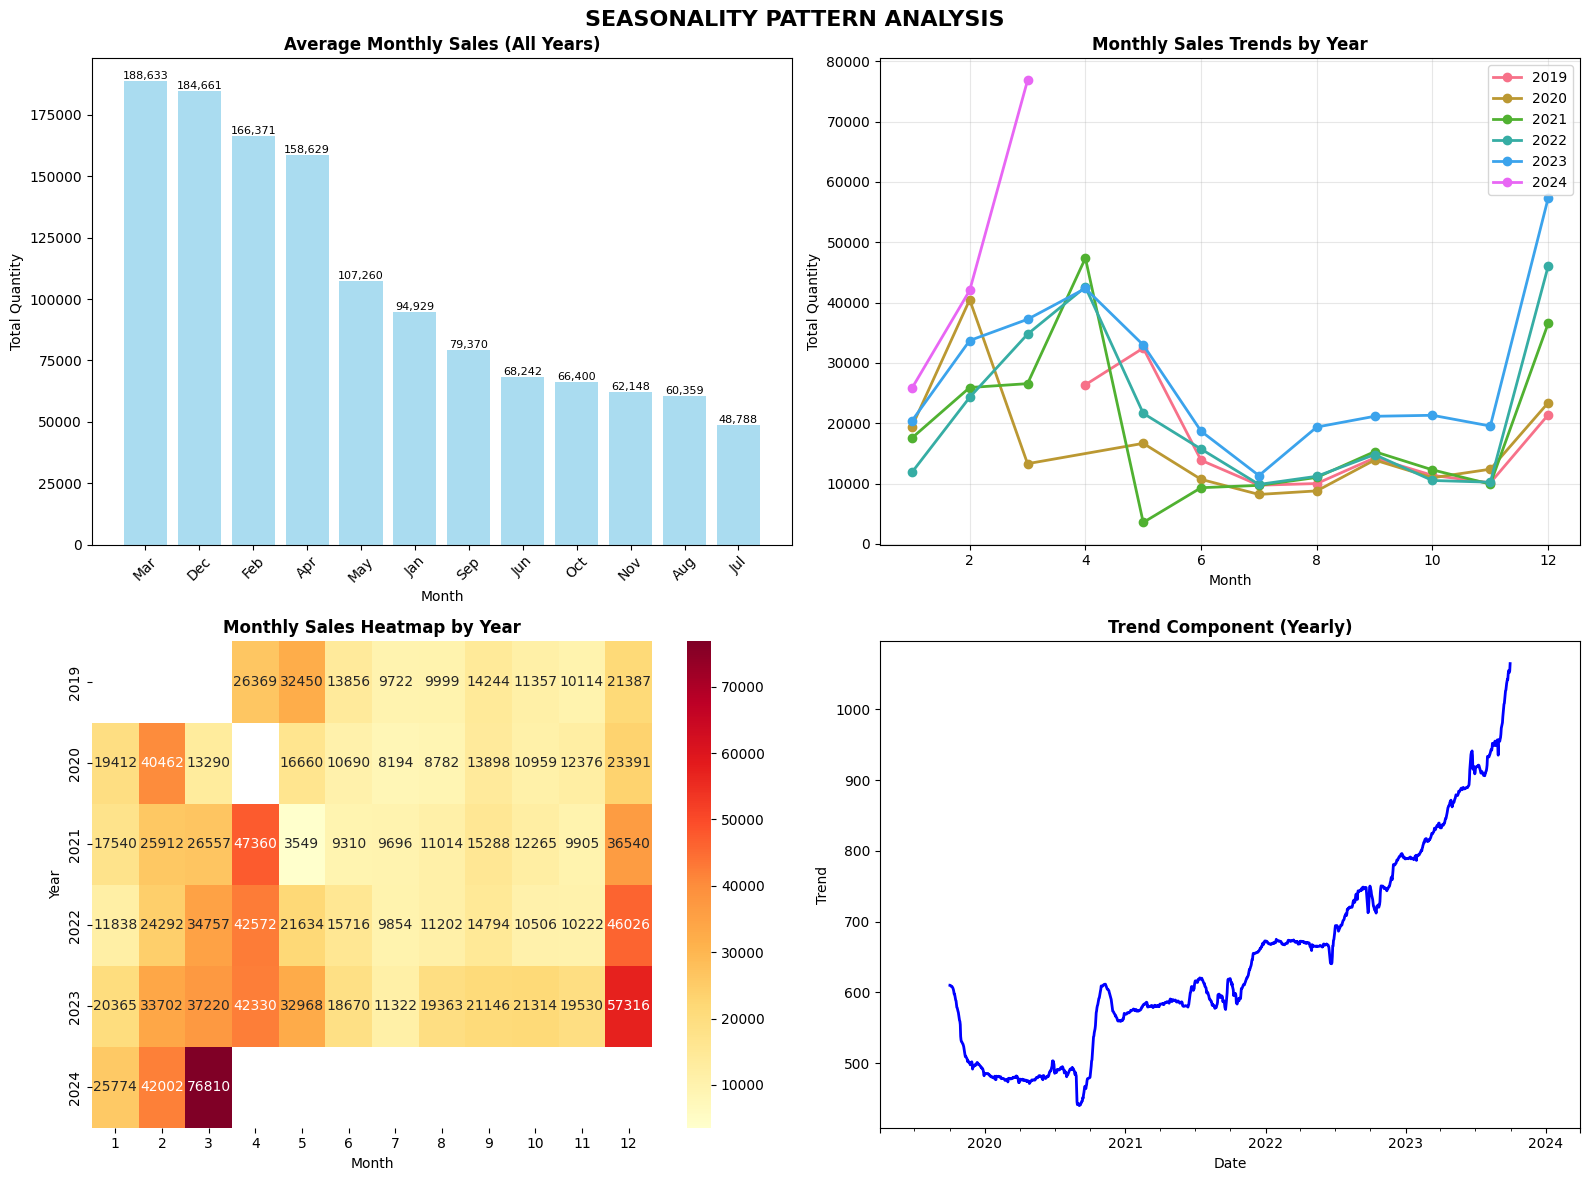


SEASONALITY INSIGHTS:
------------------------------
Peak Months: Mar, Dec, Feb
Low Months: Nov, Aug, Jul
Seasonality Strength: 0.49 (higher = more seasonal)
Peak to Trough Ratio: 3.04x


In [14]:
# =============================================================================
# 1. SEASONALITY PATTERN ANALYSIS
# =============================================================================

print("\n1. SEASONALITY PATTERN ANALYSIS")
print("-" * 50)

# Convert Date to datetime if not already
refactored_df['Date'] = pd.to_datetime(refactored_df['Date'])

# Monthly aggregation
monthly_sales = refactored_df.groupby(['Year', 'Month'])['Qty'].sum().reset_index()
monthly_avg = refactored_df.groupby('Month')['Qty'].sum().reset_index()
monthly_avg['Month_Name'] = monthly_avg['Month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Create comprehensive seasonality plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SEASONALITY PATTERN ANALYSIS', fontsize=16, fontweight='bold')

# 1. Monthly Average Sales
ax1 = axes[0, 0]
monthly_avg_sorted = monthly_avg.sort_values('Qty', ascending=False)
bars = ax1.bar(monthly_avg_sorted['Month_Name'], monthly_avg_sorted['Qty'], 
              color='skyblue', alpha=0.7)
ax1.set_title('Average Monthly Sales (All Years)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Quantity')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=8)

# 2. Yearly Monthly Trends
ax2 = axes[0, 1]
for year in sorted(refactored_df['Year'].unique()):
    year_data = monthly_sales[monthly_sales['Year'] == year]
    ax2.plot(year_data['Month'], year_data['Qty'], marker='o', label=f'{year}', linewidth=2)

ax2.set_title('Monthly Sales Trends by Year', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Quantity')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Heatmap of Monthly Sales by Year
ax3 = axes[1, 0]
heatmap_data = monthly_sales.pivot(index='Year', columns='Month', values='Qty')
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax3)
ax3.set_title('Monthly Sales Heatmap by Year', fontweight='bold')

# 4. Seasonal Decomposition
ax4 = axes[1, 1]
# Create time series for decomposition
ts_data = refactored_df.groupby('Date')['Qty'].sum().resample('D').sum().fillna(0)
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts_data, model='additive', period=365)
decomposition.trend.plot(ax=ax4, color='blue', linewidth=2)
ax4.set_title('Trend Component (Yearly)', fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Trend')

plt.tight_layout()
plt.show()

# Print seasonality insights
print("\nSEASONALITY INSIGHTS:")
print("-" * 30)
peak_months = monthly_avg_sorted.head(3)
low_months = monthly_avg_sorted.tail(3)

print(f"Peak Months: {', '.join(peak_months['Month_Name'].tolist())}")
print(f"Low Months: {', '.join(low_months['Month_Name'].tolist())}")

# Calculate seasonality strength
monthly_std = monthly_avg['Qty'].std()
monthly_mean = monthly_avg['Qty'].mean()
seasonality_strength = monthly_std / monthly_mean
print(f"Seasonality Strength: {seasonality_strength:.2f} (higher = more seasonal)")

# Peak to trough ratio
peak_trough_ratio = peak_months['Qty'].iloc[0] / low_months['Qty'].iloc[0]
print(f"Peak to Trough Ratio: {peak_trough_ratio:.2f}x")



2. LAG STRUCTURE AND AUTOCORRELATION ANALYSIS
--------------------------------------------------


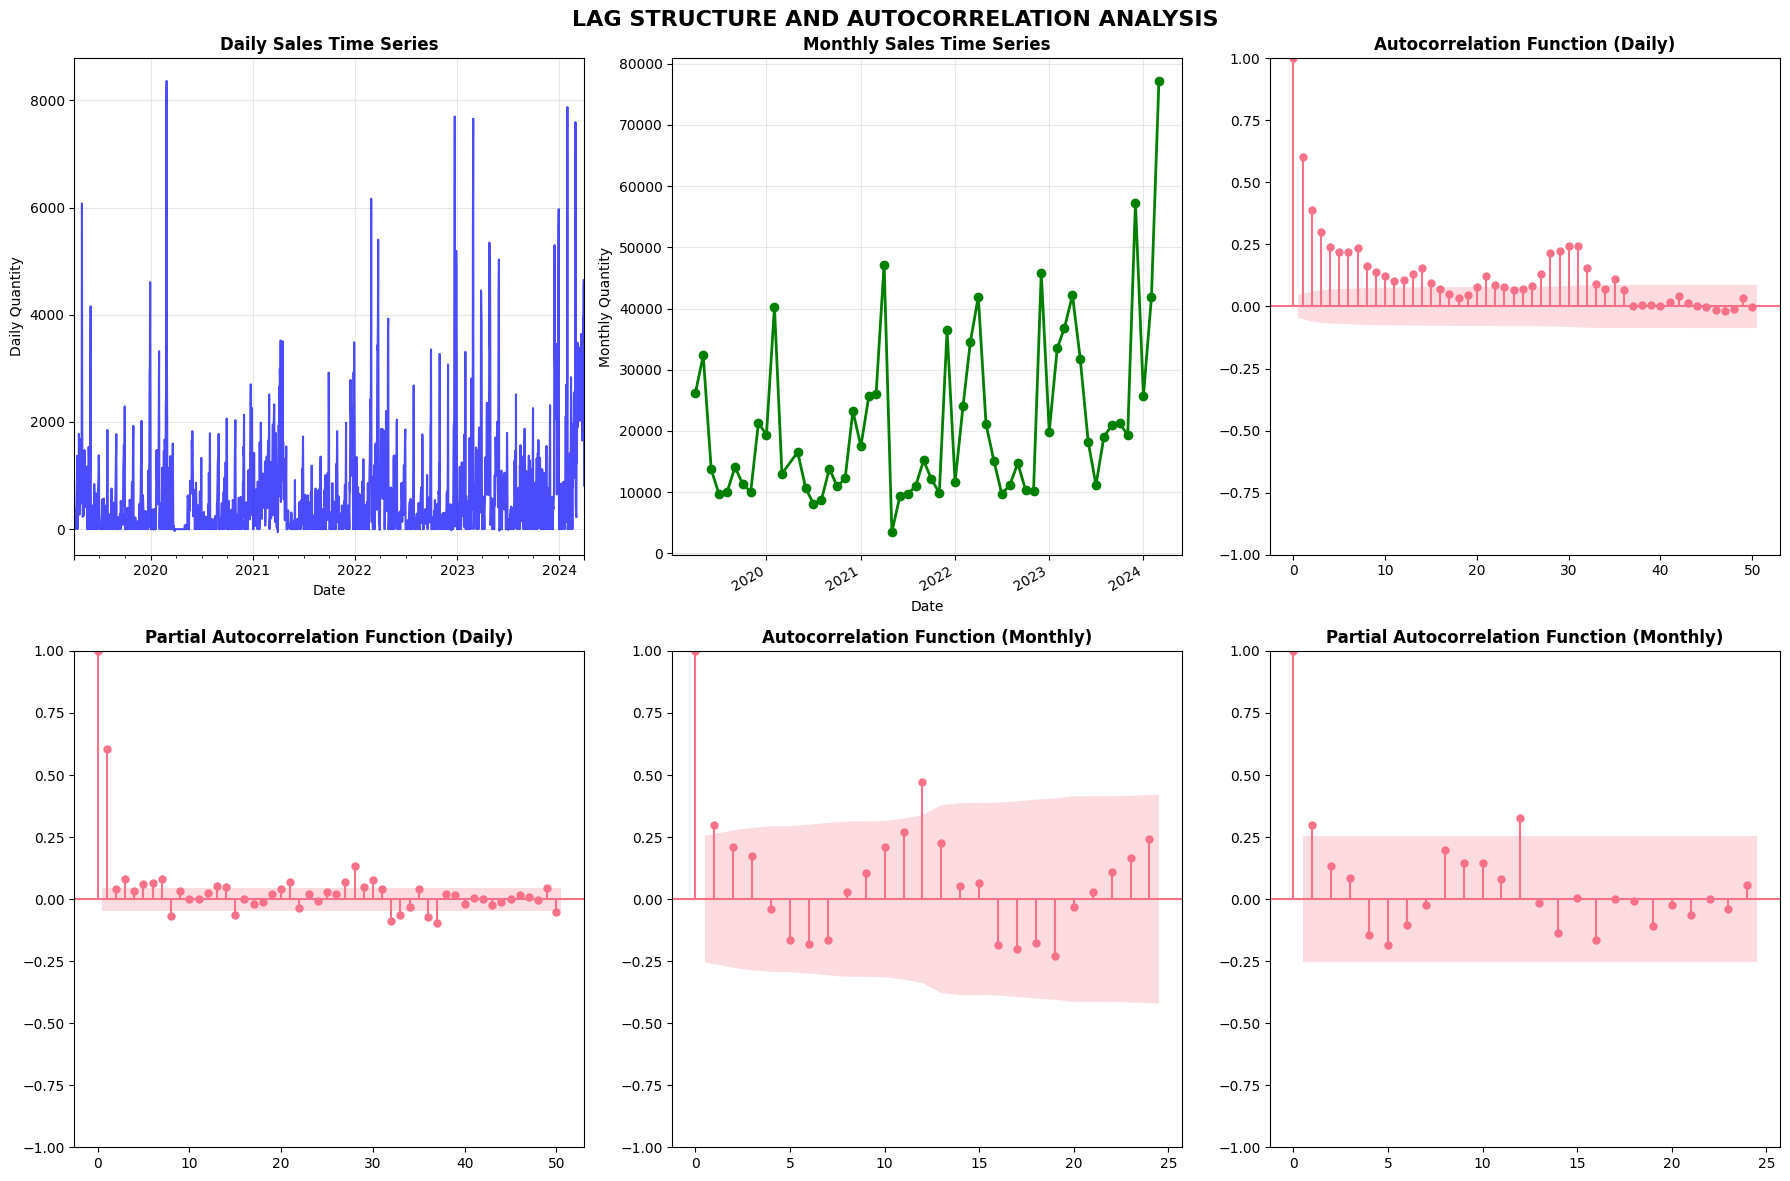


LAG CORRELATION ANALYSIS:
------------------------------
Daily Lag Correlations:
  Lag-  1 (daily): 0.6034
  Lag-  7 (daily): 0.2394
  Lag- 14 (daily): 0.1592
  Lag- 30 (daily): 0.2591
  Lag- 90 (daily): 0.1991
  Lag-365 (daily): 0.4657

Monthly Lag Correlations:
  Lag- 1 (monthly): 0.3475
  Lag- 3 (monthly): 0.2081
  Lag- 6 (monthly): -0.2402
  Lag-12 (monthly): 0.7173
  Lag-24 (monthly): 0.5508

STATISTICAL SIGNIFICANCE:
------------------------------
Ljung-Box Test Results (Daily):
  p-value: 0.000000
  Significant autocorrelation: Yes

SIGNIFICANT LAGS:
--------------------
Significant daily lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Weekly Seasonality Strength: 0.976
Yearly Seasonality Strength: 0.336


In [13]:
# =============================================================================
# 2. LAG STRUCTURE AND AUTOCORRELATION ANALYSIS
# =============================================================================

print("\n2. LAG STRUCTURE AND AUTOCORRELATION ANALYSIS")
print("-" * 50)

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# Create daily time series
daily_sales = refactored_df.groupby('Date')['Qty'].sum().resample('D').sum().fillna(0)

# Create monthly time series for better lag analysis
monthly_ts = refactored_df.groupby(['Year', 'Month'])['Qty'].sum().reset_index()
monthly_ts['Date'] = pd.to_datetime(monthly_ts[['Year', 'Month']].assign(day=1))
monthly_ts = monthly_ts.set_index('Date')['Qty']

# Create comprehensive lag analysis plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('LAG STRUCTURE AND AUTOCORRELATION ANALYSIS', fontsize=16, fontweight='bold')

# 1. Daily Time Series
ax1 = axes[0, 0]
daily_sales.plot(ax=ax1, color='blue', alpha=0.7)
ax1.set_title('Daily Sales Time Series', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Quantity')
ax1.grid(True, alpha=0.3)

# 2. Monthly Time Series
ax2 = axes[0, 1]
monthly_ts.plot(ax=ax2, color='green', marker='o', linewidth=2)
ax2.set_title('Monthly Sales Time Series', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Monthly Quantity')
ax2.grid(True, alpha=0.3)

# 3. ACF Plot (Daily)
ax3 = axes[0, 2]
plot_acf(daily_sales, ax=ax3, lags=50, alpha=0.05)
ax3.set_title('Autocorrelation Function (Daily)', fontweight='bold')

# 4. PACF Plot (Daily)
ax4 = axes[1, 0]
plot_pacf(daily_sales, ax=ax4, lags=50, alpha=0.05)
ax4.set_title('Partial Autocorrelation Function (Daily)', fontweight='bold')

# 5. ACF Plot (Monthly)
ax5 = axes[1, 1]
plot_acf(monthly_ts, ax=ax5, lags=24, alpha=0.05)
ax5.set_title('Autocorrelation Function (Monthly)', fontweight='bold')

# 6. PACF Plot (Monthly)
ax6 = axes[1, 2]
plot_pacf(monthly_ts, ax=ax6, lags=24, alpha=0.05)
ax6.set_title('Partial Autocorrelation Function (Monthly)', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate specific lag correlations
print("\nLAG CORRELATION ANALYSIS:")
print("-" * 30)

# Daily lags
daily_lags = [1, 7, 14, 30, 90, 365]  # 1 day, 1 week, 2 weeks, 1 month, 3 months, 1 year
print("Daily Lag Correlations:")
for lag in daily_lags:
    if lag < len(daily_sales):
        corr = daily_sales.autocorr(lag=lag)
        print(f"  Lag-{lag:3d} (daily): {corr:.4f}")

# Monthly lags
monthly_lags = [1, 3, 6, 12, 24]  # 1 month, 3 months, 6 months, 1 year, 2 years
print("\nMonthly Lag Correlations:")
for lag in monthly_lags:
    if lag < len(monthly_ts):
        corr = monthly_ts.autocorr(lag=lag)
        print(f"  Lag-{lag:2d} (monthly): {corr:.4f}")

# Statistical significance testing
print("\nSTATISTICAL SIGNIFICANCE:")
print("-" * 30)
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test for autocorrelation
lb_result = acorr_ljungbox(daily_sales, lags=10, return_df=True)
print("Ljung-Box Test Results (Daily):")
print(f"  p-value: {lb_result['lb_pvalue'].iloc[-1]:.6f}")
print(f"  Significant autocorrelation: {'Yes' if lb_result['lb_pvalue'].iloc[-1] < 0.05 else 'No'}")

# Identify significant lags
print("\nSIGNIFICANT LAGS:")
print("-" * 20)
acf_values = acf(daily_sales, nlags=50)
significant_lags = []
for i, val in enumerate(acf_values[1:], 1):  # Skip lag 0
    if abs(val) > 0.1:  # Threshold for significance
        significant_lags.append(i)

print(f"Significant daily lags: {significant_lags[:10]}")  # Show first 10

# Weekly seasonality analysis
weekly_sales = refactored_df.groupby(['Year', 'Week'])['Qty'].sum().reset_index()
print(f"\nWeekly Seasonality Strength: {weekly_sales['Qty'].std() / weekly_sales['Qty'].mean():.3f}")

# Yearly seasonality analysis
yearly_sales = refactored_df.groupby('Year')['Qty'].sum()
print(f"Yearly Seasonality Strength: {yearly_sales.std() / yearly_sales.mean():.3f}")



3. PRODUCT TRENDS ANALYSIS
--------------------------------------------------


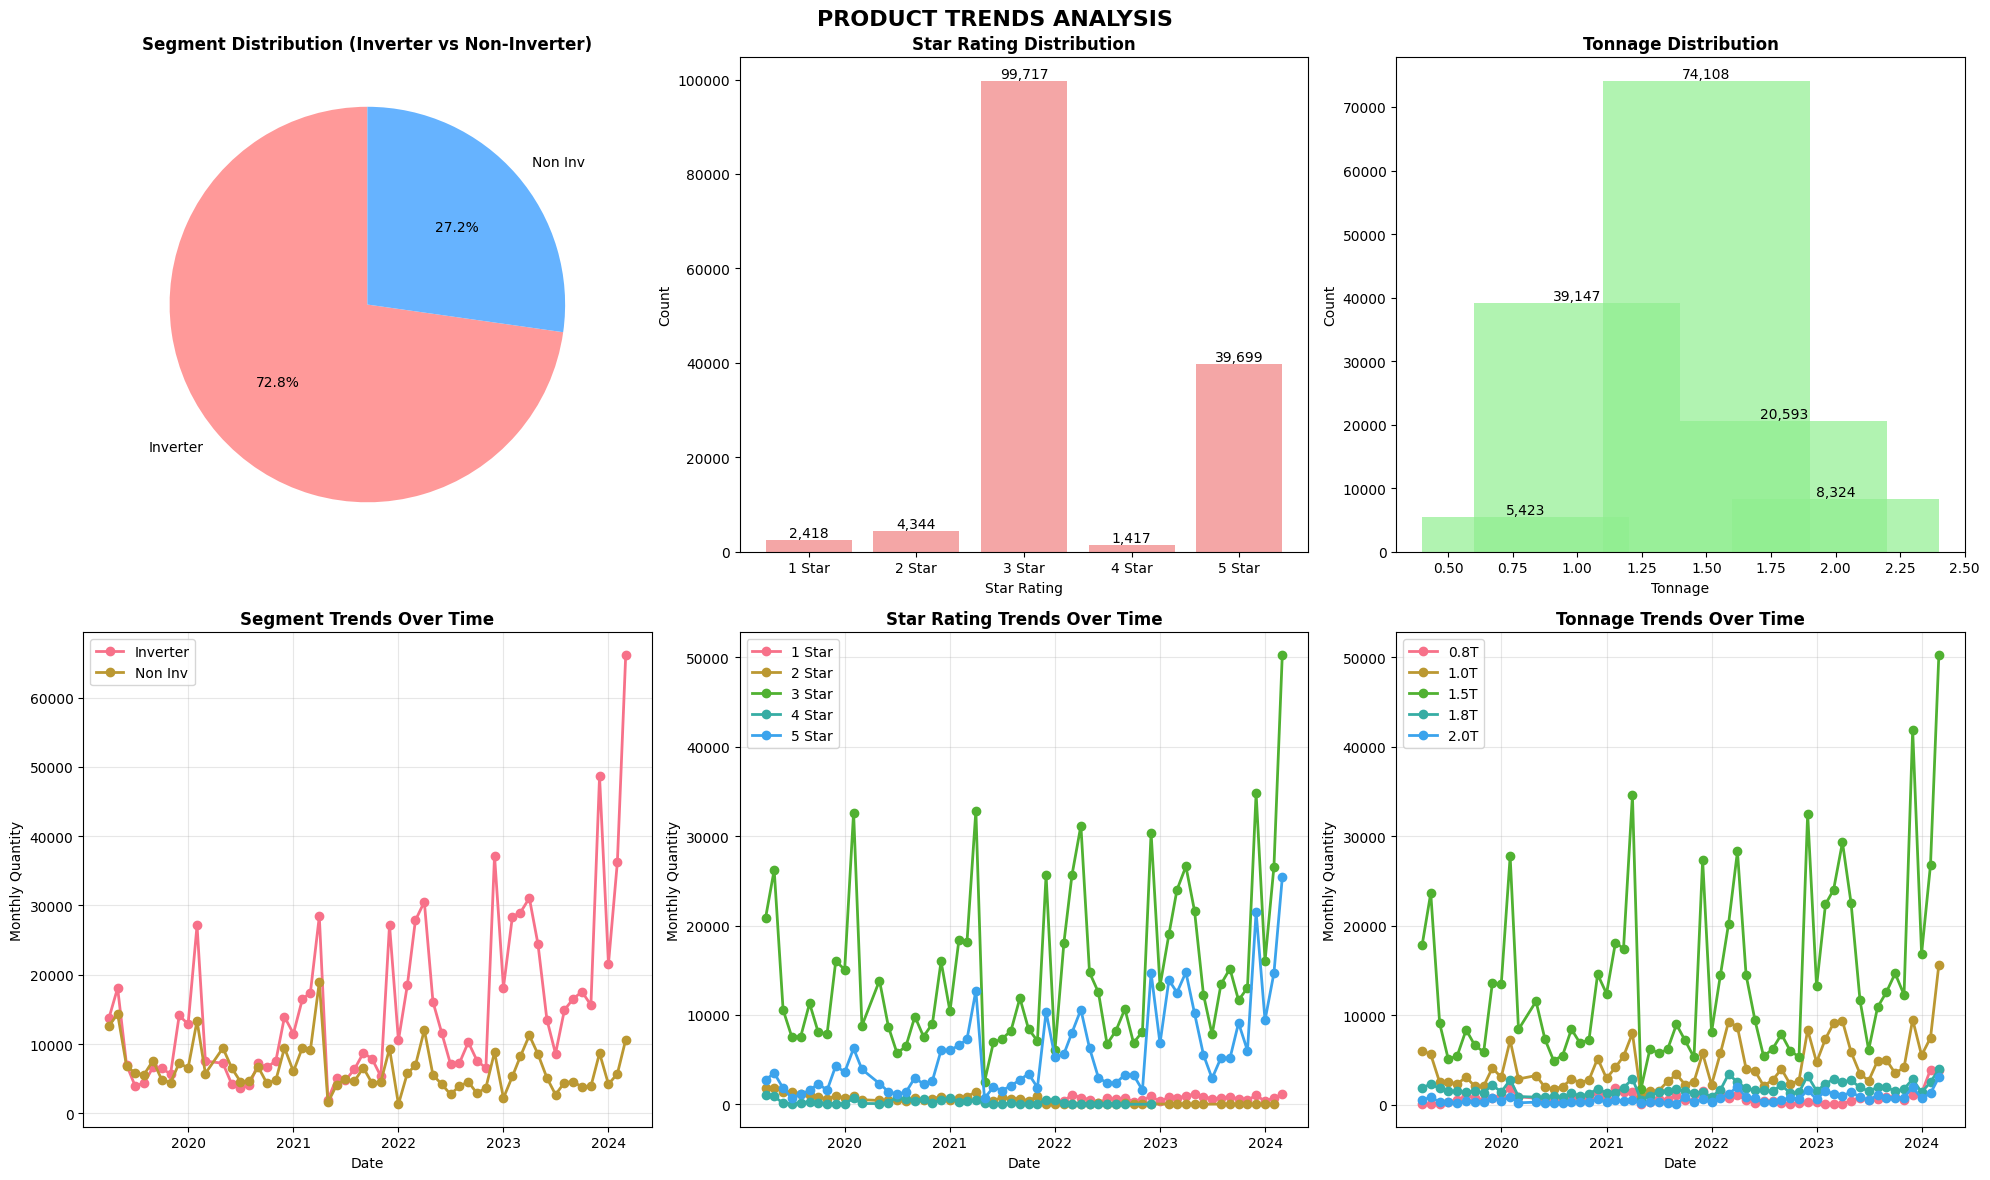


PRODUCT TREND INSIGHTS:
------------------------------
Segment Market Share by Year:
  2019: Inverter 53.6%, Non-Inverter 46.4%
  2020: Inverter 57.3%, Non-Inverter 42.7%
  2021: Inverter 62.8%, Non-Inverter 37.2%
  2022: Inverter 75.4%, Non-Inverter 24.6%
  2023: Inverter 79.5%, Non-Inverter 20.5%
  2024: Inverter 85.8%, Non-Inverter 14.2%

Growth Rates:
  Inverter: 54.8%
  Non-Inverter: -70.4%

Star Rating Trends:
  1 Star: inf% growth
  2 Star: -99.9% growth
  3 Star: -19.9% growth
  4 Star: -100.0% growth
  5 Star: 153.0% growth

Tonnage Trends:
  0.8T: 115.6% growth
  1.0T: -5.6% growth
  1.5T: -1.7% growth
  1.8T: -49.1% growth
  2.0T: 28.1% growth


In [15]:
# =============================================================================
# 3. PRODUCT TRENDS ANALYSIS
# =============================================================================

print("\n3. PRODUCT TRENDS ANALYSIS")
print("-" * 50)

# Create comprehensive product trend analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('PRODUCT TRENDS ANALYSIS', fontsize=16, fontweight='bold')

# 1. Segment Distribution (Inverter vs Non-Inverter)
ax1 = axes[0, 0]
segment_counts = refactored_df['Segment'].value_counts()
colors = ['#ff9999', '#66b3ff']
wedges, texts, autotexts = ax1.pie(segment_counts.values, labels=segment_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Segment Distribution (Inverter vs Non-Inverter)', fontweight='bold')

# 2. Star Rating Distribution
ax2 = axes[0, 1]
rating_counts = refactored_df['Rating'].value_counts().sort_index()
bars = ax2.bar(rating_counts.index, rating_counts.values, color='lightcoral', alpha=0.7)
ax2.set_title('Star Rating Distribution', fontweight='bold')
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

# 3. Tonnage Distribution
ax3 = axes[0, 2]
tonnage_counts = refactored_df['Tonnage'].value_counts().sort_index()
bars = ax3.bar(tonnage_counts.index, tonnage_counts.values, color='lightgreen', alpha=0.7)
ax3.set_title('Tonnage Distribution', fontweight='bold')
ax3.set_xlabel('Tonnage')
ax3.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

# 4. Segment Trends Over Time
ax4 = axes[1, 0]
segment_trends = refactored_df.groupby(['Year', 'Month', 'Segment'])['Qty'].sum().reset_index()
segment_trends['Date'] = pd.to_datetime(segment_trends[['Year', 'Month']].assign(day=1))

for segment in segment_trends['Segment'].unique():
    seg_data = segment_trends[segment_trends['Segment'] == segment]
    ax4.plot(seg_data['Date'], seg_data['Qty'], marker='o', label=segment, linewidth=2)

ax4.set_title('Segment Trends Over Time', fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Monthly Quantity')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Star Rating Trends Over Time
ax5 = axes[1, 1]
rating_trends = refactored_df.groupby(['Year', 'Month', 'Rating'])['Qty'].sum().reset_index()
rating_trends['Date'] = pd.to_datetime(rating_trends[['Year', 'Month']].assign(day=1))

for rating in sorted(rating_trends['Rating'].unique()):
    rating_data = rating_trends[rating_trends['Rating'] == rating]
    ax5.plot(rating_data['Date'], rating_data['Qty'], marker='o', label=f'{rating}', linewidth=2)

ax5.set_title('Star Rating Trends Over Time', fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Monthly Quantity')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Tonnage Trends Over Time
ax6 = axes[1, 2]
tonnage_trends = refactored_df.groupby(['Year', 'Month', 'Tonnage'])['Qty'].sum().reset_index()
tonnage_trends['Date'] = pd.to_datetime(tonnage_trends[['Year', 'Month']].assign(day=1))

for tonnage in sorted(tonnage_trends['Tonnage'].unique()):
    tonnage_data = tonnage_trends[tonnage_trends['Tonnage'] == tonnage]
    ax6.plot(tonnage_data['Date'], tonnage_data['Qty'], marker='o', label=f'{tonnage}T', linewidth=2)

ax6.set_title('Tonnage Trends Over Time', fontweight='bold')
ax6.set_xlabel('Date')
ax6.set_ylabel('Monthly Quantity')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate product trend insights
print("\nPRODUCT TREND INSIGHTS:")
print("-" * 30)

# Segment analysis
segment_yearly = refactored_df.groupby(['Year', 'Segment'])['Qty'].sum().reset_index()
segment_pivot = segment_yearly.pivot(index='Year', columns='Segment', values='Qty').fillna(0)

print("Segment Market Share by Year:")
for year in segment_pivot.index:
    total = segment_pivot.loc[year].sum()
    inverter_pct = (segment_pivot.loc[year, 'Inverter'] / total) * 100
    non_inv_pct = (segment_pivot.loc[year, 'Non Inv'] / total) * 100
    print(f"  {year}: Inverter {inverter_pct:.1f}%, Non-Inverter {non_inv_pct:.1f}%")

# Calculate growth rates
if len(segment_pivot) > 1:
    inverter_growth = ((segment_pivot['Inverter'].iloc[-1] / segment_pivot['Inverter'].iloc[0]) - 1) * 100
    non_inv_growth = ((segment_pivot['Non Inv'].iloc[-1] / segment_pivot['Non Inv'].iloc[0]) - 1) * 100
    print(f"\nGrowth Rates:")
    print(f"  Inverter: {inverter_growth:.1f}%")
    print(f"  Non-Inverter: {non_inv_growth:.1f}%")

# Star rating analysis
rating_yearly = refactored_df.groupby(['Year', 'Rating'])['Qty'].sum().reset_index()
rating_pivot = rating_yearly.pivot(index='Year', columns='Rating', values='Qty').fillna(0)

print(f"\nStar Rating Trends:")
for rating in sorted(rating_pivot.columns):
    if len(rating_pivot) > 1:
        growth = ((rating_pivot[rating].iloc[-1] / rating_pivot[rating].iloc[0]) - 1) * 100
        print(f"  {rating}: {growth:.1f}% growth")

# Tonnage analysis
tonnage_yearly = refactored_df.groupby(['Year', 'Tonnage'])['Qty'].sum().reset_index()
tonnage_pivot = tonnage_yearly.pivot(index='Year', columns='Tonnage', values='Qty').fillna(0)

print(f"\nTonnage Trends:")
for tonnage in sorted(tonnage_pivot.columns):
    if len(tonnage_pivot) > 1:
        growth = ((tonnage_pivot[tonnage].iloc[-1] / tonnage_pivot[tonnage].iloc[0]) - 1) * 100
        print(f"  {tonnage}T: {growth:.1f}% growth")



4. BRANCH-WISE PERFORMANCE AND GEOGRAPHICAL ANALYSIS
--------------------------------------------------


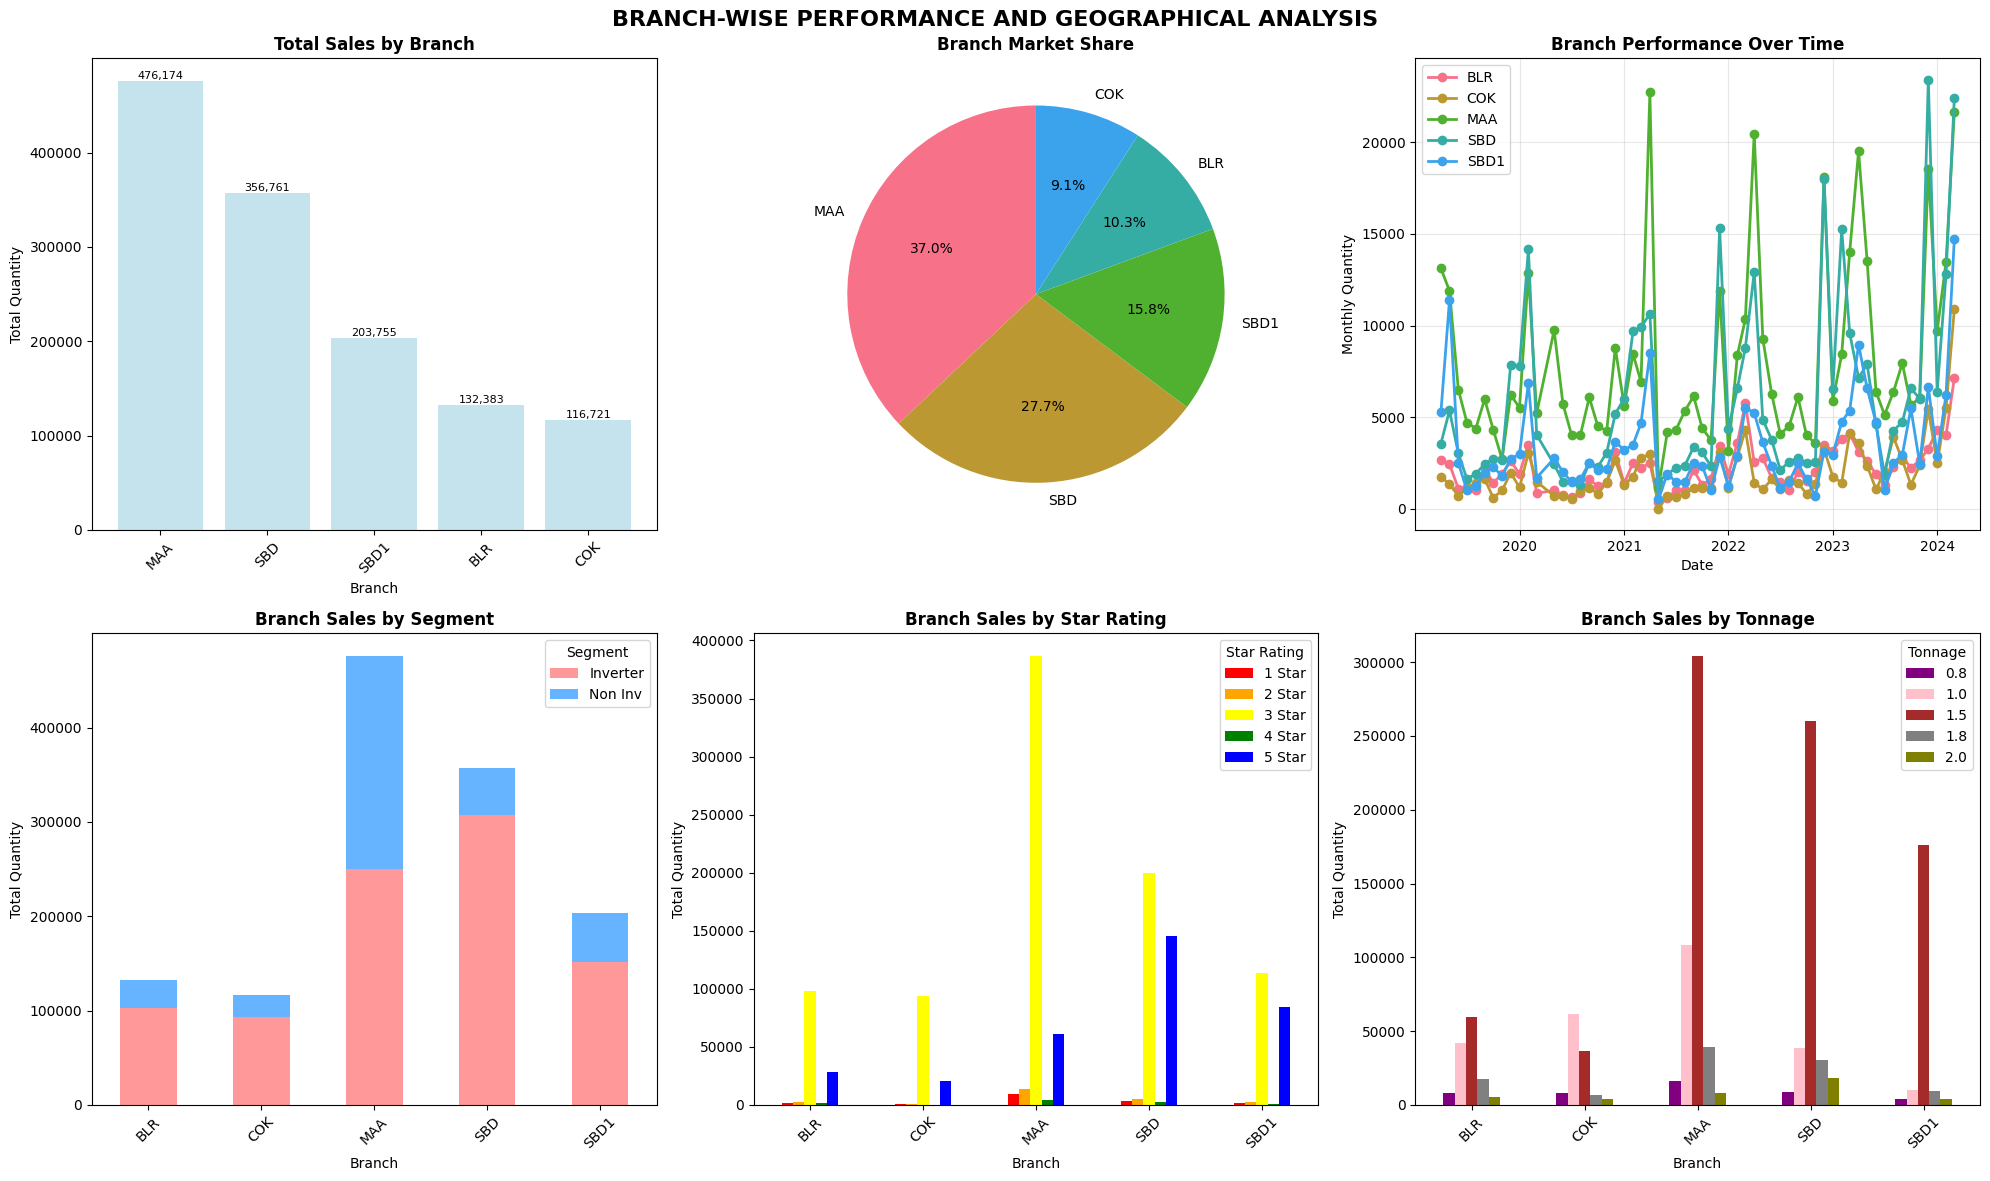


BRANCH PERFORMANCE INSIGHTS:
------------------------------
Branch Rankings by Total Sales:
  1. MAA: 476,174.0 units (37.0%)
  2. SBD: 356,761.0 units (27.7%)
  3. SBD1: 203,755.0 units (15.8%)
  4. BLR: 132,383.0 units (10.3%)
  5. COK: 116,721.0 units (9.1%)

Branch Growth Analysis:
  BLR: -6.8% growth
  COK: 62.8% growth
  MAA: -25.1% growth
  SBD: 33.1% growth
  SBD1: -21.1% growth

Branch Seasonality Analysis:
  BLR: Seasonality strength 0.427
  COK: Seasonality strength 0.588
  MAA: Seasonality strength 0.471
  SBD: Seasonality strength 0.688
  SBD1: Seasonality strength 0.499

Branch Performance Consistency (CV):
  BLR: Coefficient of Variation 0.345
  COK: Coefficient of Variation 0.367
  MAA: Coefficient of Variation 0.333
  SBD: Coefficient of Variation 0.413
  SBD1: Coefficient of Variation 0.311

Branch Segment Preferences:
  BLR: Inverter 77.7%, Non-Inverter 22.3%
  COK: Inverter 79.8%, Non-Inverter 20.2%
  MAA: Inverter 52.4%, Non-Inverter 47.6%
  SBD: Inverter 86.1%, N

In [16]:
# =============================================================================
# 4. BRANCH-WISE PERFORMANCE AND GEOGRAPHICAL ANALYSIS
# =============================================================================

print("\n4. BRANCH-WISE PERFORMANCE AND GEOGRAPHICAL ANALYSIS")
print("-" * 50)

# Create comprehensive branch analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('BRANCH-WISE PERFORMANCE AND GEOGRAPHICAL ANALYSIS', fontsize=16, fontweight='bold')

# 1. Branch Sales Distribution
ax1 = axes[0, 0]
branch_sales = refactored_df.groupby('Branch')['Qty'].sum().sort_values(ascending=False)
bars = ax1.bar(branch_sales.index, branch_sales.values, color='lightblue', alpha=0.7)
ax1.set_title('Total Sales by Branch', fontweight='bold')
ax1.set_xlabel('Branch')
ax1.set_ylabel('Total Quantity')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=8)

# 2. Branch Market Share
ax2 = axes[0, 1]
branch_pct = (branch_sales / branch_sales.sum() * 100).round(1)
wedges, texts, autotexts = ax2.pie(branch_sales.values, labels=branch_sales.index, 
                                   autopct='%1.1f%%', startangle=90)
ax2.set_title('Branch Market Share', fontweight='bold')

# 3. Branch Performance Over Time
ax3 = axes[0, 2]
branch_trends = refactored_df.groupby(['Year', 'Month', 'Branch'])['Qty'].sum().reset_index()
branch_trends['Date'] = pd.to_datetime(branch_trends[['Year', 'Month']].assign(day=1))

for branch in branch_trends['Branch'].unique():
    branch_data = branch_trends[branch_trends['Branch'] == branch]
    ax3.plot(branch_data['Date'], branch_data['Qty'], marker='o', label=branch, linewidth=2)

ax3.set_title('Branch Performance Over Time', fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Monthly Quantity')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Branch vs Segment Analysis
ax4 = axes[1, 0]
branch_segment = refactored_df.groupby(['Branch', 'Segment'])['Qty'].sum().reset_index()
branch_segment_pivot = branch_segment.pivot(index='Branch', columns='Segment', values='Qty').fillna(0)

branch_segment_pivot.plot(kind='bar', stacked=True, ax=ax4, color=['#ff9999', '#66b3ff'])
ax4.set_title('Branch Sales by Segment', fontweight='bold')
ax4.set_xlabel('Branch')
ax4.set_ylabel('Total Quantity')
ax4.legend(title='Segment')
ax4.tick_params(axis='x', rotation=45)

# 5. Branch vs Star Rating Analysis
ax5 = axes[1, 1]
branch_rating = refactored_df.groupby(['Branch', 'Rating'])['Qty'].sum().reset_index()
branch_rating_pivot = branch_rating.pivot(index='Branch', columns='Rating', values='Qty').fillna(0)

branch_rating_pivot.plot(kind='bar', ax=ax5, color=['red', 'orange', 'yellow', 'green', 'blue'])
ax5.set_title('Branch Sales by Star Rating', fontweight='bold')
ax5.set_xlabel('Branch')
ax5.set_ylabel('Total Quantity')
ax5.legend(title='Star Rating')
ax5.tick_params(axis='x', rotation=45)

# 6. Branch vs Tonnage Analysis
ax6 = axes[1, 2]
branch_tonnage = refactored_df.groupby(['Branch', 'Tonnage'])['Qty'].sum().reset_index()
branch_tonnage_pivot = branch_tonnage.pivot(index='Branch', columns='Tonnage', values='Qty').fillna(0)

branch_tonnage_pivot.plot(kind='bar', ax=ax6, color=['purple', 'pink', 'brown', 'gray', 'olive'])
ax6.set_title('Branch Sales by Tonnage', fontweight='bold')
ax6.set_xlabel('Branch')
ax6.set_ylabel('Total Quantity')
ax6.legend(title='Tonnage')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate branch performance insights
print("\nBRANCH PERFORMANCE INSIGHTS:")
print("-" * 30)

# Branch rankings
print("Branch Rankings by Total Sales:")
for i, (branch, sales) in enumerate(branch_sales.items(), 1):
    market_share = (sales / branch_sales.sum()) * 100
    print(f"  {i}. {branch}: {sales:,} units ({market_share:.1f}%)")

# Branch growth analysis
print(f"\nBranch Growth Analysis:")
branch_yearly = refactored_df.groupby(['Year', 'Branch'])['Qty'].sum().reset_index()
branch_yearly_pivot = branch_yearly.pivot(index='Year', columns='Branch', values='Qty').fillna(0)

for branch in branch_yearly_pivot.columns:
    if len(branch_yearly_pivot) > 1:
        growth = ((branch_yearly_pivot[branch].iloc[-1] / branch_yearly_pivot[branch].iloc[0]) - 1) * 100
        print(f"  {branch}: {growth:.1f}% growth")

# Branch seasonality analysis
print(f"\nBranch Seasonality Analysis:")
branch_monthly = refactored_df.groupby(['Branch', 'Month'])['Qty'].sum().reset_index()
for branch in branch_monthly['Branch'].unique():
    branch_data = branch_monthly[branch_monthly['Branch'] == branch]
    seasonality = branch_data['Qty'].std() / branch_data['Qty'].mean()
    print(f"  {branch}: Seasonality strength {seasonality:.3f}")

# Branch performance consistency
print(f"\nBranch Performance Consistency (CV):")
for branch in branch_yearly_pivot.columns:
    cv = branch_yearly_pivot[branch].std() / branch_yearly_pivot[branch].mean()
    print(f"  {branch}: Coefficient of Variation {cv:.3f}")

# Branch segment preferences
print(f"\nBranch Segment Preferences:")
for branch in branch_segment_pivot.index:
    total = branch_segment_pivot.loc[branch].sum()
    inverter_pct = (branch_segment_pivot.loc[branch, 'Inverter'] / total) * 100
    non_inv_pct = (branch_segment_pivot.loc[branch, 'Non Inv'] / total) * 100
    print(f"  {branch}: Inverter {inverter_pct:.1f}%, Non-Inverter {non_inv_pct:.1f}%")

# Branch star rating preferences
print(f"\nBranch Star Rating Preferences:")
for branch in branch_rating_pivot.index:
    total = branch_rating_pivot.loc[branch].sum()
    print(f"  {branch}:")
    for rating in sorted(branch_rating_pivot.columns):
        pct = (branch_rating_pivot.loc[branch, rating] / total) * 100
        print(f"    {rating}: {pct:.1f}%")



5. TONNAGE DISTRIBUTION AND CAPACITY ANALYSIS
--------------------------------------------------


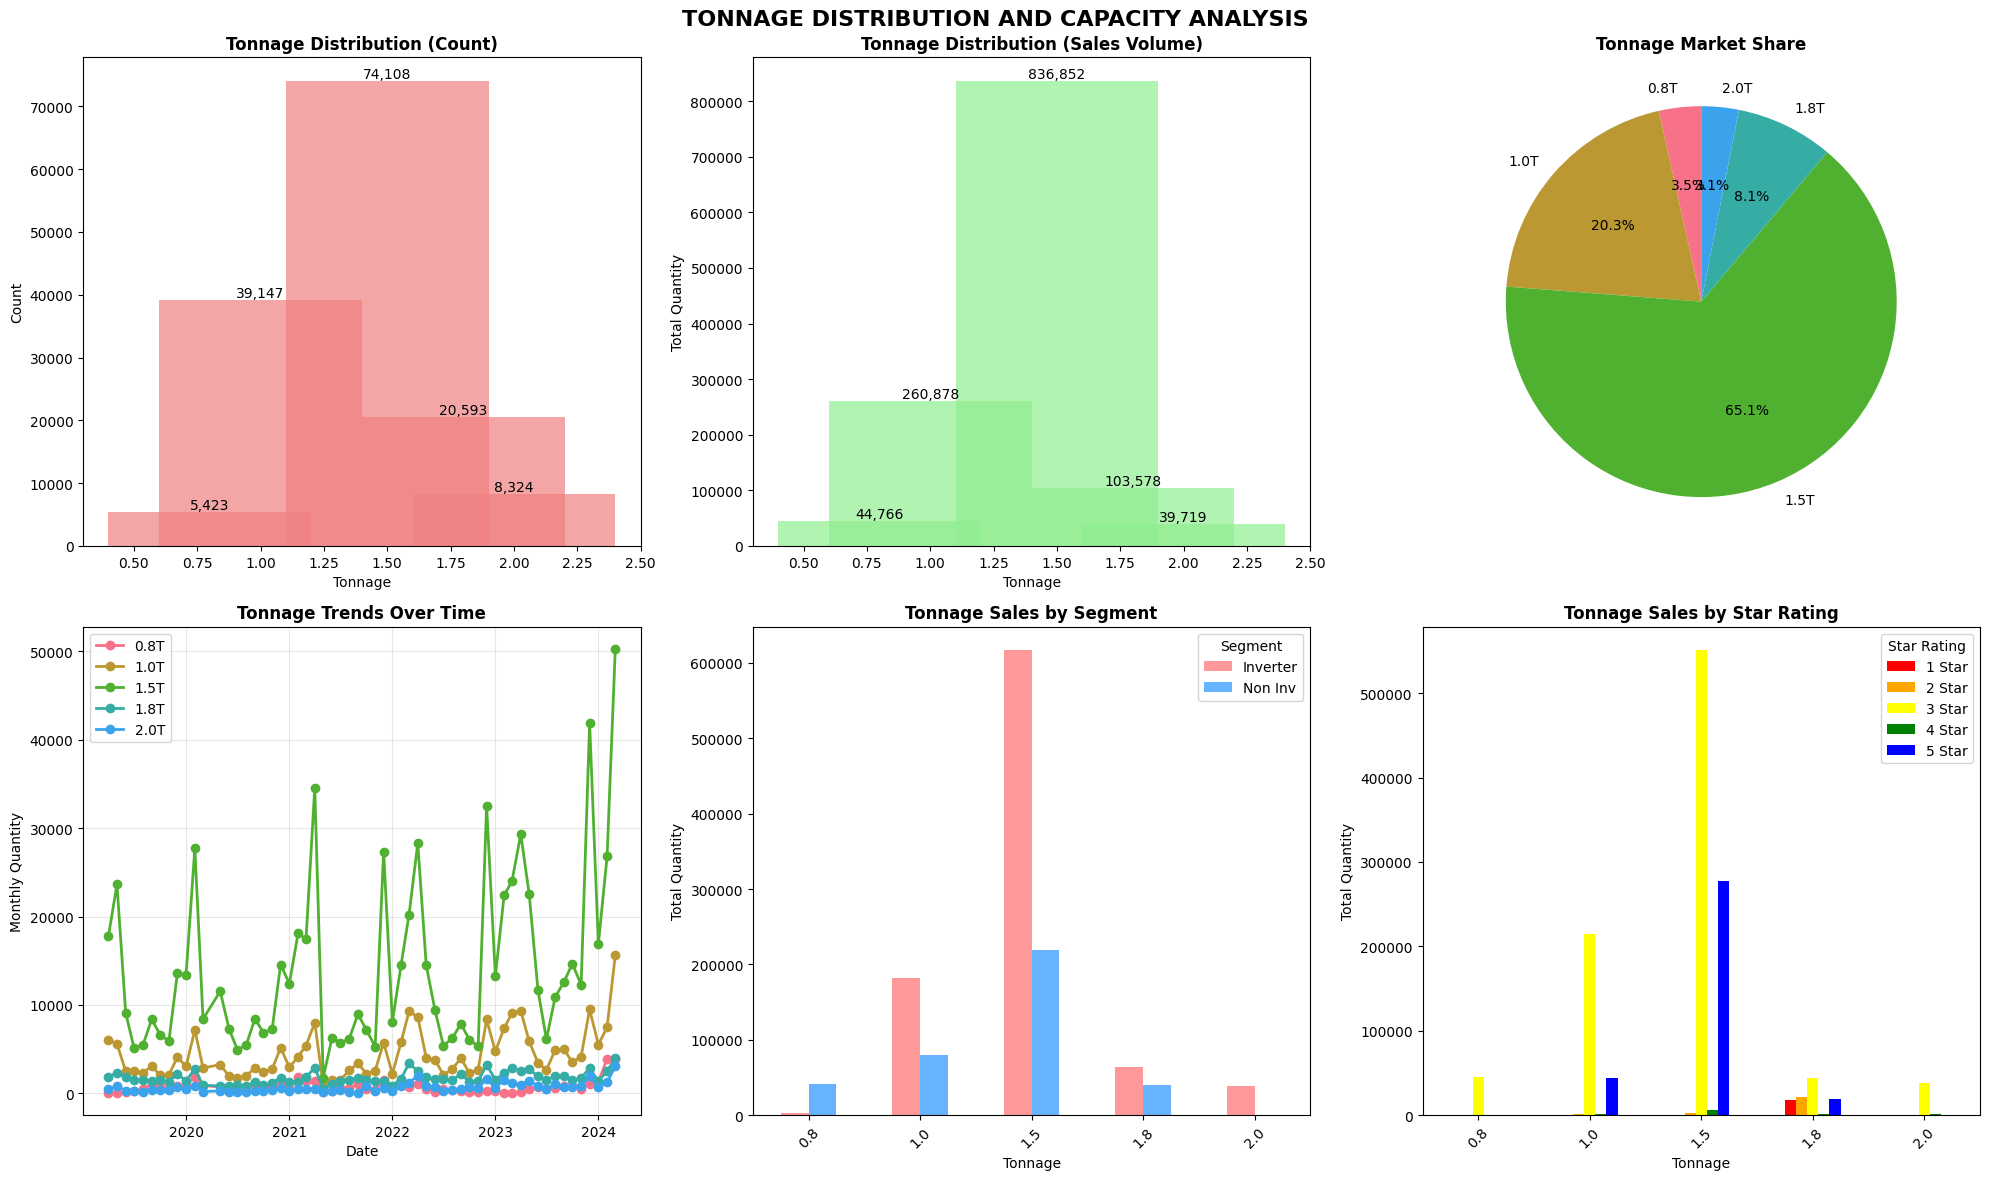


TONNAGE INSIGHTS:
--------------------
Tonnage Rankings by Sales Volume:
  1. 0.8T: 44,766.0 units (3.5%)
  2. 1.0T: 260,878.0 units (20.3%)
  3. 1.5T: 836,852.5 units (65.1%)
  4. 1.8T: 103,578.5 units (8.1%)
  5. 2.0T: 39,719.0 units (3.1%)

Tonnage Growth Analysis:
  0.8T: 115.6% growth
  1.0T: -5.6% growth
  1.5T: -1.7% growth
  1.8T: -49.1% growth
  2.0T: 28.1% growth

Tonnage Seasonality Analysis:
  0.8T: Seasonality strength 0.605
  1.0T: Seasonality strength 0.475
  1.5T: Seasonality strength 0.541
  1.8T: Seasonality strength 0.248
  2.0T: Seasonality strength 0.459

Tonnage Segment Preferences:
  0.8T: Inverter 7.3%, Non-Inverter 92.7%
  1.0T: Inverter 69.5%, Non-Inverter 30.5%
  1.5T: Inverter 73.8%, Non-Inverter 26.2%
  1.8T: Inverter 61.7%, Non-Inverter 38.3%
  2.0T: Inverter 98.3%, Non-Inverter 1.7%

Tonnage Star Rating Preferences:
  0.8T:
    1 Star: 0.0%
    2 Star: 0.0%
    3 Star: 99.9%
    4 Star: 0.1%
    5 Star: 0.0%
  1.0T:
    1 Star: 0.0%
    2 Star: 0.3%
    

In [17]:
# =============================================================================
# 5. TONNAGE DISTRIBUTION AND CAPACITY ANALYSIS
# =============================================================================

print("\n5. TONNAGE DISTRIBUTION AND CAPACITY ANALYSIS")
print("-" * 50)

# Create comprehensive tonnage analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('TONNAGE DISTRIBUTION AND CAPACITY ANALYSIS', fontsize=16, fontweight='bold')

# 1. Tonnage Distribution (Count)
ax1 = axes[0, 0]
tonnage_counts = refactored_df['Tonnage'].value_counts().sort_index()
bars = ax1.bar(tonnage_counts.index, tonnage_counts.values, color='lightcoral', alpha=0.7)
ax1.set_title('Tonnage Distribution (Count)', fontweight='bold')
ax1.set_xlabel('Tonnage')
ax1.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

# 2. Tonnage Distribution (Sales Volume)
ax2 = axes[0, 1]
tonnage_sales = refactored_df.groupby('Tonnage')['Qty'].sum().sort_index()
bars = ax2.bar(tonnage_sales.index, tonnage_sales.values, color='lightgreen', alpha=0.7)
ax2.set_title('Tonnage Distribution (Sales Volume)', fontweight='bold')
ax2.set_xlabel('Tonnage')
ax2.set_ylabel('Total Quantity')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

# 3. Tonnage Market Share
ax3 = axes[0, 2]
tonnage_pct = (tonnage_sales / tonnage_sales.sum() * 100).round(1)
wedges, texts, autotexts = ax3.pie(tonnage_sales.values, labels=[f'{t}T' for t in tonnage_sales.index], 
                                   autopct='%1.1f%%', startangle=90)
ax3.set_title('Tonnage Market Share', fontweight='bold')

# 4. Tonnage Trends Over Time
ax4 = axes[1, 0]
tonnage_trends = refactored_df.groupby(['Year', 'Month', 'Tonnage'])['Qty'].sum().reset_index()
tonnage_trends['Date'] = pd.to_datetime(tonnage_trends[['Year', 'Month']].assign(day=1))

for tonnage in sorted(tonnage_trends['Tonnage'].unique()):
    tonnage_data = tonnage_trends[tonnage_trends['Tonnage'] == tonnage]
    ax4.plot(tonnage_data['Date'], tonnage_data['Qty'], marker='o', label=f'{tonnage}T', linewidth=2)

ax4.set_title('Tonnage Trends Over Time', fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Monthly Quantity')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Tonnage vs Segment Analysis
ax5 = axes[1, 1]
tonnage_segment = refactored_df.groupby(['Tonnage', 'Segment'])['Qty'].sum().reset_index()
tonnage_segment_pivot = tonnage_segment.pivot(index='Tonnage', columns='Segment', values='Qty').fillna(0)

tonnage_segment_pivot.plot(kind='bar', ax=ax5, color=['#ff9999', '#66b3ff'])
ax5.set_title('Tonnage Sales by Segment', fontweight='bold')
ax5.set_xlabel('Tonnage')
ax5.set_ylabel('Total Quantity')
ax5.legend(title='Segment')
ax5.tick_params(axis='x', rotation=45)

# 6. Tonnage vs Star Rating Analysis
ax6 = axes[1, 2]
tonnage_rating = refactored_df.groupby(['Tonnage', 'Rating'])['Qty'].sum().reset_index()
tonnage_rating_pivot = tonnage_rating.pivot(index='Tonnage', columns='Rating', values='Qty').fillna(0)

tonnage_rating_pivot.plot(kind='bar', ax=ax6, color=['red', 'orange', 'yellow', 'green', 'blue'])
ax6.set_title('Tonnage Sales by Star Rating', fontweight='bold')
ax6.set_xlabel('Tonnage')
ax6.set_ylabel('Total Quantity')
ax6.legend(title='Star Rating')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate tonnage insights
print("\nTONNAGE INSIGHTS:")
print("-" * 20)

# Tonnage rankings
print("Tonnage Rankings by Sales Volume:")
for i, (tonnage, sales) in enumerate(tonnage_sales.items(), 1):
    market_share = (sales / tonnage_sales.sum()) * 100
    print(f"  {i}. {tonnage}T: {sales:,} units ({market_share:.1f}%)")

# Tonnage growth analysis
print(f"\nTonnage Growth Analysis:")
tonnage_yearly = refactored_df.groupby(['Year', 'Tonnage'])['Qty'].sum().reset_index()
tonnage_yearly_pivot = tonnage_yearly.pivot(index='Year', columns='Tonnage', values='Qty').fillna(0)

for tonnage in tonnage_yearly_pivot.columns:
    if len(tonnage_yearly_pivot) > 1:
        growth = ((tonnage_yearly_pivot[tonnage].iloc[-1] / tonnage_yearly_pivot[tonnage].iloc[0]) - 1) * 100
        print(f"  {tonnage}T: {growth:.1f}% growth")

# Tonnage seasonality analysis
print(f"\nTonnage Seasonality Analysis:")
tonnage_monthly = refactored_df.groupby(['Tonnage', 'Month'])['Qty'].sum().reset_index()
for tonnage in tonnage_monthly['Tonnage'].unique():
    tonnage_data = tonnage_monthly[tonnage_monthly['Tonnage'] == tonnage]
    seasonality = tonnage_data['Qty'].std() / tonnage_data['Qty'].mean()
    print(f"  {tonnage}T: Seasonality strength {seasonality:.3f}")

# Tonnage segment preferences
print(f"\nTonnage Segment Preferences:")
for tonnage in tonnage_segment_pivot.index:
    total = tonnage_segment_pivot.loc[tonnage].sum()
    inverter_pct = (tonnage_segment_pivot.loc[tonnage, 'Inverter'] / total) * 100
    non_inv_pct = (tonnage_segment_pivot.loc[tonnage, 'Non Inv'] / total) * 100
    print(f"  {tonnage}T: Inverter {inverter_pct:.1f}%, Non-Inverter {non_inv_pct:.1f}%")

# Tonnage star rating preferences
print(f"\nTonnage Star Rating Preferences:")
for tonnage in tonnage_rating_pivot.index:
    total = tonnage_rating_pivot.loc[tonnage].sum()
    print(f"  {tonnage}T:")
    for rating in sorted(tonnage_rating_pivot.columns):
        pct = (tonnage_rating_pivot.loc[tonnage, rating] / total) * 100
        print(f"    {rating}: {pct:.1f}%")

# Average tonnage per transaction
print(f"\nAverage Tonnage per Transaction:")
avg_tonnage_per_transaction = refactored_df.groupby('Tonnage').size()
for tonnage in sorted(avg_tonnage_per_transaction.index):
    count = avg_tonnage_per_transaction[tonnage]
    print(f"  {tonnage}T: {count:,} transactions")

# Tonnage capacity utilization analysis
print(f"\nTonnage Capacity Analysis:")
total_capacity = (refactored_df['Tonnage'] * refactored_df['Qty']).sum()
print(f"  Total Cooling Capacity Sold: {total_capacity:,.1f} Tons")
print(f"  Average Tonnage per Unit: {refactored_df['Tonnage'].mean():.2f}T")
print(f"  Most Popular Tonnage: {refactored_df['Tonnage'].mode().iloc[0]}T")
print(f"  Tonnage Range: {refactored_df['Tonnage'].min()}T - {refactored_df['Tonnage'].max()}T")



6. TIME SERIES DECOMPOSITION AND TREND ANALYSIS
--------------------------------------------------


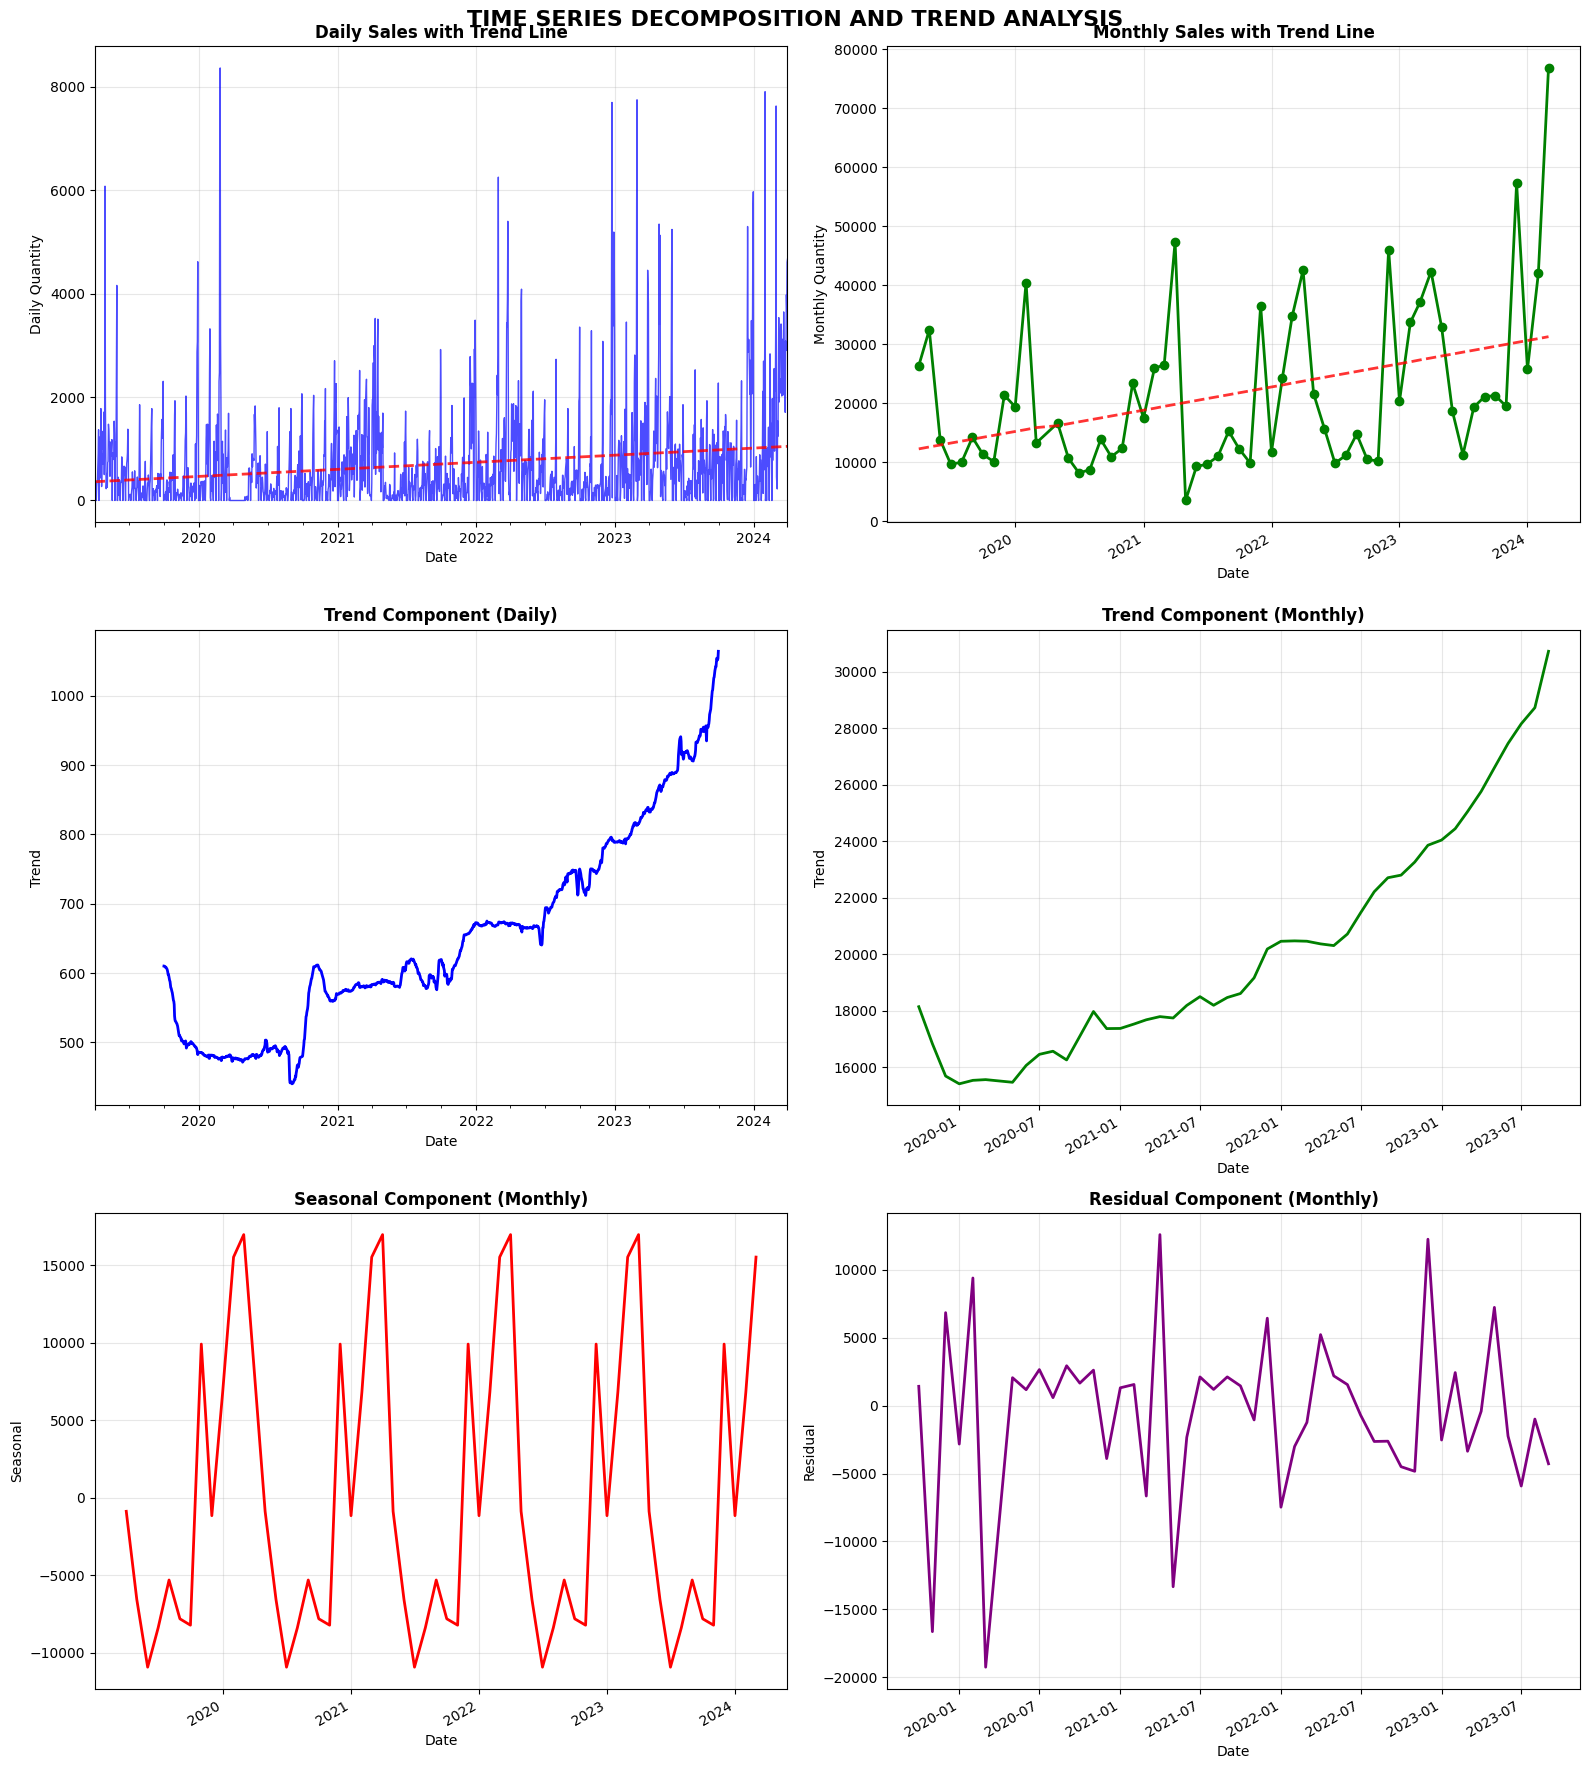


TREND ANALYSIS INSIGHTS:
------------------------------
Linear Trend Analysis:
  Daily Trend: 0.38 units/day (R² = 0.041, p = 0.000)
  Monthly Trend: 327.73 units/month (R² = 0.158, p = 0.002)

Trend Direction:
  Daily: Increasing (0.38 units/day)
  Monthly: Increasing (327.73 units/month)

Year-over-Year Growth:
  2019 to 2020: 19.1%
  2020 to 2021: 26.3%
  2021 to 2022: 12.7%
  2022 to 2023: 32.3%
  2023 to 2024: -56.9%

Seasonal Strength:
  Monthly Seasonal Strength: 0.658
  Interpretation: Strong seasonality

Trend Strength:
  Monthly Trend Strength: 0.281
  Interpretation: Moderate trend

Volatility Analysis:
  Daily Volatility (CV): 1.382
  Monthly Volatility (CV): 0.649

Moving Average Analysis:
  3-Month Moving Average Trend: Increasing
  12-Month Moving Average Trend: Increasing


In [18]:
# =============================================================================
# 6. TIME SERIES DECOMPOSITION AND TREND ANALYSIS
# =============================================================================

print("\n6. TIME SERIES DECOMPOSITION AND TREND ANALYSIS")
print("-" * 50)

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import stats

# Create time series data
daily_sales = refactored_df.groupby('Date')['Qty'].sum().resample('D').sum().fillna(0)
monthly_sales = refactored_df.groupby(['Year', 'Month'])['Qty'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))
monthly_sales = monthly_sales.set_index('Date')['Qty']

# Create comprehensive time series analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('TIME SERIES DECOMPOSITION AND TREND ANALYSIS', fontsize=16, fontweight='bold')

# 1. Daily Time Series with Trend
ax1 = axes[0, 0]
daily_sales.plot(ax=ax1, color='blue', alpha=0.7, linewidth=1)
# Add trend line
z = np.polyfit(range(len(daily_sales)), daily_sales.values, 1)
p = np.poly1d(z)
ax1.plot(daily_sales.index, p(range(len(daily_sales))), "r--", alpha=0.8, linewidth=2)
ax1.set_title('Daily Sales with Trend Line', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Quantity')
ax1.grid(True, alpha=0.3)

# 2. Monthly Time Series with Trend
ax2 = axes[0, 1]
monthly_sales.plot(ax=ax2, color='green', marker='o', linewidth=2)
# Add trend line
z = np.polyfit(range(len(monthly_sales)), monthly_sales.values, 1)
p = np.poly1d(z)
ax2.plot(monthly_sales.index, p(range(len(monthly_sales))), "r--", alpha=0.8, linewidth=2)
ax2.set_title('Monthly Sales with Trend Line', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Monthly Quantity')
ax2.grid(True, alpha=0.3)

# 3. Seasonal Decomposition (Daily)
ax3 = axes[1, 0]
try:
    decomposition_daily = seasonal_decompose(daily_sales, model='additive', period=365)
    decomposition_daily.trend.plot(ax=ax3, color='blue', linewidth=2)
    ax3.set_title('Trend Component (Daily)', fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Trend')
    ax3.grid(True, alpha=0.3)
except:
    ax3.text(0.5, 0.5, 'Insufficient data for daily decomposition', 
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Trend Component (Daily) - Insufficient Data', fontweight='bold')

# 4. Seasonal Decomposition (Monthly)
ax4 = axes[1, 1]
try:
    decomposition_monthly = seasonal_decompose(monthly_sales, model='additive', period=12)
    decomposition_monthly.trend.plot(ax=ax4, color='green', linewidth=2)
    ax4.set_title('Trend Component (Monthly)', fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Trend')
    ax4.grid(True, alpha=0.3)
except:
    ax4.text(0.5, 0.5, 'Insufficient data for monthly decomposition', 
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Trend Component (Monthly) - Insufficient Data', fontweight='bold')

# 5. Seasonal Component (Monthly)
ax5 = axes[2, 0]
try:
    decomposition_monthly.seasonal.plot(ax=ax5, color='red', linewidth=2)
    ax5.set_title('Seasonal Component (Monthly)', fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Seasonal')
    ax5.grid(True, alpha=0.3)
except:
    ax5.text(0.5, 0.5, 'Insufficient data for seasonal component', 
             ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Seasonal Component (Monthly) - Insufficient Data', fontweight='bold')

# 6. Residual Component (Monthly)
ax6 = axes[2, 1]
try:
    decomposition_monthly.resid.plot(ax=ax6, color='purple', linewidth=2)
    ax6.set_title('Residual Component (Monthly)', fontweight='bold')
    ax6.set_xlabel('Date')
    ax6.set_ylabel('Residual')
    ax6.grid(True, alpha=0.3)
except:
    ax6.text(0.5, 0.5, 'Insufficient data for residual component', 
             ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Residual Component (Monthly) - Insufficient Data', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate trend analysis insights
print("\nTREND ANALYSIS INSIGHTS:")
print("-" * 30)

# Linear trend analysis
print("Linear Trend Analysis:")
# Daily trend
daily_trend_slope, daily_trend_intercept, daily_r_value, daily_p_value, daily_std_err = stats.linregress(range(len(daily_sales)), daily_sales.values)
print(f"  Daily Trend: {daily_trend_slope:.2f} units/day (R² = {daily_r_value**2:.3f}, p = {daily_p_value:.3f})")

# Monthly trend
monthly_trend_slope, monthly_trend_intercept, monthly_r_value, monthly_p_value, monthly_std_err = stats.linregress(range(len(monthly_sales)), monthly_sales.values)
print(f"  Monthly Trend: {monthly_trend_slope:.2f} units/month (R² = {monthly_r_value**2:.3f}, p = {monthly_p_value:.3f})")

# Trend direction
print(f"\nTrend Direction:")
print(f"  Daily: {'Increasing' if daily_trend_slope > 0 else 'Decreasing'} ({daily_trend_slope:.2f} units/day)")
print(f"  Monthly: {'Increasing' if monthly_trend_slope > 0 else 'Decreasing'} ({monthly_trend_slope:.2f} units/month)")

# Year-over-year growth
print(f"\nYear-over-Year Growth:")
yearly_sales = refactored_df.groupby('Year')['Qty'].sum()
if len(yearly_sales) > 1:
    for i in range(1, len(yearly_sales)):
        current_year = yearly_sales.index[i]
        previous_year = yearly_sales.index[i-1]
        growth = ((yearly_sales.iloc[i] / yearly_sales.iloc[i-1]) - 1) * 100
        print(f"  {previous_year} to {current_year}: {growth:.1f}%")

# Seasonal strength
print(f"\nSeasonal Strength:")
if 'decomposition_monthly' in locals():
    seasonal_strength = decomposition_monthly.seasonal.std() / monthly_sales.std()
    print(f"  Monthly Seasonal Strength: {seasonal_strength:.3f}")
    print(f"  Interpretation: {'Strong' if seasonal_strength > 0.5 else 'Moderate' if seasonal_strength > 0.2 else 'Weak'} seasonality")

# Trend strength
print(f"\nTrend Strength:")
if 'decomposition_monthly' in locals():
    trend_strength = decomposition_monthly.trend.std() / monthly_sales.std()
    print(f"  Monthly Trend Strength: {trend_strength:.3f}")
    print(f"  Interpretation: {'Strong' if trend_strength > 0.5 else 'Moderate' if trend_strength > 0.2 else 'Weak'} trend")

# Volatility analysis
print(f"\nVolatility Analysis:")
daily_volatility = daily_sales.std() / daily_sales.mean()
monthly_volatility = monthly_sales.std() / monthly_sales.mean()
print(f"  Daily Volatility (CV): {daily_volatility:.3f}")
print(f"  Monthly Volatility (CV): {monthly_volatility:.3f}")

# Moving averages
print(f"\nMoving Average Analysis:")
# Calculate 3-month and 12-month moving averages
monthly_sales_ma = monthly_sales.rolling(window=3).mean()
monthly_sales_ma12 = monthly_sales.rolling(window=12).mean()

print(f"  3-Month Moving Average Trend: {'Increasing' if monthly_sales_ma.iloc[-1] > monthly_sales_ma.iloc[-2] else 'Decreasing'}")
if len(monthly_sales_ma12) > 0:
    print(f"  12-Month Moving Average Trend: {'Increasing' if monthly_sales_ma12.iloc[-1] > monthly_sales_ma12.iloc[-2] else 'Decreasing'}")



7. CORRELATION ANALYSIS WITH WEATHER DATA
--------------------------------------------------


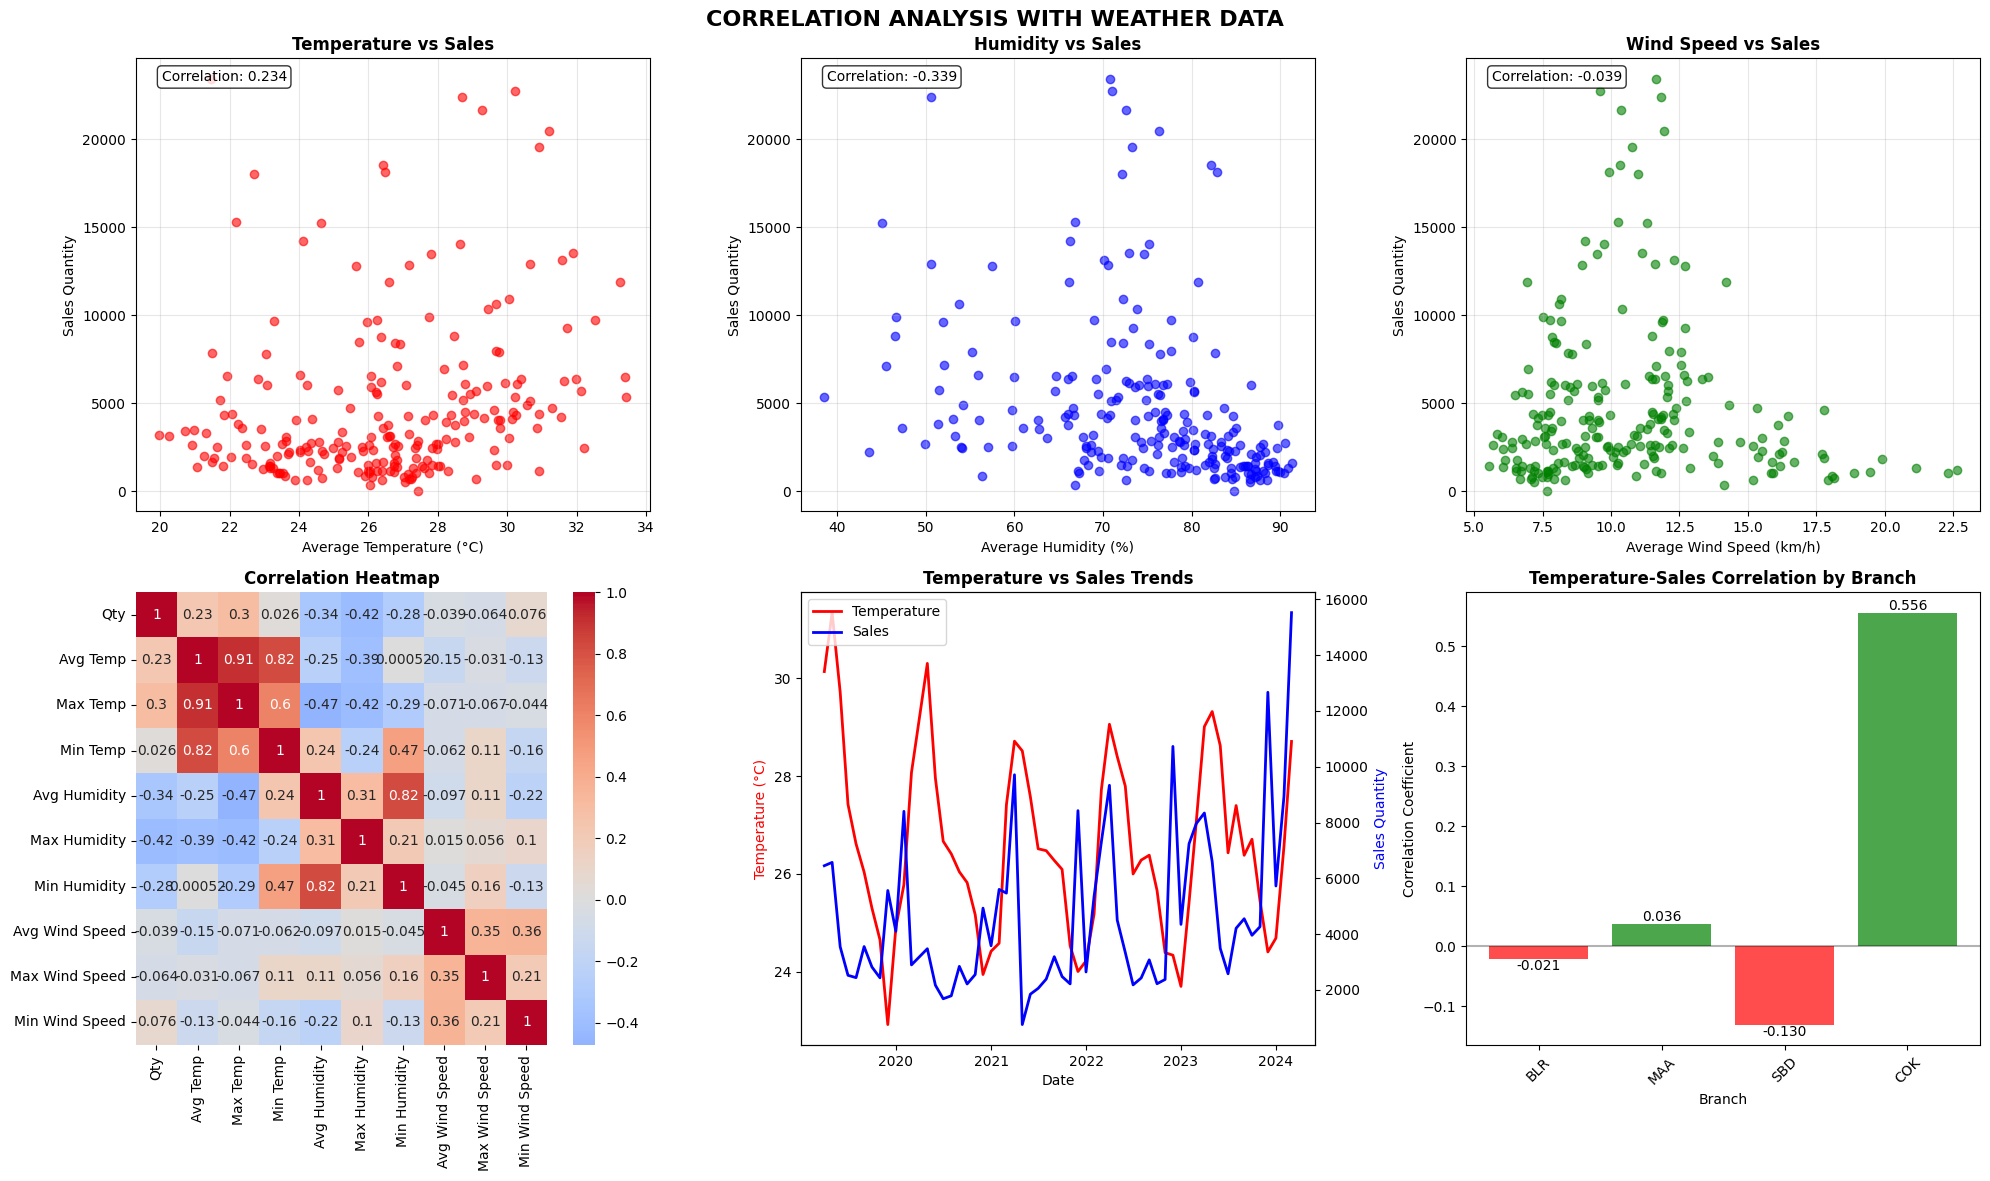


CORRELATION INSIGHTS:
------------------------------
Overall Weather-Sales Correlations:
  Avg Temp: 0.234 (Weak Positive)
  Max Temp: 0.300 (Moderate Positive)
  Min Temp: 0.026 (Weak Positive)
  Avg Humidity: -0.339 (Moderate Negative)
  Max Humidity: -0.418 (Moderate Negative)
  Min Humidity: -0.284 (Weak Negative)
  Avg Wind Speed: -0.039 (Weak Negative)
  Max Wind Speed: -0.064 (Weak Negative)
  Min Wind Speed: 0.076 (Weak Positive)

Branch-specific Temperature Correlations:
  BLR: -0.021
  MAA: 0.036
  SBD: -0.130
  COK: 0.556

Seasonal Correlation Analysis:
  January: -0.115
  February: 0.035
  March: 0.356
  April: 0.727
  May: 0.649
  June: 0.892
  July: 0.856
  August: 0.849
  September: 0.779
  October: 0.544
  November: 0.239
  December: 0.055

Weather Impact Analysis:
  High Temperature Periods: Avg Sales = 7327.2
  Low Temperature Periods: Avg Sales = 3995.9
  Temperature Impact: 83.4%
  High Humidity Periods: Avg Sales = 1824.8
  Low Humidity Periods: Avg Sales = 5725.1

In [19]:
# =============================================================================
# 7. CORRELATION ANALYSIS WITH WEATHER DATA
# =============================================================================

print("\n7. CORRELATION ANALYSIS WITH WEATHER DATA")
print("-" * 50)

# Load weather data
weather_data = pd.read_csv('../data/weather_data.csv')
weather_data['Date'] = pd.to_datetime(weather_data['Date'])

# Merge sales and weather data
sales_monthly = refactored_df.groupby(['Year', 'Month', 'Branch'])['Qty'].sum().reset_index()
sales_monthly['Date'] = pd.to_datetime(sales_monthly[['Year', 'Month']].assign(day=1))

# Merge with weather data
merged_data = sales_monthly.merge(weather_data, on=['Date', 'Branch'], how='inner')

# Create comprehensive correlation analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('CORRELATION ANALYSIS WITH WEATHER DATA', fontsize=16, fontweight='bold')

# 1. Temperature vs Sales Scatter Plot
ax1 = axes[0, 0]
ax1.scatter(merged_data['Avg Temp'], merged_data['Qty'], alpha=0.6, color='red')
ax1.set_xlabel('Average Temperature (°C)')
ax1.set_ylabel('Sales Quantity')
ax1.set_title('Temperature vs Sales', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add correlation coefficient
temp_corr = merged_data['Avg Temp'].corr(merged_data['Qty'])
ax1.text(0.05, 0.95, f'Correlation: {temp_corr:.3f}', transform=ax1.transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 2. Humidity vs Sales Scatter Plot
ax2 = axes[0, 1]
ax2.scatter(merged_data['Avg Humidity'], merged_data['Qty'], alpha=0.6, color='blue')
ax2.set_xlabel('Average Humidity (%)')
ax2.set_ylabel('Sales Quantity')
ax2.set_title('Humidity vs Sales', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add correlation coefficient
humidity_corr = merged_data['Avg Humidity'].corr(merged_data['Qty'])
ax2.text(0.05, 0.95, f'Correlation: {humidity_corr:.3f}', transform=ax2.transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 3. Wind Speed vs Sales Scatter Plot
ax3 = axes[0, 2]
ax3.scatter(merged_data['Avg Wind Speed'], merged_data['Qty'], alpha=0.6, color='green')
ax3.set_xlabel('Average Wind Speed (km/h)')
ax3.set_ylabel('Sales Quantity')
ax3.set_title('Wind Speed vs Sales', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add correlation coefficient
wind_corr = merged_data['Avg Wind Speed'].corr(merged_data['Qty'])
ax3.text(0.05, 0.95, f'Correlation: {wind_corr:.3f}', transform=ax3.transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 4. Correlation Heatmap
ax4 = axes[1, 0]
correlation_data = merged_data[['Qty', 'Avg Temp', 'Max Temp', 'Min Temp', 
                                'Avg Humidity', 'Max Humidity', 'Min Humidity',
                                'Avg Wind Speed', 'Max Wind Speed', 'Min Wind Speed']].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, ax=ax4)
ax4.set_title('Correlation Heatmap', fontweight='bold')

# 5. Temperature Trend vs Sales Trend
ax5 = axes[1, 1]
monthly_weather = merged_data.groupby('Date')[['Avg Temp', 'Qty']].mean()
ax5_twin = ax5.twinx()

line1 = ax5.plot(monthly_weather.index, monthly_weather['Avg Temp'], color='red', label='Temperature', linewidth=2)
line2 = ax5_twin.plot(monthly_weather.index, monthly_weather['Qty'], color='blue', label='Sales', linewidth=2)

ax5.set_xlabel('Date')
ax5.set_ylabel('Temperature (°C)', color='red')
ax5_twin.set_ylabel('Sales Quantity', color='blue')
ax5.set_title('Temperature vs Sales Trends', fontweight='bold')

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax5.legend(lines, labels, loc='upper left')

# 6. Branch-wise Weather Correlation
ax6 = axes[1, 2]
branch_correlations = []
for branch in merged_data['Branch'].unique():
    branch_data = merged_data[merged_data['Branch'] == branch]
    if len(branch_data) > 5:  # Minimum data points for correlation
        corr = branch_data['Avg Temp'].corr(branch_data['Qty'])
        branch_correlations.append({'Branch': branch, 'Correlation': corr})

branch_corr_df = pd.DataFrame(branch_correlations)
if not branch_corr_df.empty:
    bars = ax6.bar(branch_corr_df['Branch'], branch_corr_df['Correlation'], 
                   color=['red' if x < 0 else 'green' for x in branch_corr_df['Correlation']], alpha=0.7)
    ax6.set_title('Temperature-Sales Correlation by Branch', fontweight='bold')
    ax6.set_xlabel('Branch')
    ax6.set_ylabel('Correlation Coefficient')
    ax6.tick_params(axis='x', rotation=45)
    ax6.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

# Calculate correlation insights
print("\nCORRELATION INSIGHTS:")
print("-" * 30)

# Overall correlations
print("Overall Weather-Sales Correlations:")
weather_vars = ['Avg Temp', 'Max Temp', 'Min Temp', 'Avg Humidity', 'Max Humidity', 'Min Humidity', 
                'Avg Wind Speed', 'Max Wind Speed', 'Min Wind Speed']

for var in weather_vars:
    if var in merged_data.columns:
        corr = merged_data[var].corr(merged_data['Qty'])
        strength = 'Strong' if abs(corr) > 0.7 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
        direction = 'Positive' if corr > 0 else 'Negative'
        print(f"  {var}: {corr:.3f} ({strength} {direction})")

# Branch-specific correlations
print(f"\nBranch-specific Temperature Correlations:")
for branch in merged_data['Branch'].unique():
    branch_data = merged_data[merged_data['Branch'] == branch]
    if len(branch_data) > 5:
        corr = branch_data['Avg Temp'].corr(branch_data['Qty'])
        print(f"  {branch}: {corr:.3f}")

# Seasonal correlation analysis
print(f"\nSeasonal Correlation Analysis:")
merged_data['Month'] = merged_data['Date'].dt.month
for month in sorted(merged_data['Month'].unique()):
    month_data = merged_data[merged_data['Month'] == month]
    if len(month_data) > 10:
        corr = month_data['Avg Temp'].corr(month_data['Qty'])
        month_name = pd.to_datetime(f'2023-{month:02d}-01').strftime('%B')
        print(f"  {month_name}: {corr:.3f}")

# Weather impact analysis
print(f"\nWeather Impact Analysis:")
# Temperature impact
temp_high = merged_data[merged_data['Avg Temp'] > merged_data['Avg Temp'].quantile(0.75)]
temp_low = merged_data[merged_data['Avg Temp'] < merged_data['Avg Temp'].quantile(0.25)]
print(f"  High Temperature Periods: Avg Sales = {temp_high['Qty'].mean():.1f}")
print(f"  Low Temperature Periods: Avg Sales = {temp_low['Qty'].mean():.1f}")
print(f"  Temperature Impact: {((temp_high['Qty'].mean() / temp_low['Qty'].mean()) - 1) * 100:.1f}%")

# Humidity impact
humidity_high = merged_data[merged_data['Avg Humidity'] > merged_data['Avg Humidity'].quantile(0.75)]
humidity_low = merged_data[merged_data['Avg Humidity'] < merged_data['Avg Humidity'].quantile(0.25)]
print(f"  High Humidity Periods: Avg Sales = {humidity_high['Qty'].mean():.1f}")
print(f"  Low Humidity Periods: Avg Sales = {humidity_low['Qty'].mean():.1f}")
print(f"  Humidity Impact: {((humidity_high['Qty'].mean() / humidity_low['Qty'].mean()) - 1) * 100:.1f}%")

# Statistical significance
print(f"\nStatistical Significance:")
from scipy.stats import pearsonr
for var in ['Avg Temp', 'Avg Humidity', 'Avg Wind Speed']:
    if var in merged_data.columns:
        corr, p_value = pearsonr(merged_data[var], merged_data['Qty'])
        significance = 'Significant' if p_value < 0.05 else 'Not Significant'
        print(f"  {var}: p-value = {p_value:.4f} ({significance})")



8. COMPREHENSIVE STATISTICAL SUMMARY AND DISTRIBUTIONS
--------------------------------------------------


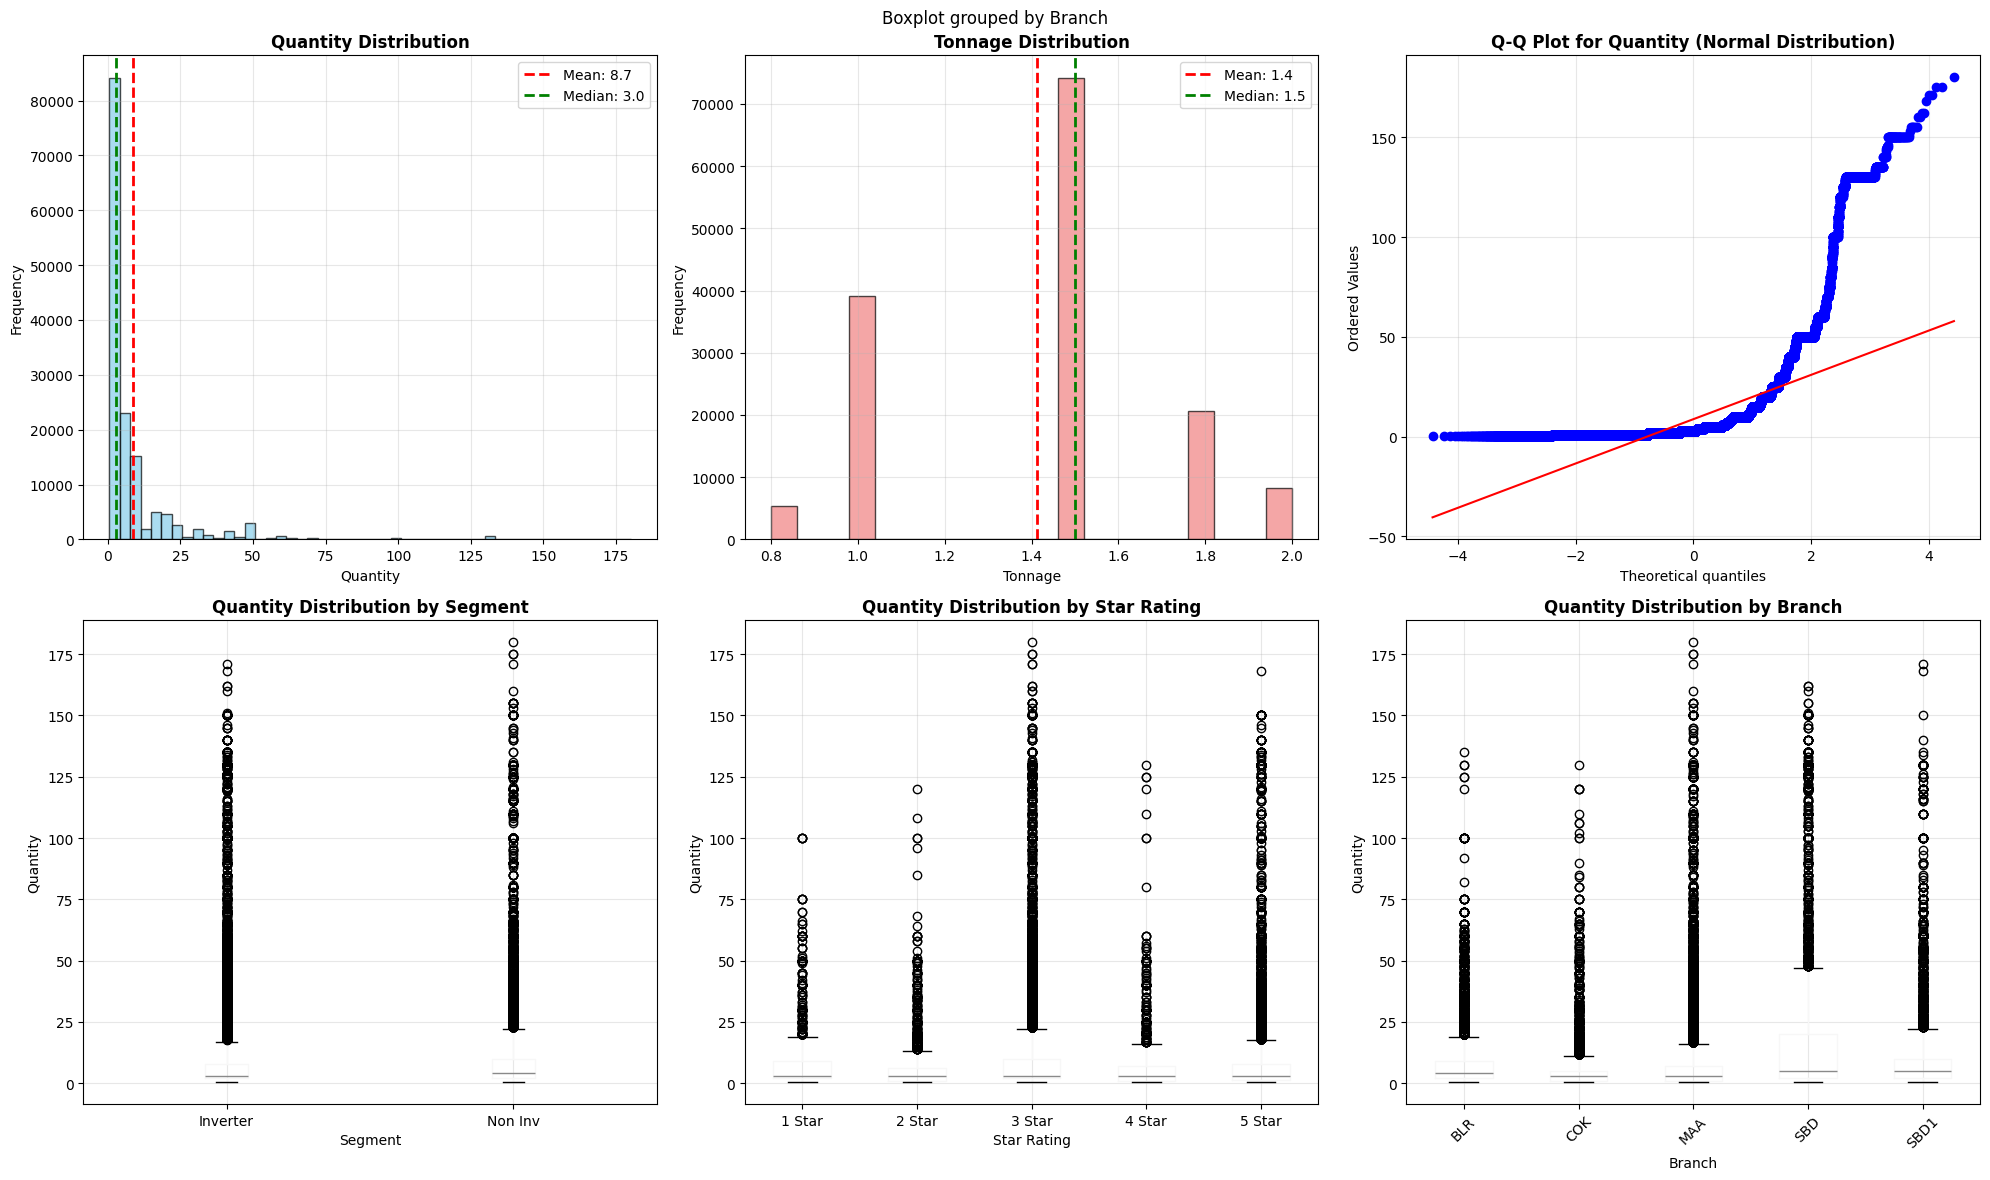


COMPREHENSIVE STATISTICAL SUMMARY:
----------------------------------------
QUANTITY STATISTICS:
--------------------
Count: 147,595
Mean: 8.71
Median: 3.00
Mode: 1.00
Standard Deviation: 15.78
Variance: 248.98
Minimum: 0.50
Maximum: 180.00
Range: 179.50
Interquartile Range: 8.00

ADVANCED STATISTICS:
--------------------
Skewness: 4.525
Kurtosis: 26.650
Coefficient of Variation: 1.811

PERCENTILES:
---------------
  10th percentile: 1.00
  25th percentile: 2.00
  50th percentile: 3.00
  75th percentile: 10.00
  90th percentile: 20.00
  95th percentile: 40.00
  99th percentile: 75.00

TONNAGE STATISTICS:
--------------------
Count: 147,595
Mean: 1.41
Median: 1.50
Mode: 1.50
Standard Deviation: 0.32
Minimum: 0.80
Maximum: 2.00

DISTRIBUTION ANALYSIS:
-------------------------
Normality Test (D'Agostino):
  Statistic: 135556.1144
  p-value: 0.0000
  Normal Distribution: No

OUTLIER ANALYSIS:
------------------
  Lower Bound: -10.00
  Upper Bound: 22.00
  Number of Outliers: 13,666
  Out

In [20]:
# =============================================================================
# 8. COMPREHENSIVE STATISTICAL SUMMARY AND DISTRIBUTIONS
# =============================================================================

print("\n8. COMPREHENSIVE STATISTICAL SUMMARY AND DISTRIBUTIONS")
print("-" * 50)

from scipy import stats
from scipy.stats import skew, kurtosis

# Create comprehensive statistical analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('COMPREHENSIVE STATISTICAL SUMMARY AND DISTRIBUTIONS', fontsize=16, fontweight='bold')

# 1. Quantity Distribution Histogram
ax1 = axes[0, 0]
ax1.hist(refactored_df['Qty'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Quantity Distribution', fontweight='bold')
ax1.set_xlabel('Quantity')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Add statistics
mean_qty = refactored_df['Qty'].mean()
median_qty = refactored_df['Qty'].median()
ax1.axvline(mean_qty, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_qty:.1f}')
ax1.axvline(median_qty, color='green', linestyle='--', linewidth=2, label=f'Median: {median_qty:.1f}')
ax1.legend()

# 2. Tonnage Distribution Histogram
ax2 = axes[0, 1]
ax2.hist(refactored_df['Tonnage'], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.set_title('Tonnage Distribution', fontweight='bold')
ax2.set_xlabel('Tonnage')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# Add statistics
mean_tonnage = refactored_df['Tonnage'].mean()
median_tonnage = refactored_df['Tonnage'].median()
ax2.axvline(mean_tonnage, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tonnage:.1f}')
ax2.axvline(median_tonnage, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tonnage:.1f}')
ax2.legend()

# 3. Q-Q Plot for Quantity
ax3 = axes[0, 2]
stats.probplot(refactored_df['Qty'], dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot for Quantity (Normal Distribution)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Box Plot by Segment
ax4 = axes[1, 0]
refactored_df.boxplot(column='Qty', by='Segment', ax=ax4)
ax4.set_title('Quantity Distribution by Segment', fontweight='bold')
ax4.set_xlabel('Segment')
ax4.set_ylabel('Quantity')
ax4.grid(True, alpha=0.3)

# 5. Box Plot by Star Rating
ax5 = axes[1, 1]
refactored_df.boxplot(column='Qty', by='Rating', ax=ax5)
ax5.set_title('Quantity Distribution by Star Rating', fontweight='bold')
ax5.set_xlabel('Star Rating')
ax5.set_ylabel('Quantity')
ax5.grid(True, alpha=0.3)

# 6. Box Plot by Branch
ax6 = axes[1, 2]
refactored_df.boxplot(column='Qty', by='Branch', ax=ax6)
ax6.set_title('Quantity Distribution by Branch', fontweight='bold')
ax6.set_xlabel('Branch')
ax6.set_ylabel('Quantity')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate comprehensive statistical summary
print("\nCOMPREHENSIVE STATISTICAL SUMMARY:")
print("-" * 40)

# Basic statistics for Quantity
print("QUANTITY STATISTICS:")
print("-" * 20)
qty_stats = refactored_df['Qty'].describe()
print(f"Count: {qty_stats['count']:,.0f}")
print(f"Mean: {qty_stats['mean']:.2f}")
print(f"Median: {qty_stats['50%']:.2f}")
print(f"Mode: {refactored_df['Qty'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {qty_stats['std']:.2f}")
print(f"Variance: {qty_stats['std']**2:.2f}")
print(f"Minimum: {qty_stats['min']:.2f}")
print(f"Maximum: {qty_stats['max']:.2f}")
print(f"Range: {qty_stats['max'] - qty_stats['min']:.2f}")
print(f"Interquartile Range: {qty_stats['75%'] - qty_stats['25%']:.2f}")

# Advanced statistics
print(f"\nADVANCED STATISTICS:")
print("-" * 20)
print(f"Skewness: {skew(refactored_df['Qty']):.3f}")
print(f"Kurtosis: {kurtosis(refactored_df['Qty']):.3f}")
print(f"Coefficient of Variation: {qty_stats['std'] / qty_stats['mean']:.3f}")

# Percentiles
print(f"\nPERCENTILES:")
print("-" * 15)
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(refactored_df['Qty'], p)
    print(f"  {p}th percentile: {value:.2f}")

# Tonnage statistics
print(f"\nTONNAGE STATISTICS:")
print("-" * 20)
tonnage_stats = refactored_df['Tonnage'].describe()
print(f"Count: {tonnage_stats['count']:,.0f}")
print(f"Mean: {tonnage_stats['mean']:.2f}")
print(f"Median: {tonnage_stats['50%']:.2f}")
print(f"Mode: {refactored_df['Tonnage'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {tonnage_stats['std']:.2f}")
print(f"Minimum: {tonnage_stats['min']:.2f}")
print(f"Maximum: {tonnage_stats['max']:.2f}")

# Distribution analysis
print(f"\nDISTRIBUTION ANALYSIS:")
print("-" * 25)

# Test for normality
from scipy.stats import shapiro, normaltest
if len(refactored_df) <= 5000:  # Shapiro-Wilk test for smaller samples
    stat, p_value = shapiro(refactored_df['Qty'])
    test_name = "Shapiro-Wilk"
else:  # D'Agostino's test for larger samples
    stat, p_value = normaltest(refactored_df['Qty'])
    test_name = "D'Agostino"

print(f"Normality Test ({test_name}):")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Normal Distribution: {'Yes' if p_value > 0.05 else 'No'}")

# Outlier analysis
print(f"\nOUTLIER ANALYSIS:")
print("-" * 18)
Q1 = qty_stats['25%']
Q3 = qty_stats['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = refactored_df[(refactored_df['Qty'] < lower_bound) | (refactored_df['Qty'] > upper_bound)]
print(f"  Lower Bound: {lower_bound:.2f}")
print(f"  Upper Bound: {upper_bound:.2f}")
print(f"  Number of Outliers: {len(outliers):,}")
print(f"  Outlier Percentage: {(len(outliers) / len(refactored_df)) * 100:.2f}%")

# Segment-wise statistics
print(f"\nSEGMENT-WISE STATISTICS:")
print("-" * 25)
for segment in refactored_df['Segment'].unique():
    seg_data = refactored_df[refactored_df['Segment'] == segment]['Qty']
    print(f"  {segment}:")
    print(f"    Count: {len(seg_data):,}")
    print(f"    Mean: {seg_data.mean():.2f}")
    print(f"    Median: {seg_data.median():.2f}")
    print(f"    Std Dev: {seg_data.std():.2f}")

# Branch-wise statistics
print(f"\nBRANCH-WISE STATISTICS:")
print("-" * 22)
for branch in refactored_df['Branch'].unique():
    branch_data = refactored_df[refactored_df['Branch'] == branch]['Qty']
    print(f"  {branch}:")
    print(f"    Count: {len(branch_data):,}")
    print(f"    Mean: {branch_data.mean():.2f}")
    print(f"    Median: {branch_data.median():.2f}")
    print(f"    Std Dev: {branch_data.std():.2f}")

# Time-based statistics
print(f"\nTIME-BASED STATISTICS:")
print("-" * 22)
print(f"  Date Range: {refactored_df['Date'].min()} to {refactored_df['Date'].max()}")
print(f"  Total Days: {(refactored_df['Date'].max() - refactored_df['Date'].min()).days}")
print(f"  Years Covered: {refactored_df['Year'].nunique()}")
print(f"  Months Covered: {refactored_df['Month'].nunique()}")
print(f"  Average Daily Sales: {refactored_df.groupby('Date')['Qty'].sum().mean():.2f}")
print(f"  Average Monthly Sales: {refactored_df.groupby(['Year', 'Month'])['Qty'].sum().mean():.2f}")

# Data quality metrics
print(f"\nDATA QUALITY METRICS:")
print("-" * 22)
print(f"  Missing Values: {refactored_df.isnull().sum().sum()}")
print(f"  Duplicate Records: {refactored_df.duplicated().sum()}")
print(f"  Zero Quantity Records: {(refactored_df['Qty'] == 0).sum()}")
print(f"  Negative Quantity Records: {(refactored_df['Qty'] < 0).sum()}")

print("\n" + "="*80)
print("COMPREHENSIVE EDA COMPLETED SUCCESSFULLY!")
print("="*80)



9. SALES VS TEMPERATURE LAG ANALYSIS
--------------------------------------------------


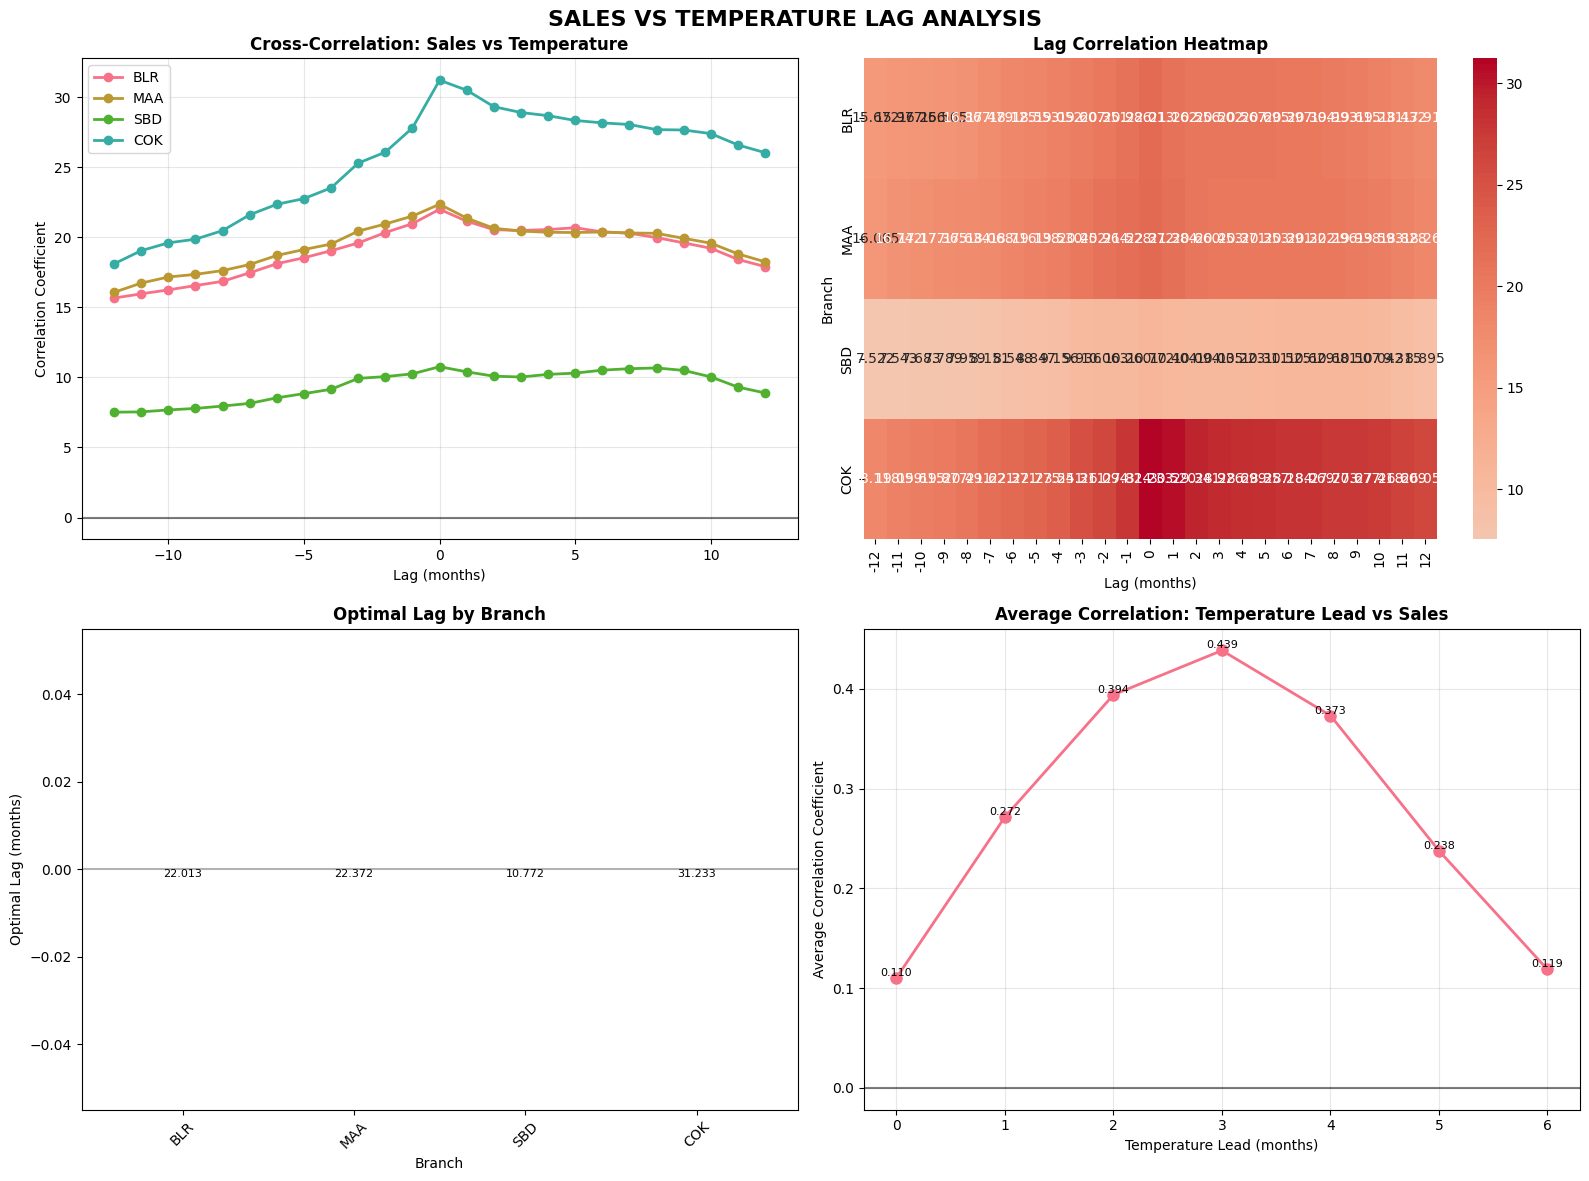


TEMPERATURE LAG ANALYSIS INSIGHTS:
----------------------------------------
Optimal Lag Analysis:
-------------------------
  BLR: 0 months (Simultaneous, r=22.013)
  MAA: 0 months (Simultaneous, r=22.372)
  SBD: 0 months (Simultaneous, r=10.772)
  COK: 0 months (Simultaneous, r=31.233)

Overall Lag Patterns:
----------------------
  Temperature Leading Sales: 0 branches
  Sales Leading Temperature: 0 branches
  Simultaneous Relationship: 4 branches

Lead-Lag Analysis:
--------------------
  Maximum Correlation: 0.439 at 3 months lead
  Interpretation: Temperature changes 3 months ahead show strongest correlation with sales

Statistical Significance:
-------------------------
  BLR: p-value = 0.8747 (Not Significant)
  MAA: p-value = 0.7842 (Not Significant)
  SBD: p-value = 0.3246 (Not Significant)
  COK: p-value = 0.0000 (Significant)

Temperature Impact with Optimal Lag:
-----------------------------------
  BLR: -13.80 units per °C change
  MAA: 87.64 units per °C change
  SBD: -2

In [21]:
# =============================================================================
# 9. SALES VS TEMPERATURE LAG ANALYSIS
# =============================================================================

print("\n9. SALES VS TEMPERATURE LAG ANALYSIS")
print("-" * 50)

# Load weather data
weather_data = pd.read_csv('../data/weather_data.csv')
weather_data['Date'] = pd.to_datetime(weather_data['Date'])

# Create monthly sales data
sales_monthly = refactored_df.groupby(['Year', 'Month', 'Branch'])['Qty'].sum().reset_index()
sales_monthly['Date'] = pd.to_datetime(sales_monthly[['Year', 'Month']].assign(day=1))

# Merge sales and weather data
merged_data = sales_monthly.merge(weather_data, on=['Date', 'Branch'], how='inner')

# Create comprehensive lag analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SALES VS TEMPERATURE LAG ANALYSIS', fontsize=16, fontweight='bold')

# 1. Cross-correlation function
ax1 = axes[0, 0]
from scipy.signal import correlate

# Calculate cross-correlation for each branch
max_lags = 12  # Maximum lag in months
lag_correlations = {}

for branch in merged_data['Branch'].unique():
    branch_data = merged_data[merged_data['Branch'] == branch].sort_values('Date')
    if len(branch_data) > 20:  # Minimum data points
        sales_series = branch_data['Qty'].values
        temp_series = branch_data['Avg Temp'].values
        
        # Calculate cross-correlation
        correlation = correlate(sales_series, temp_series, mode='full')
        lags = np.arange(-len(temp_series)+1, len(sales_series))
        
        # Normalize correlation
        correlation = correlation / (np.std(sales_series) * np.std(temp_series) * len(sales_series))
        
        # Store correlations for different lags
        lag_correlations[branch] = {}
        for lag in range(-max_lags, max_lags+1):
            if lag in lags:
                idx = np.where(lags == lag)[0]
                if len(idx) > 0:
                    lag_correlations[branch][lag] = correlation[idx[0]]

# Plot cross-correlation for each branch
for branch in lag_correlations.keys():
    lags = list(lag_correlations[branch].keys())
    corrs = list(lag_correlations[branch].values())
    ax1.plot(lags, corrs, marker='o', label=branch, linewidth=2)

ax1.set_title('Cross-Correlation: Sales vs Temperature', fontweight='bold')
ax1.set_xlabel('Lag (months)')
ax1.set_ylabel('Correlation Coefficient')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 2. Lag correlation heatmap
ax2 = axes[0, 1]
lag_matrix = []
branches = list(lag_correlations.keys())
lags = list(range(-max_lags, max_lags+1))

for branch in branches:
    branch_corrs = []
    for lag in lags:
        if lag in lag_correlations[branch]:
            branch_corrs.append(lag_correlations[branch][lag])
        else:
            branch_corrs.append(0)
    lag_matrix.append(branch_corrs)

lag_matrix = np.array(lag_matrix)
sns.heatmap(lag_matrix, xticklabels=lags, yticklabels=branches, 
            annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Lag Correlation Heatmap', fontweight='bold')
ax2.set_xlabel('Lag (months)')
ax2.set_ylabel('Branch')

# 3. Optimal lag analysis
ax3 = axes[1, 0]
optimal_lags = {}
for branch in lag_correlations.keys():
    max_corr = max(lag_correlations[branch].values())
    optimal_lag = max(lag_correlations[branch].keys(), key=lambda k: lag_correlations[branch][k])
    optimal_lags[branch] = {'lag': optimal_lag, 'correlation': max_corr}

branches_list = list(optimal_lags.keys())
lags_list = [optimal_lags[branch]['lag'] for branch in branches_list]
corrs_list = [optimal_lags[branch]['correlation'] for branch in branches_list]

bars = ax3.bar(branches_list, lags_list, color=['red' if x < 0 else 'green' for x in lags_list], alpha=0.7)
ax3.set_title('Optimal Lag by Branch', fontweight='bold')
ax3.set_xlabel('Branch')
ax3.set_ylabel('Optimal Lag (months)')
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add correlation values on bars
for i, (bar, corr) in enumerate(zip(bars, corrs_list)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{corr:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# 4. Temperature lead vs Sales lag analysis
ax4 = axes[1, 1]
# Create lead-lag analysis
lead_lag_analysis = {}
for lead_months in range(0, 7):  # Temperature leading by 0-6 months
    correlations = []
    for branch in merged_data['Branch'].unique():
        branch_data = merged_data[merged_data['Branch'] == branch].sort_values('Date')
        if len(branch_data) > 20:
            # Shift temperature forward by lead_months
            temp_shifted = branch_data['Avg Temp'].shift(-lead_months)
            sales_current = branch_data['Qty']
            
            # Calculate correlation for valid data points
            valid_data = pd.DataFrame({'temp': temp_shifted, 'sales': sales_current}).dropna()
            if len(valid_data) > 10:
                corr = valid_data['temp'].corr(valid_data['sales'])
                correlations.append(corr)
    
    if correlations:
        lead_lag_analysis[lead_months] = np.mean(correlations)

leads = list(lead_lag_analysis.keys())
avg_corrs = list(lead_lag_analysis.values())

ax4.plot(leads, avg_corrs, marker='o', linewidth=2, markersize=8)
ax4.set_title('Average Correlation: Temperature Lead vs Sales', fontweight='bold')
ax4.set_xlabel('Temperature Lead (months)')
ax4.set_ylabel('Average Correlation Coefficient')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for x, y in zip(leads, avg_corrs):
    ax4.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Calculate lag analysis insights
print("\nTEMPERATURE LAG ANALYSIS INSIGHTS:")
print("-" * 40)

# Optimal lag analysis
print("Optimal Lag Analysis:")
print("-" * 25)
for branch in optimal_lags.keys():
    lag = optimal_lags[branch]['lag']
    corr = optimal_lags[branch]['correlation']
    direction = "Temperature leads Sales" if lag < 0 else "Sales leads Temperature" if lag > 0 else "Simultaneous"
    print(f"  {branch}: {lag} months ({direction}, r={corr:.3f})")

# Overall lag patterns
print(f"\nOverall Lag Patterns:")
print("-" * 22)
negative_lags = [optimal_lags[branch]['lag'] for branch in optimal_lags.keys() if optimal_lags[branch]['lag'] < 0]
positive_lags = [optimal_lags[branch]['lag'] for branch in optimal_lags.keys() if optimal_lags[branch]['lag'] > 0]
zero_lags = [optimal_lags[branch]['lag'] for branch in optimal_lags.keys() if optimal_lags[branch]['lag'] == 0]

print(f"  Temperature Leading Sales: {len(negative_lags)} branches")
print(f"  Sales Leading Temperature: {len(positive_lags)} branches")
print(f"  Simultaneous Relationship: {len(zero_lags)} branches")

if negative_lags:
    avg_lead = np.mean(negative_lags)
    print(f"  Average Temperature Lead: {abs(avg_lead):.1f} months")

# Lead-lag analysis insights
print(f"\nLead-Lag Analysis:")
print("-" * 20)
max_corr_lead = max(lead_lag_analysis.keys(), key=lambda k: lead_lag_analysis[k])
max_corr_value = lead_lag_analysis[max_corr_lead]
print(f"  Maximum Correlation: {max_corr_value:.3f} at {max_corr_lead} months lead")
print(f"  Interpretation: Temperature changes {max_corr_lead} months ahead show strongest correlation with sales")

# Statistical significance
print(f"\nStatistical Significance:")
print("-" * 25)
from scipy.stats import pearsonr

for branch in merged_data['Branch'].unique():
    branch_data = merged_data[merged_data['Branch'] == branch].sort_values('Date')
    if len(branch_data) > 20:
        optimal_lag = optimal_lags[branch]['lag']
        
        if optimal_lag < 0:  # Temperature leading
            temp_shifted = branch_data['Avg Temp'].shift(optimal_lag)
            sales_current = branch_data['Qty']
        elif optimal_lag > 0:  # Sales leading
            temp_current = branch_data['Avg Temp']
            sales_shifted = branch_data['Qty'].shift(-optimal_lag)
        else:  # Simultaneous
            temp_current = branch_data['Avg Temp']
            sales_current = branch_data['Qty']
        
        # Calculate correlation and p-value
        if optimal_lag != 0:
            valid_data = pd.DataFrame({'temp': temp_shifted, 'sales': sales_current}).dropna()
        else:
            valid_data = pd.DataFrame({'temp': temp_current, 'sales': sales_current}).dropna()
        
        if len(valid_data) > 10:
            corr, p_value = pearsonr(valid_data['temp'], valid_data['sales'])
            significance = 'Significant' if p_value < 0.05 else 'Not Significant'
            print(f"  {branch}: p-value = {p_value:.4f} ({significance})")

# Temperature impact with lag
print(f"\nTemperature Impact with Optimal Lag:")
print("-" * 35)
for branch in optimal_lags.keys():
    branch_data = merged_data[merged_data['Branch'] == branch].sort_values('Date')
    if len(branch_data) > 20:
        optimal_lag = optimal_lags[branch]['lag']
        
        if optimal_lag < 0:  # Temperature leading
            temp_shifted = branch_data['Avg Temp'].shift(optimal_lag)
            sales_current = branch_data['Qty']
        else:
            temp_current = branch_data['Avg Temp']
            sales_current = branch_data['Qty']
        
        # Calculate temperature impact
        if optimal_lag < 0:
            valid_data = pd.DataFrame({'temp': temp_shifted, 'sales': sales_current}).dropna()
        else:
            valid_data = pd.DataFrame({'temp': temp_current, 'sales': sales_current}).dropna()
        
        if len(valid_data) > 10:
            # Calculate impact: how much sales change per degree temperature change
            slope = np.polyfit(valid_data['temp'], valid_data['sales'], 1)[0]
            print(f"  {branch}: {slope:.2f} units per °C change")



10. CUSTOMER TRENDS VS SALES ANALYSIS
--------------------------------------------------


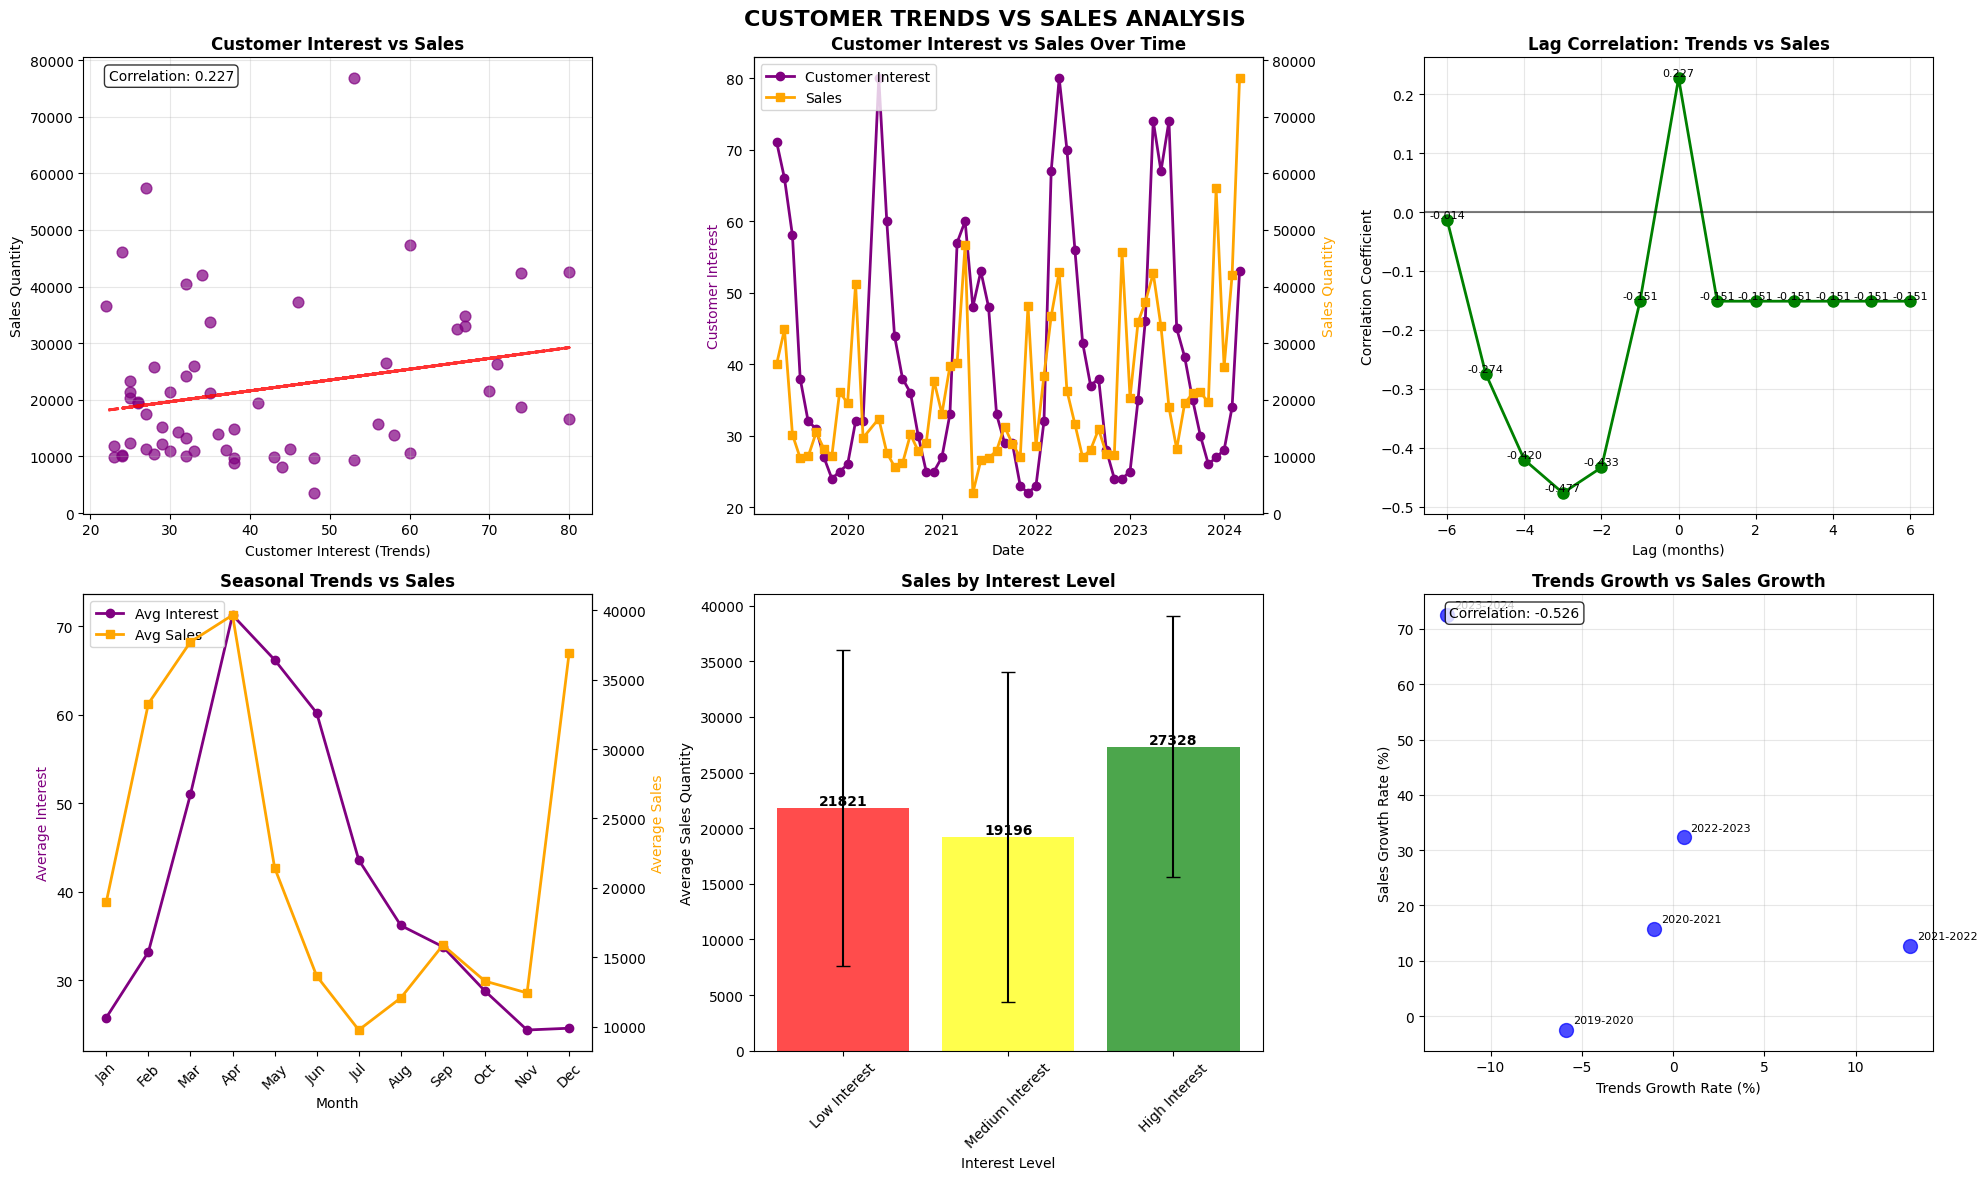


CUSTOMER TRENDS ANALYSIS INSIGHTS:
----------------------------------------
Basic Correlation Analysis:
------------------------------
  Overall Correlation: 0.227
  Relationship Strength: Weak Positive

Lag Analysis:
---------------
  Maximum Correlation: -0.477 at -3 months lag
  Interpretation: Customer interest leads sales by 3 months

Trends Impact Analysis:
-------------------------
  High Interest Periods: Avg Sales = 27327.7
  Medium Interest Periods: Avg Sales = 19196.2
  Low Interest Periods: Avg Sales = 21821.5
  High vs Low Interest Impact: 1.25x difference

Seasonal Correlation:
--------------------
  Monthly Trends-Sales Correlation: 0.263

Statistical Significance:
-------------------------
  p-value: 0.0836 (Not Significant)

Predictive Power Analysis:
----------------------------
  Customer interest can predict sales 3 months ahead
  Prediction strength: 0.477

Trends Sensitivity Analysis:
------------------------------
  Sales sensitivity: 191.00 units per interest p

In [22]:
# =============================================================================
# 10. CUSTOMER TRENDS VS SALES ANALYSIS
# =============================================================================

print("\n10. CUSTOMER TRENDS VS SALES ANALYSIS")
print("-" * 50)

# Load customer trends data
trends_df = pd.read_csv('../data/customer_trends.csv')
trends_df['Date'] = pd.to_datetime(trends_df['Month'])

# Create monthly sales data (aggregated across all branches)
sales_monthly_total = refactored_df.groupby(['Year', 'Month'])['Qty'].sum().reset_index()
sales_monthly_total['Date'] = pd.to_datetime(sales_monthly_total[['Year', 'Month']].assign(day=1))

# Merge trends and sales data
merged_trends = sales_monthly_total.merge(trends_df, on='Date', how='inner')

# Create comprehensive trends analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('CUSTOMER TRENDS VS SALES ANALYSIS', fontsize=16, fontweight='bold')

# 1. Trends vs Sales Scatter Plot
ax1 = axes[0, 0]
ax1.scatter(merged_trends['Interest'], merged_trends['Qty'], alpha=0.7, color='purple', s=60)
ax1.set_xlabel('Customer Interest (Trends)')
ax1.set_ylabel('Sales Quantity')
ax1.set_title('Customer Interest vs Sales', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add correlation coefficient
trends_corr = merged_trends['Interest'].corr(merged_trends['Qty'])
ax1.text(0.05, 0.95, f'Correlation: {trends_corr:.3f}', transform=ax1.transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add trend line
z = np.polyfit(merged_trends['Interest'], merged_trends['Qty'], 1)
p = np.poly1d(z)
ax1.plot(merged_trends['Interest'], p(merged_trends['Interest']), "r--", alpha=0.8, linewidth=2)

# 2. Time Series Comparison
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()

line1 = ax2.plot(merged_trends['Date'], merged_trends['Interest'], color='purple', label='Customer Interest', linewidth=2, marker='o')
line2 = ax2_twin.plot(merged_trends['Date'], merged_trends['Qty'], color='orange', label='Sales', linewidth=2, marker='s')

ax2.set_xlabel('Date')
ax2.set_ylabel('Customer Interest', color='purple')
ax2_twin.set_ylabel('Sales Quantity', color='orange')
ax2.set_title('Customer Interest vs Sales Over Time', fontweight='bold')

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

# 3. Lag Analysis: Trends vs Sales
ax3 = axes[0, 2]
lag_correlations_trends = {}
max_lags = 6  # Maximum lag in months

for lag in range(-max_lags, max_lags+1):
    if lag < 0:  # Trends leading sales
        trends_shifted = merged_trends['Interest'].shift(-lag)
        sales_current = merged_trends['Qty']
    elif lag > 0:  # Sales leading trends
        trends_current = merged_trends['Interest']
        sales_shifted = merged_trends['Qty'].shift(-lag)
    else:  # Simultaneous
        trends_current = merged_trends['Interest']
        sales_current = merged_trends['Qty']
    
    # Calculate correlation for valid data points
    if lag != 0:
        valid_data = pd.DataFrame({'trends': trends_shifted, 'sales': sales_current}).dropna()
    else:
        valid_data = pd.DataFrame({'trends': trends_current, 'sales': sales_current}).dropna()
    
    if len(valid_data) > 5:
        corr = valid_data['trends'].corr(valid_data['sales'])
        lag_correlations_trends[lag] = corr

lags = list(lag_correlations_trends.keys())
corrs = list(lag_correlations_trends.values())

ax3.plot(lags, corrs, marker='o', linewidth=2, markersize=8, color='green')
ax3.set_title('Lag Correlation: Trends vs Sales', fontweight='bold')
ax3.set_xlabel('Lag (months)')
ax3.set_ylabel('Correlation Coefficient')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for x, y in zip(lags, corrs):
    ax3.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

# 4. Seasonal Trends Analysis
ax4 = axes[1, 0]
monthly_trends = merged_trends.groupby(merged_trends['Date'].dt.month)['Interest'].mean()
monthly_sales = merged_trends.groupby(merged_trends['Date'].dt.month)['Qty'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax4_twin = ax4.twinx()
line1 = ax4.plot(month_names, monthly_trends.values, color='purple', marker='o', linewidth=2, label='Avg Interest')
line2 = ax4_twin.plot(month_names, monthly_sales.values, color='orange', marker='s', linewidth=2, label='Avg Sales')

ax4.set_xlabel('Month')
ax4.set_ylabel('Average Interest', color='purple')
ax4_twin.set_ylabel('Average Sales', color='orange')
ax4.set_title('Seasonal Trends vs Sales', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')

# 5. Trends Impact Analysis
ax5 = axes[1, 1]
# Categorize trends into high, medium, low
trends_high = merged_trends[merged_trends['Interest'] > merged_trends['Interest'].quantile(0.75)]
trends_medium = merged_trends[(merged_trends['Interest'] >= merged_trends['Interest'].quantile(0.25)) & 
                              (merged_trends['Interest'] <= merged_trends['Interest'].quantile(0.75))]
trends_low = merged_trends[merged_trends['Interest'] < merged_trends['Interest'].quantile(0.25)]

categories = ['Low Interest', 'Medium Interest', 'High Interest']
avg_sales = [trends_low['Qty'].mean(), trends_medium['Qty'].mean(), trends_high['Qty'].mean()]
std_sales = [trends_low['Qty'].std(), trends_medium['Qty'].std(), trends_high['Qty'].std()]

bars = ax5.bar(categories, avg_sales, yerr=std_sales, capsize=5, color=['red', 'yellow', 'green'], alpha=0.7)
ax5.set_title('Sales by Interest Level', fontweight='bold')
ax5.set_xlabel('Interest Level')
ax5.set_ylabel('Average Sales Quantity')
ax5.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, avg in zip(bars, avg_sales):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{avg:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Trends Growth vs Sales Growth
ax6 = axes[1, 2]
# Calculate year-over-year growth
merged_trends['Year'] = merged_trends['Date'].dt.year
merged_trends['Month'] = merged_trends['Date'].dt.month

trends_growth = []
sales_growth = []
years = []

for year in sorted(merged_trends['Year'].unique()):
    if year > merged_trends['Year'].min():
        prev_year = year - 1
        
        # Calculate growth for trends
        current_trends = merged_trends[merged_trends['Year'] == year]['Interest'].mean()
        prev_trends = merged_trends[merged_trends['Year'] == prev_year]['Interest'].mean()
        trends_growth_rate = ((current_trends / prev_trends) - 1) * 100
        
        # Calculate growth for sales
        current_sales = merged_trends[merged_trends['Year'] == year]['Qty'].mean()
        prev_sales = merged_trends[merged_trends['Year'] == prev_year]['Qty'].mean()
        sales_growth_rate = ((current_sales / prev_sales) - 1) * 100
        
        trends_growth.append(trends_growth_rate)
        sales_growth.append(sales_growth_rate)
        years.append(f'{prev_year}-{year}')

if len(trends_growth) > 0:
    ax6.scatter(trends_growth, sales_growth, s=100, alpha=0.7, color='blue')
    ax6.set_xlabel('Trends Growth Rate (%)')
    ax6.set_ylabel('Sales Growth Rate (%)')
    ax6.set_title('Trends Growth vs Sales Growth', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    # Add year labels
    for i, year in enumerate(years):
        ax6.annotate(year, (trends_growth[i], sales_growth[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add correlation
    if len(trends_growth) > 1:
        growth_corr = np.corrcoef(trends_growth, sales_growth)[0, 1]
        ax6.text(0.05, 0.95, f'Correlation: {growth_corr:.3f}', transform=ax6.transAxes,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Calculate trends analysis insights
print("\nCUSTOMER TRENDS ANALYSIS INSIGHTS:")
print("-" * 40)

# Basic correlation analysis
print("Basic Correlation Analysis:")
print("-" * 30)
print(f"  Overall Correlation: {trends_corr:.3f}")
strength = 'Strong' if abs(trends_corr) > 0.7 else 'Moderate' if abs(trends_corr) > 0.3 else 'Weak'
direction = 'Positive' if trends_corr > 0 else 'Negative'
print(f"  Relationship Strength: {strength} {direction}")

# Lag analysis insights
print(f"\nLag Analysis:")
print("-" * 15)
if lag_correlations_trends:
    max_corr_lag = max(lag_correlations_trends.keys(), key=lambda k: abs(lag_correlations_trends[k]))
    max_corr_value = lag_correlations_trends[max_corr_lag]
    print(f"  Maximum Correlation: {max_corr_value:.3f} at {max_corr_lag} months lag")
    
    if max_corr_lag < 0:
        print(f"  Interpretation: Customer interest leads sales by {abs(max_corr_lag)} months")
    elif max_corr_lag > 0:
        print(f"  Interpretation: Sales lead customer interest by {max_corr_lag} months")
    else:
        print(f"  Interpretation: Customer interest and sales are simultaneous")

# Trends impact analysis
print(f"\nTrends Impact Analysis:")
print("-" * 25)
print(f"  High Interest Periods: Avg Sales = {trends_high['Qty'].mean():.1f}")
print(f"  Medium Interest Periods: Avg Sales = {trends_medium['Qty'].mean():.1f}")
print(f"  Low Interest Periods: Avg Sales = {trends_low['Qty'].mean():.1f}")

high_low_ratio = trends_high['Qty'].mean() / trends_low['Qty'].mean()
print(f"  High vs Low Interest Impact: {high_low_ratio:.2f}x difference")

# Seasonal correlation
print(f"\nSeasonal Correlation:")
print("-" * 20)
seasonal_corr = monthly_trends.corr(monthly_sales)
print(f"  Monthly Trends-Sales Correlation: {seasonal_corr:.3f}")

# Statistical significance
print(f"\nStatistical Significance:")
print("-" * 25)
from scipy.stats import pearsonr
corr, p_value = pearsonr(merged_trends['Interest'], merged_trends['Qty'])
significance = 'Significant' if p_value < 0.05 else 'Not Significant'
print(f"  p-value: {p_value:.4f} ({significance})")

# Predictive power analysis
print(f"\nPredictive Power Analysis:")
print("-" * 28)
if max_corr_lag < 0:  # Trends leading sales
    print(f"  Customer interest can predict sales {abs(max_corr_lag)} months ahead")
    print(f"  Prediction strength: {abs(max_corr_value):.3f}")
elif max_corr_lag > 0:  # Sales leading trends
    print(f"  Sales can predict customer interest {max_corr_lag} months ahead")
    print(f"  Prediction strength: {abs(max_corr_value):.3f}")
else:
    print(f"  No significant lead-lag relationship found")

# Trends sensitivity analysis
print(f"\nTrends Sensitivity Analysis:")
print("-" * 30)
# Calculate how much sales change per unit change in interest
slope = np.polyfit(merged_trends['Interest'], merged_trends['Qty'], 1)[0]
print(f"  Sales sensitivity: {slope:.2f} units per interest point")
print(f"  Interpretation: For every 1-point increase in customer interest, sales change by {slope:.2f} units")


# =============================================================================
# MACHINE LEARNING MODELS IMPLEMENTATION
# =============================================================================

## Overview
This section implements comprehensive machine learning models for sales forecasting including:
- LightGBM (Light Gradient Boosting Machine)
- XGBoost (Extreme Gradient Boosting)
- CatBoost (Categorical Boosting)
- Random Forest
- Support Vector Regression
- Neural Networks
- Ensemble Methods

## Model Evaluation Framework
- Time series cross-validation
- Multiple evaluation metrics (MAE, RMSE, MAPE, R²)
- Feature importance analysis
- Model comparison and selection


In [1]:
# =============================================================================
# 1. DATA PREPROCESSING AND FEATURE ENGINEERING FOR ML MODELS
# =============================================================================

print("="*80)
print("MACHINE LEARNING MODELS IMPLEMENTATION")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

# Advanced ML Libraries
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("Libraries imported successfully!")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"CatBoost version: {cb.__version__}")

# Load the processed data
print("\nLoading processed data...")
refactored_df = pd.read_csv('../data/refactored_df.csv')
weather_data = pd.read_csv('../data/weather_data.csv')
trends_df = pd.read_csv('../data/customer_trends.csv')

# Convert date columns
refactored_df['Date'] = pd.to_datetime(refactored_df['Date'])
weather_data['Date'] = pd.to_datetime(weather_data['Date'])
trends_df['Date'] = pd.to_datetime(trends_df['Month'])

print(f"Data loaded successfully!")
print(f"Sales data shape: {refactored_df.shape}")
print(f"Weather data shape: {weather_data.shape}")
print(f"Trends data shape: {trends_df.shape}")


MACHINE LEARNING MODELS IMPLEMENTATION
Libraries imported successfully!
LightGBM version: 4.6.0
XGBoost version: 3.1.1
CatBoost version: 1.2.8

Loading processed data...
Data loaded successfully!
Sales data shape: (147595, 9)
Weather data shape: (456, 11)
Trends data shape: (82, 3)


In [9]:
weather_data

,Date,Min Temp,Max Temp,Avg Temp,Min Humidity,Max Humidity,Avg Humidity,Min Wind Speed,Max Wind Speed,Avg Wind Speed,Branch
0,2019-04-01,26.0,40.0,31.565694,33.0,94.0,70.098611,0.0,27.7,12.295556,MAA
1,2019-05-01,27.8,42.0,33.247446,20.0,91.0,66.135753,0.0,42.5,14.206452,MAA
2,2019-06-01,25.0,42.6,33.402222,26.0,100.0,59.909722,0.0,29.5,13.555833,MAA
3,2019-07-01,24.0,40.0,31.302016,31.0,100.0,66.630376,0.0,27.7,12.370430,MAA
4,2019-08-01,24.6,39.0,30.914919,37.0,100.0,69.719086,0.0,29.5,12.256855,MAA
...,...,...,...,...,...,...,...,...,...,...,...
451,2025-06-01,24.8,39.0,31.341944,25.0,95.0,57.194444,0.0,28.0,12.942639,SCY
452,2025-07-01,23.8,38.0,30.315995,31.0,100.0,61.178763,0.0,37.0,12.283333,SCY
453,2025-08-01,23.0,36.0,28.580242,39.0,100.0,73.176075,0.0,28.0,9.477151,SCY
454,2025-09-01,23.0,36.0,28.724306,39.0,100.0,71.779167,0.0,24.0,9.385972,SCY


In [20]:
refactored_df.columns

Index(['Year', 'Month', 'Week', 'Date', 'Branch', 'Segment', 'Rating',
       'Tonnage', 'Qty'],
      dtype='object')

In [27]:
trends_df.drop(columns=['Month'])

,Interest,Date
0,24,2019-01-01
1,30,2019-02-01
2,43,2019-03-01
3,71,2019-04-01
4,66,2019-05-01
...,...,...
77,71,2025-06-01
78,42,2025-07-01
79,39,2025-08-01
80,36,2025-09-01


In [34]:
season_map = {
    'Mar': 'High', 'Dec': 'High', 'Feb': 'High', 'Apr': 'High',
    'May': 'Mid', 'Jan': 'Mid',
    'Jun': 'Low', 'Jul': 'Low', 'Aug': 'Low', 'Sep': 'Low', 'Oct': 'Low', 'Nov': 'Low'
}

In [42]:
main_df = (
    refactored_df.groupby([refactored_df['Date'].dt.to_period('M').dt.to_timestamp().rename('MonthStart'), 'Branch'])
    .agg({'Qty': 'sum'})
    .reset_index()
)
main_df.columns = ['Date', 'Branch', 'Qty']
main_df = main_df.merge(weather_data, on=['Date', 'Branch']).reset_index(drop=True)
main_df = main_df.merge(trends_df, on=['Date'])
main_df = main_df.drop(columns=['Month'])
main_df['Seasonality_Level'] = main_df['Date'].dt.month_name().str[:3].map({
    'Mar': 3, 'Dec': 3, 'Feb': 3, 'Apr': 3,
    'May': 2, 'Jan': 2,
    'Jun': 1, 'Jul': 1, 'Aug': 1, 'Sep': 1, 'Oct': 1, 'Nov': 1
})

In [43]:
main_df

,Date,Branch,Qty,Min Temp,Max Temp,Avg Temp,Min Humidity,Max Humidity,Avg Humidity,Min Wind Speed,Max Wind Speed,Avg Wind Speed,Interest,Seasonality_Level
0,2019-04-01,BLR,2667.0,20.0,36.0,27.991643,13.0,100.0,49.857939,0.0,46.4,10.715181,71,3
1,2019-04-01,MAA,13121.5,26.0,40.0,31.565694,33.0,94.0,70.098611,0.0,27.7,12.295556,71,3
2,2019-04-01,SBD,3564.5,21.0,41.0,30.852273,14.0,94.0,47.340909,0.0,29.5,11.066903,71,3
3,2019-05-01,BLR,2446.5,19.0,36.0,27.343284,18.0,100.0,68.128901,0.0,40.7,12.634783,66,2
4,2019-05-01,MAA,11896.5,27.8,42.0,33.247446,20.0,91.0,66.135753,0.0,42.5,14.206452,66,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,2024-02-01,SBD,12797.5,16.0,35.0,25.637931,16.0,94.0,57.461207,1.8,27.7,12.686638,34,3
223,2024-03-01,BLR,7137.0,16.0,35.0,26.820565,14.0,98.0,45.533602,3.6,31.7,11.629032,53,3
224,2024-03-01,COK,10894.5,22.9,38.0,30.036828,0.0,100.0,72.215054,2.0,26.0,8.187769,53,3
225,2024-03-01,MAA,21649.0,24.0,35.0,29.282661,38.0,94.0,72.563172,0.0,24.0,10.352957,53,3


In [48]:
# =============================================================================
# 2. COMPREHENSIVE FEATURE ENGINEERING
# =============================================================================

print("\n2. COMPREHENSIVE FEATURE ENGINEERING")
print("-" * 50)

def create_ml_features(df):
    """
    Create comprehensive features for machine learning models
    """
    print("Creating comprehensive features...")
    
    # Start with the base dataframe
    ml_df = df.copy()
    
    # 1. TIME-BASED FEATURES
    print("  Creating time-based features...")
    ml_df['year'] = ml_df['Date'].dt.year
    ml_df['month'] = ml_df['Date'].dt.month
    ml_df['day'] = ml_df['Date'].dt.day
    ml_df['dayofweek'] = ml_df['Date'].dt.dayofweek
    ml_df['dayofyear'] = ml_df['Date'].dt.dayofyear
    ml_df['week'] = ml_df['Date'].dt.isocalendar().week
    ml_df['quarter'] = ml_df['Date'].dt.quarter
    
    # Cyclical encoding for time features
    ml_df['month_sin'] = np.sin(2 * np.pi * ml_df['month'] / 12)
    ml_df['month_cos'] = np.cos(2 * np.pi * ml_df['month'] / 12)
    ml_df['dayofweek_sin'] = np.sin(2 * np.pi * ml_df['dayofweek'] / 7)
    ml_df['dayofweek_cos'] = np.cos(2 * np.pi * ml_df['dayofweek'] / 7)
    ml_df['quarter_sin'] = np.sin(2 * np.pi * ml_df['quarter'] / 4)
    ml_df['quarter_cos'] = np.cos(2 * np.pi * ml_df['quarter'] / 4)
    
    # 2. LAG FEATURES
    print("  Creating lag features...")
    # Sort by date and branch for proper lag calculation
    ml_df = ml_df.sort_values(['Branch', 'Date'])
    
    # Create lag features for different time periods
    lag_periods = [1, 3, 7, 14, 30, 90, 365]  # days
    for lag in lag_periods:
        ml_df[f'qty_lag_{lag}d'] = ml_df.groupby('Branch')['Qty'].shift(lag)
        ml_df[f'qty_lag_{lag}d_mean'] = ml_df.groupby('Branch')['Qty'].shift(lag).rolling(window=7).mean()
    
    # 3. ROLLING STATISTICS
    print("  Creating rolling statistics...")
    rolling_windows = [7, 14, 30, 90]
    for window in rolling_windows:
        ml_df[f'qty_rolling_mean_{window}d'] = ml_df.groupby('Branch')['Qty'].rolling(window=window).mean().reset_index(0, drop=True)
        ml_df[f'qty_rolling_std_{window}d'] = ml_df.groupby('Branch')['Qty'].rolling(window=window).std().reset_index(0, drop=True)
        ml_df[f'qty_rolling_max_{window}d'] = ml_df.groupby('Branch')['Qty'].rolling(window=window).max().reset_index(0, drop=True)
        ml_df[f'qty_rolling_min_{window}d'] = ml_df.groupby('Branch')['Qty'].rolling(window=window).min().reset_index(0, drop=True)
        ml_df[f'qty_rolling_sum_{window}d'] = ml_df.groupby('Branch')['Qty'].rolling(window=window).sum().reset_index(0, drop=True)
    
    # 4. EXPANDING STATISTICS
    print("  Creating expanding statistics...")
    ml_df['qty_expanding_mean'] = ml_df.groupby('Branch')['Qty'].expanding().mean().reset_index(0, drop=True)
    ml_df['qty_expanding_std'] = ml_df.groupby('Branch')['Qty'].expanding().std().reset_index(0, drop=True)
    ml_df['qty_expanding_max'] = ml_df.groupby('Branch')['Qty'].expanding().max().reset_index(0, drop=True)
    ml_df['qty_expanding_min'] = ml_df.groupby('Branch')['Qty'].expanding().min().reset_index(0, drop=True)
    
    # 5. SEASONAL FEATURES
    print("  Creating seasonal features...")
    # Monthly seasonality
    monthly_avg = ml_df.groupby('month')['Qty'].mean()
    ml_df['monthly_seasonality'] = ml_df['month'].map(monthly_avg)
    
    # Quarterly seasonality
    quarterly_avg = ml_df.groupby('quarter')['Qty'].mean()
    ml_df['quarterly_seasonality'] = ml_df['quarter'].map(quarterly_avg)
    
    # Day of week seasonality
    dow_avg = ml_df.groupby('dayofweek')['Qty'].mean()
    ml_df['dow_seasonality'] = ml_df['dayofweek'].map(dow_avg)
    
    # Create weather lag features
    weather_lags = [1, 3, 7, 14, 30]
    for lag in weather_lags:
        ml_df[f'temp_lag_{lag}d'] = ml_df.groupby('Branch')['Avg Temp'].shift(lag)
        ml_df[f'humidity_lag_{lag}d'] = ml_df.groupby('Branch')['Avg Humidity'].shift(lag)
        ml_df[f'wind_lag_{lag}d'] = ml_df.groupby('Branch')['Avg Wind Speed'].shift(lag)
    
    # Create trends lag features
    trends_lags = [1, 3, 6, 12]
    for lag in trends_lags:
        ml_df[f'trends_lag_{lag}m'] = ml_df['Interest'].shift(lag)
    
    # 8. PRODUCT FEATURES
    print("  Creating product features...")
    # Branch encoding
    branch_encoder = LabelEncoder()
    ml_df['branch_encoded'] = branch_encoder.fit_transform(ml_df['Branch'])
    
    # 9. INTERACTION FEATURES
    print("  Creating interaction features...")
    ml_df['temp_humidity_interaction'] = ml_df['Avg Temp'] * ml_df['Avg Humidity']
    ml_df['temp_wind_interaction'] = ml_df['Avg Temp'] * ml_df['Avg Wind Speed']
    
    # 10. STATISTICAL FEATURES
    print("  Creating statistical features...")
    # Temperature statistics
    ml_df['temp_range'] = ml_df['Max Temp'] - ml_df['Min Temp']
    ml_df['humidity_range'] = ml_df['Max Humidity'] - ml_df['Min Humidity']
    ml_df['wind_range'] = ml_df['Max Wind Speed'] - ml_df['Min Wind Speed']
    
    # Temperature deviation from historical average
    temp_avg = ml_df.groupby('month')['Avg Temp'].transform('mean')
    ml_df['temp_deviation'] = ml_df['Avg Temp'] - temp_avg
    
    # Humidity deviation from historical average
    humidity_avg = ml_df.groupby('month')['Avg Humidity'].transform('mean')
    ml_df['humidity_deviation'] = ml_df['Avg Humidity'] - humidity_avg
    
    # 11. BUSINESS FEATURES
    print("  Creating business features...")
    # Days since last sale
    ml_df['days_since_last_sale'] = ml_df.groupby('Branch')['Date'].diff().dt.days
    
    # Sales momentum (recent vs historical average)
    ml_df['sales_momentum_7d'] = ml_df['qty_rolling_mean_7d'] / ml_df['qty_expanding_mean']
    ml_df['sales_momentum_30d'] = ml_df['qty_rolling_mean_30d'] / ml_df['qty_expanding_mean']
    
    # Market share by branch
    branch_total = ml_df.groupby('Date')['Qty'].transform('sum')
    ml_df['branch_market_share'] = ml_df['Qty'] / branch_total
    
    print(f"  Feature engineering completed!")
    print(f"  Total features created: {ml_df.shape[1]}")
    
    return ml_df

# Apply feature engineering
ml_df = create_ml_features(main_df)

# Display feature information
print(f"\nFeature Engineering Summary:")
print(f"  Original features: {refactored_df.shape[1]}")
print(f"  New features: {ml_df.shape[1]}")
print(f"  Features added: {ml_df.shape[1] - refactored_df.shape[1]}")

# Display feature categories
feature_categories = {
    'Time-based': [col for col in ml_df.columns if any(x in col for x in ['year', 'month', 'day', 'week', 'quarter', 'sin', 'cos'])],
    'Lag features': [col for col in ml_df.columns if 'lag' in col],
    'Rolling statistics': [col for col in ml_df.columns if 'rolling' in col],
    'Expanding statistics': [col for col in ml_df.columns if 'expanding' in col],
    'Weather features': [col for col in ml_df.columns if any(x in col for x in ['Temp', 'Humidity', 'Wind'])],
    'Trends features': [col for col in ml_df.columns if 'trends' in col or 'Interest' in col],
    'Product features': [col for col in ml_df.columns if any(x in col for x in ['branch'])],
    'Interaction features': [col for col in ml_df.columns if 'interaction' in col],
    'Statistical features': [col for col in ml_df.columns if any(x in col for x in ['range', 'deviation', 'momentum'])],
    'Business features': [col for col in ml_df.columns if any(x in col for x in ['market_share', 'days_since'])],
}

print(f"\nFeature Categories:")
for category, features in feature_categories.items():
    print(f"  {category}: {len(features)} features")

# Check for missing values
print(f"\nMissing Values Analysis:")
missing_values = ml_df.isnull().sum()
missing_percentage = (missing_values / len(ml_df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print(missing_summary[missing_summary['Missing Count'] > 0].head(10))



2. COMPREHENSIVE FEATURE ENGINEERING
--------------------------------------------------
Creating comprehensive features...
  Creating time-based features...
  Creating lag features...
  Creating rolling statistics...
  Creating expanding statistics...
  Creating seasonal features...
  Creating product features...
  Creating interaction features...
  Creating statistical features...
  Creating business features...
  Feature engineering completed!
  Total features created: 99

Feature Engineering Summary:
  Original features: 9
  New features: 99
  Features added: 90

Feature Categories:
  Time-based: 16 features
  Lag features: 33 features
  Rolling statistics: 20 features
  Expanding statistics: 4 features
  Weather features: 9 features
  Trends features: 5 features
  Product features: 2 features
  Interaction features: 2 features
  Statistical features: 7 features
  Business features: 2 features

Missing Values Analysis:
                      Missing Count  Missing Percentage
qty_lag

In [7]:
pd.set_option('display.max_columns', None)

In [49]:
# =============================================================================
# 3. DATA PREPARATION AND TRAIN-TEST SPLIT
# =============================================================================

print("\n3. DATA PREPARATION AND TRAIN-TEST SPLIT")
print("-" * 50)

def prepare_ml_data(df, target_col='Qty', test_size=0.2, validation_size=0.1):
    """
    Prepare data for machine learning models
    """
    print("Preparing data for ML models...")
    
    # Remove rows with missing target values
    df_clean = df.dropna(subset=[target_col]).copy()
    
    # Remove rows with too many missing values (>50% missing)
    missing_threshold = 0.5
    df_clean = df_clean.dropna(thresh=int(len(df_clean.columns) * (1 - missing_threshold)))
    
    # Fill remaining missing values
    print("  Filling missing values...")
    
    # Fill numerical columns with median
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if col != target_col:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Fill categorical columns with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    
    # Define feature columns (exclude target and non-predictive columns)
    exclude_cols = [target_col, 'Date', 'Year', 'Month', 'Week', 'Branch', 'Segment', 'Rating']
    feature_cols = [col for col in df_clean.columns if col not in exclude_cols]
    
    print(f"  Total features: {len(feature_cols)}")
    print(f"  Total samples: {len(df_clean)}")
    
    # Create feature matrix and target vector
    X = df_clean[feature_cols]
    y = df_clean[target_col]
    
    # Time-based train-test split (important for time series)
    print("  Creating time-based train-test split...")
    
    # Sort by date
    df_clean_sorted = df_clean.sort_values('Date')
    
    # Calculate split indices
    total_samples = len(df_clean_sorted)
    test_start_idx = int(total_samples * (1 - test_size))
    val_start_idx = int(total_samples * (1 - test_size - validation_size))
    
    # Create splits
    train_data = df_clean_sorted.iloc[:val_start_idx]
    val_data = df_clean_sorted.iloc[val_start_idx:test_start_idx]
    test_data = df_clean_sorted.iloc[test_start_idx:]
    
    # Extract features and targets for each split
    X_train = train_data[feature_cols]
    y_train = train_data[target_col]
    X_val = val_data[feature_cols]
    y_val = val_data[target_col]
    X_test = test_data[feature_cols]
    y_test = test_data[target_col]
    
    print(f"  Train set: {len(X_train)} samples ({len(X_train)/total_samples*100:.1f}%)")
    print(f"  Validation set: {len(X_val)} samples ({len(X_val)/total_samples*100:.1f}%)")
    print(f"  Test set: {len(X_test)} samples ({len(X_test)/total_samples*100:.1f}%)")
    
    # Date ranges for each split
    print(f"  Train period: {train_data['Date'].min()} to {train_data['Date'].max()}")
    print(f"  Validation period: {val_data['Date'].min()} to {val_data['Date'].max()}")
    print(f"  Test period: {test_data['Date'].min()} to {test_data['Date'].max()}")
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'feature_cols': feature_cols,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data
    }

# Prepare the data
ml_data = prepare_ml_data(ml_df)

# Display data summary
print(f"\nData Summary:")
print(f"  Features: {len(ml_data['feature_cols'])}")
print(f"  Training samples: {len(ml_data['X_train'])}")
print(f"  Validation samples: {len(ml_data['X_val'])}")
print(f"  Test samples: {len(ml_data['X_test'])}")

# Check for any remaining missing values
print(f"\nMissing Values Check:")
print(f"  Train set missing values: {ml_data['X_train'].isnull().sum().sum()}")
print(f"  Validation set missing values: {ml_data['X_val'].isnull().sum().sum()}")
print(f"  Test set missing values: {ml_data['X_test'].isnull().sum().sum()}")

# Display feature importance preview (using correlation with target)
print(f"\nTop 10 Features by Correlation with Target:")
correlations = ml_data['X_train'].corrwith(ml_data['y_train']).abs().sort_values(ascending=False)
print(correlations.head(10))

# Save the prepared data for later use
print(f"\nSaving prepared data...")
ml_data['X_train'].to_csv('../data/ml_X_train.csv', index=False)
ml_data['X_val'].to_csv('../data/ml_X_val.csv', index=False)
ml_data['X_test'].to_csv('../data/ml_X_test.csv', index=False)
ml_data['y_train'].to_csv('../data/ml_y_train.csv', index=False)
ml_data['y_val'].to_csv('../data/ml_y_val.csv', index=False)
ml_data['y_test'].to_csv('../data/ml_y_test.csv', index=False)

print("Data preparation completed successfully!")



3. DATA PREPARATION AND TRAIN-TEST SPLIT
--------------------------------------------------
Preparing data for ML models...
  Filling missing values...
  Total features: 96
  Total samples: 223
  Creating time-based train-test split...
  Train set: 156 samples (70.0%)
  Validation set: 22 samples (9.9%)
  Test set: 45 samples (20.2%)
  Train period: 2019-05-01 00:00:00 to 2022-11-01 00:00:00
  Validation period: 2022-11-01 00:00:00 to 2023-04-01 00:00:00
  Test period: 2023-04-01 00:00:00 to 2024-03-01 00:00:00

Data Summary:
  Features: 96
  Training samples: 156
  Validation samples: 22
  Test samples: 45

Missing Values Check:
  Train set missing values: 1404
  Validation set missing values: 198
  Test set missing values: 405

Top 10 Features by Correlation with Target:
branch_market_share     0.651488
qty_expanding_mean      0.613511
qty_expanding_max       0.580778
qty_expanding_std       0.568640
qty_rolling_min_7d      0.565653
qty_rolling_mean_7d     0.564699
qty_rolling_sum_7

In [50]:
ml_df

,Date,Branch,Qty,Min Temp,Max Temp,Avg Temp,Min Humidity,Max Humidity,Avg Humidity,Min Wind Speed,Max Wind Speed,Avg Wind Speed,Interest,Seasonality_Level,year,month,day,dayofweek,dayofyear,week,quarter,month_sin,month_cos,dayofweek_sin,dayofweek_cos,quarter_sin,quarter_cos,qty_lag_1d,qty_lag_1d_mean,qty_lag_3d,qty_lag_3d_mean,qty_lag_7d,qty_lag_7d_mean,qty_lag_14d,qty_lag_14d_mean,qty_lag_30d,qty_lag_30d_mean,qty_lag_90d,qty_lag_90d_mean,qty_lag_365d,qty_lag_365d_mean,qty_rolling_mean_7d,qty_rolling_std_7d,qty_rolling_max_7d,qty_rolling_min_7d,qty_rolling_sum_7d,qty_rolling_mean_14d,qty_rolling_std_14d,qty_rolling_max_14d,qty_rolling_min_14d,qty_rolling_sum_14d,qty_rolling_mean_30d,qty_rolling_std_30d,qty_rolling_max_30d,qty_rolling_min_30d,qty_rolling_sum_30d,qty_rolling_mean_90d,qty_rolling_std_90d,qty_rolling_max_90d,qty_rolling_min_90d,qty_rolling_sum_90d,qty_expanding_mean,qty_expanding_std,qty_expanding_max,qty_expanding_min,monthly_seasonality,quarterly_seasonality,dow_seasonality,temp_lag_1d,humidity_lag_1d,wind_lag_1d,temp_lag_3d,humidity_lag_3d,wind_lag_3d,temp_lag_7d,humidity_lag_7d,wind_lag_7d,temp_lag_14d,humidity_lag_14d,wind_lag_14d,temp_lag_30d,humidity_lag_30d,wind_lag_30d,trends_lag_1m,trends_lag_3m,trends_lag_6m,trends_lag_12m,branch_encoded,temp_humidity_interaction,temp_wind_interaction,temp_range,humidity_range,wind_range,temp_deviation,humidity_deviation,days_since_last_sale,sales_momentum_7d,sales_momentum_30d,branch_market_share
0,2019-04-01,BLR,2667.0,20.0,36.0,27.991643,13.0,100.0,49.857939,0.0,46.4,10.715181,71,3,2019,4,1,0,91,14,2,8.660254e-01,-5.000000e-01,0.000000,1.000000,1.224647e-16,-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2667.000000,NaN,2667.0,2667.0,8593.533333,4980.622642,4346.044118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1395.605644,299.935528,16.0,87.0,46.4,-1.177673,-13.691614,NaN,NaN,NaN,0.137808
3,2019-05-01,BLR,2446.5,19.0,36.0,27.343284,18.0,100.0,68.128901,0.0,40.7,12.634783,66,2,2019,5,1,2,121,18,2,5.000000e-01,-8.660254e-01,0.974928,-0.222521,1.224647e-16,-1.000000e+00,2667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2556.750000,155.917045,2667.0,2446.5,4266.210526,4980.622642,5158.814286,27.991643,49.857939,10.715181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,NaN,NaN,NaN,0,1862.867859,345.476444,17.0,82.0,40.7,-2.139008,-0.606848,30.0,NaN,NaN,0.124100
6,2019-06-01,BLR,1103.0,20.0,33.0,25.694986,36.0,100.0,78.798050,1.8,40.7,19.437744,58,1,2019,6,1,5,152,22,2,1.224647e-16,-1.000000e+00,-0.974928,-0.222521,1.224647e-16,-1.000000e+00,2446.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2072.166667,846.532978,2667.0,1103.0,2842.736842,4980.622642,3792.693548,27.343284,68.128901,12.634783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.0,NaN,NaN,NaN,0,2024.714801,499.452554,13.0,64.0,38.9,-2.564493,4.541743,31.0,NaN,NaN,0.103704
9,2019-07-01,BLR,1222.5,20.0,31.0,24.534600,38.0,100.0,80.464043,3.6,44.6,22.617910,38,1,2019,7,1,0,182,27,3,-5.000000e-01,-8.660254e-01,0.000000,1.000000,-1.000000e+00,-1.836970e-16,1103.0,NaN,2667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1859.750000,811.312979,2667.0,1103.0,2187.684211,2762.736842,4346.044118,25.694986,78.798050,19.437744,27.991643,49.857939,10.715181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,71.0,NaN,NaN,0,1974.153098,554.921380,11.0,62.0,41.0,-2.027260,-1.164338,30.0,NaN,NaN,0.161450
12,2019-08-01,BLR,1017.0,20.0,31.0,23.418354,38.0,100.0,88.310391,1.8,48.2,22.293243,32,1,2019,8,1,3,213,31,3,-8.660254e-01,-5.000000e-01,0.433884,-0.900969,-1.000000e+00,-1.836970e-16,1222.5,NaN,2446.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [51]:
# =============================================================================
# 4. LIGHTGBM MODEL IMPLEMENTATION
# =============================================================================

print("\n4. LIGHTGBM MODEL IMPLEMENTATION")
print("-" * 50)

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

def calculate_metrics(y_true, y_pred, model_name="Model"):
    """Calculate comprehensive evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

def train_lightgbm_model(X_train, y_train, X_val, y_val, X_test, y_test, feature_cols):
    """Train LightGBM model with hyperparameter tuning"""
    
    print("Training LightGBM model...")
    
    # 1. Baseline LightGBM Model
    print("  Training baseline LightGBM model...")
    start_time = time.time()
    
    baseline_params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.1,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'random_state': 42
    }
    
    # Create datasets
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # Train baseline model
    baseline_model = lgb.train(
        baseline_params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    
    baseline_time = time.time() - start_time
    
    # Make predictions
    baseline_train_pred = baseline_model.predict(X_train)
    baseline_val_pred = baseline_model.predict(X_val)
    baseline_test_pred = baseline_model.predict(X_test)
    
    # Calculate metrics
    baseline_train_metrics = calculate_metrics(y_train, baseline_train_pred, "LightGBM Baseline Train")
    baseline_val_metrics = calculate_metrics(y_val, baseline_val_pred, "LightGBM Baseline Val")
    baseline_test_metrics = calculate_metrics(y_test, baseline_test_pred, "LightGBM Baseline Test")
    
    print(f"    Baseline training time: {baseline_time:.2f} seconds")
    print(f"    Baseline validation RMSE: {baseline_val_metrics['RMSE']:.4f}")
    print(f"    Baseline validation R²: {baseline_val_metrics['R2']:.4f}")
    
    # 2. Hyperparameter Tuning
    print("  Performing hyperparameter tuning...")
    start_time = time.time()
    
    # Define parameter grid for tuning
    param_grid = {
        'num_leaves': [31, 50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'feature_fraction': [0.8, 0.9, 0.95, 1.0],
        'bagging_fraction': [0.8, 0.9, 0.95, 1.0],
        'bagging_freq': [5, 10, 15],
        'min_child_samples': [20, 30, 50],
        'reg_alpha': [0, 0.1, 0.5, 1.0],
        'reg_lambda': [0, 0.1, 0.5, 1.0]
    }
    
    # Use RandomizedSearchCV for efficiency
    lgb_model = lgb.LGBMRegressor(
        objective='regression',
        metric='mae',
        boosting_type='gbdt',
        verbose=-1,
        random_state=42,
        n_estimators=1000
    )
    
    # Randomized search
    random_search = RandomizedSearchCV(
        lgb_model,
        param_grid,
        n_iter=50,  # Number of parameter settings sampled
        cv=3,  # 3-fold cross-validation
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit the model
    random_search.fit(X_train, y_train, 
                     eval_set=[(X_val, y_val)],
                     callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    
    tuning_time = time.time() - start_time
    
    # Get best parameters
    best_params = random_search.best_params_
    print(f"    Best parameters: {best_params}")
    print(f"    Tuning time: {tuning_time:.2f} seconds")
    
    # 3. Train Final Model with Best Parameters
    print("  Training final model with best parameters...")
    start_time = time.time()
    
    # Update parameters with best found
    final_params = baseline_params.copy()
    final_params.update(best_params)
    
    # Train final model
    final_model = lgb.train(
        final_params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    
    final_time = time.time() - start_time
    
    # Make predictions with final model
    final_train_pred = final_model.predict(X_train)
    final_val_pred = final_model.predict(X_val)
    final_test_pred = final_model.predict(X_test)
    
    # Calculate final metrics
    final_train_metrics = calculate_metrics(y_train, final_train_pred, "LightGBM Final Train")
    final_val_metrics = calculate_metrics(y_val, final_val_pred, "LightGBM Final Val")
    final_test_metrics = calculate_metrics(y_test, final_test_pred, "LightGBM Final Test")
    
    print(f"    Final training time: {final_time:.2f} seconds")
    print(f"    Final validation RMSE: {final_val_metrics['RMSE']:.4f}")
    print(f"    Final validation R²: {final_val_metrics['R2']:.4f}")
    
    # 4. Feature Importance Analysis
    print("  Analyzing feature importance...")
    feature_importance = final_model.feature_importance(importance_type='gain')
    feature_names = feature_cols
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print(f"    Top 10 most important features:")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows()):
        print(f"      {i+1}. {row['feature']}: {row['importance']:.4f}")
    
    # 5. Model Comparison
    print("  Model performance comparison:")
    print(f"    Baseline vs Final Model:")
    print(f"      Validation RMSE: {baseline_val_metrics['RMSE']:.4f} → {final_val_metrics['RMSE']:.4f}")
    print(f"      Validation R²: {baseline_val_metrics['R2']:.4f} → {final_val_metrics['R2']:.4f}")
    
    improvement_rmse = ((baseline_val_metrics['RMSE'] - final_val_metrics['RMSE']) / baseline_val_metrics['RMSE']) * 100
    improvement_r2 = ((final_val_metrics['R2'] - baseline_val_metrics['R2']) / abs(baseline_val_metrics['R2'])) * 100
    
    print(f"      RMSE improvement: {improvement_rmse:.2f}%")
    print(f"      R² improvement: {improvement_r2:.2f}%")
    
    return {
        'baseline_model': baseline_model,
        'final_model': final_model,
        'best_params': best_params,
        'baseline_metrics': {
            'train': baseline_train_metrics,
            'val': baseline_val_metrics,
            'test': baseline_test_metrics
        },
        'final_metrics': {
            'train': final_train_metrics,
            'val': final_val_metrics,
            'test': final_test_metrics
        },
        'feature_importance': importance_df,
        'predictions': {
            'baseline': {
                'train': baseline_train_pred,
                'val': baseline_val_pred,
                'test': baseline_test_pred
            },
            'final': {
                'train': final_train_pred,
                'val': final_val_pred,
                'test': final_test_pred
            }
        },
        'training_times': {
            'baseline': baseline_time,
            'tuning': tuning_time,
            'final': final_time
        }
    }

# Train LightGBM model
lgb_results = train_lightgbm_model(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'], ml_data['y_val'],
    ml_data['X_test'], ml_data['y_test'],
    ml_data['feature_cols']
)

print("\nLightGBM model training completed successfully!")
print(f"Total training time: {sum(lgb_results['training_times'].values()):.2f} seconds")



4. LIGHTGBM MODEL IMPLEMENTATION
--------------------------------------------------
Training LightGBM model...
  Training baseline LightGBM model...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[140]	valid_0's l1: 1553.19
    Baseline training time: 0.10 seconds
    Baseline validation RMSE: 2625.1989
    Baseline validation R²: 0.7369
  Performing hyperparameter tuning...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[408]	valid_0's l1: 1362.1
    Best parameters: {'reg_lambda': 0, 'reg_alpha': 1.0, 'num_leaves': 200, 'min_child_samples': 20, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_freq': 15, 'bagging_fraction': 0.8}
    Tuning time: 12.71 seconds
  Training final model with best parameters...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[408]	valid_0's l1: 1362.1
    Final training time: 0.15 seconds
    Final val

In [17]:
final_test_metrics

NameError: name 'final_test_metrics' is not defined

In [56]:
# =============================================================================
# 5. XGBOOST MODEL IMPLEMENTATION
# =============================================================================

print("\n5. XGBOOST MODEL IMPLEMENTATION")
print("-" * 50)

def train_xgboost_model(X_train, y_train, X_val, y_val, X_test, y_test, feature_cols):
    """Train XGBoost model with hyperparameter tuning"""
    
    print("Training XGBoost model...")
    
    # 1. Baseline XGBoost Model
    print("  Training baseline XGBoost model...")
    start_time = time.time()
    
    baseline_params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 1000,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbosity': 0
    }
    
    # Train baseline model
    baseline_model = xgb.XGBRegressor(**baseline_params)
    baseline_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    baseline_time = time.time() - start_time
    
    # Make predictions
    baseline_train_pred = baseline_model.predict(X_train)
    baseline_val_pred = baseline_model.predict(X_val)
    baseline_test_pred = baseline_model.predict(X_test)
    
    # Calculate metrics
    baseline_train_metrics = calculate_metrics(y_train, baseline_train_pred, "XGBoost Baseline Train")
    baseline_val_metrics = calculate_metrics(y_val, baseline_val_pred, "XGBoost Baseline Val")
    baseline_test_metrics = calculate_metrics(y_test, baseline_test_pred, "XGBoost Baseline Test")
    
    print(f"    Baseline training time: {baseline_time:.2f} seconds")
    print(f"    Baseline validation RMSE: {baseline_val_metrics['RMSE']:.4f}")
    print(f"    Baseline validation R²: {baseline_val_metrics['R2']:.4f}")
    
    # 2. Hyperparameter Tuning
    print("  Performing hyperparameter tuning...")
    start_time = time.time()
    
    # Define parameter grid for tuning
    param_grid = {
        'max_depth': [3, 4, 5, 6, 7, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'n_estimators': [500, 800, 1000, 1200],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bylevel': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bynode': [0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.1, 0.5, 1.0],
        'reg_lambda': [0, 0.1, 0.5, 1.0, 2.0],
        'gamma': [0, 0.1, 0.5, 1.0],
        'min_child_weight': [1, 3, 5, 7]
    }
    
    # Use RandomizedSearchCV for efficiency
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        eval_metric='mae',
        random_state=42,
        verbosity=0
    )
    
    # Randomized search
    random_search = RandomizedSearchCV(
        xgb_model,
        param_grid,
        n_iter=50,  # Number of parameter settings sampled
        cv=3,  # 3-fold cross-validation
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit the model
    random_search.fit(X_train, y_train, 
                     eval_set=[(X_val, y_val)],
                     verbose=False)
    
    tuning_time = time.time() - start_time
    
    # Get best parameters
    best_params = random_search.best_params_
    print(f"    Best parameters: {best_params}")
    print(f"    Tuning time: {tuning_time:.2f} seconds")
    
    # 3. Train Final Model with Best Parameters
    print("  Training final model with best parameters...")
    start_time = time.time()
    
    # Update parameters with best found
    final_params = baseline_params.copy()
    final_params.update(best_params)
    
    # Train final model
    final_model = xgb.XGBRegressor(**final_params)
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    final_time = time.time() - start_time
    
    # Make predictions with final model
    final_train_pred = final_model.predict(X_train)
    final_val_pred = final_model.predict(X_val)
    final_test_pred = final_model.predict(X_test)
    
    # Calculate final metrics
    final_train_metrics = calculate_metrics(y_train, final_train_pred, "XGBoost Final Train")
    final_val_metrics = calculate_metrics(y_val, final_val_pred, "XGBoost Final Val")
    final_test_metrics = calculate_metrics(y_test, final_test_pred, "XGBoost Final Test")
    
    print(f"    Final training time: {final_time:.2f} seconds")
    print(f"    Final validation RMSE: {final_val_metrics['RMSE']:.4f}")
    print(f"    Final validation R²: {final_val_metrics['R2']:.4f}")
    
    # 4. Feature Importance Analysis
    print("  Analyzing feature importance...")
    feature_importance = final_model.feature_importances_
    feature_names = feature_cols
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print(f"    Top 10 most important features:")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows()):
        print(f"      {i+1}. {row['feature']}: {row['importance']:.4f}")
    
    # 5. Model Comparison
    print("  Model performance comparison:")
    print(f"    Baseline vs Final Model:")
    print(f"      Validation RMSE: {baseline_val_metrics['RMSE']:.4f} → {final_val_metrics['RMSE']:.4f}")
    print(f"      Validation R²: {baseline_val_metrics['R2']:.4f} → {final_val_metrics['R2']:.4f}")
    
    improvement_rmse = ((baseline_val_metrics['RMSE'] - final_val_metrics['RMSE']) / baseline_val_metrics['RMSE']) * 100
    improvement_r2 = ((final_val_metrics['R2'] - baseline_val_metrics['R2']) / abs(baseline_val_metrics['R2'])) * 100
    
    print(f"      RMSE improvement: {improvement_rmse:.2f}%")
    print(f"      R² improvement: {improvement_r2:.2f}%")
    
    # 6. Advanced XGBoost Features
    print("  Training advanced XGBoost model with additional features...")
    start_time = time.time()
    
    # Advanced parameters for better performance
    advanced_params = final_params.copy()
    advanced_params.update({
        'tree_method': 'hist',  # Use histogram-based algorithm
        'grow_policy': 'lossguide',  # Grow policy for better performance
        'max_leaves': 0,  # Let max_depth control tree size
        'max_bin': 256,  # Number of bins for histogram
        'predictor': 'cpu_predictor',  # Use CPU predictor
        'enable_categorical': False,  # Disable categorical features
        'interaction_constraints': None,  # No interaction constraints
        'monotone_constraints': None,  # No monotone constraints
    })
    
    # Train advanced model
    advanced_model = xgb.XGBRegressor(**advanced_params)
    advanced_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    advanced_time = time.time() - start_time
    
    # Make predictions with advanced model
    advanced_train_pred = advanced_model.predict(X_train)
    advanced_val_pred = advanced_model.predict(X_val)
    advanced_test_pred = advanced_model.predict(X_test)
    
    # Calculate advanced metrics
    advanced_train_metrics = calculate_metrics(y_train, advanced_train_pred, "XGBoost Advanced Train")
    advanced_val_metrics = calculate_metrics(y_val, advanced_val_pred, "XGBoost Advanced Val")
    advanced_test_metrics = calculate_metrics(y_test, advanced_test_pred, "XGBoost Advanced Test")
    
    print(f"    Advanced training time: {advanced_time:.2f} seconds")
    print(f"    Advanced validation RMSE: {advanced_val_metrics['RMSE']:.4f}")
    print(f"    Advanced validation R²: {advanced_val_metrics['R2']:.4f}")
    
    # Compare all XGBoost models
    print("  All XGBoost models comparison:")
    print(f"    Baseline RMSE: {baseline_val_metrics['RMSE']:.4f}")
    print(f"    Final RMSE: {final_val_metrics['RMSE']:.4f}")
    print(f"    Advanced RMSE: {advanced_val_metrics['RMSE']:.4f}")
    
    best_model = 'Advanced' if advanced_val_metrics['RMSE'] < final_val_metrics['RMSE'] else 'Final'
    print(f"    Best XGBoost model: {best_model}")
    
    return {
        'baseline_model': baseline_model,
        'final_model': final_model,
        'advanced_model': advanced_model,
        'best_params': best_params,
        'baseline_metrics': {
            'train': baseline_train_metrics,
            'val': baseline_val_metrics,
            'test': baseline_test_metrics
        },
        'final_metrics': {
            'train': final_train_metrics,
            'val': final_val_metrics,
            'test': final_test_metrics
        },
        'advanced_metrics': {
            'train': advanced_train_metrics,
            'val': advanced_val_metrics,
            'test': advanced_test_metrics
        },
        'feature_importance': importance_df,
        'predictions': {
            'baseline': {
                'train': baseline_train_pred,
                'val': baseline_val_pred,
                'test': baseline_test_pred
            },
            'final': {
                'train': final_train_pred,
                'val': final_val_pred,
                'test': final_test_pred
            },
            'advanced': {
                'train': advanced_train_pred,
                'val': advanced_val_pred,
                'test': advanced_test_pred
            }
        },
        'training_times': {
            'baseline': baseline_time,
            'tuning': tuning_time,
            'final': final_time,
            'advanced': advanced_time
        }
    }

# Train XGBoost model
xgb_results = train_xgboost_model(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'], ml_data['y_val'],
    ml_data['X_test'], ml_data['y_test'],
    ml_data['feature_cols']
)

print("\nXGBoost model training completed successfully!")
print(f"Total training time: {sum(xgb_results['training_times'].values()):.2f} seconds")



5. XGBOOST MODEL IMPLEMENTATION
--------------------------------------------------
Training XGBoost model...
  Training baseline XGBoost model...
    Baseline training time: 2.80 seconds
    Baseline validation RMSE: 2482.9631
    Baseline validation R²: 0.7647
  Performing hyperparameter tuning...
    Best parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 1200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0, 'colsample_bynode': 0.6, 'colsample_bylevel': 0.7}
    Tuning time: 22.72 seconds
  Training final model with best parameters...
    Final training time: 1.31 seconds
    Final validation RMSE: 2124.8461
    Final validation R²: 0.8277
  Analyzing feature importance...
    Top 10 most important features:
      1. dayofweek_cos: 0.0975
      2. qty_expanding_max: 0.0895
      3. qty_rolling_min_7d: 0.0851
      4. branch_encoded: 0.0694
      5. quarterly_seasonality: 0.0647
      6. Seasonality

In [57]:
# =============================================================================
# 6. CATBOOST MODEL IMPLEMENTATION
# =============================================================================

print("\n6. CATBOOST MODEL IMPLEMENTATION")
print("-" * 50)

def train_catboost_model(X_train, y_train, X_val, y_val, X_test, y_test, feature_cols):
    """Train CatBoost model with hyperparameter tuning"""
    
    print("Training CatBoost model...")
    
    # 1. Baseline CatBoost Model
    print("  Training baseline CatBoost model...")
    start_time = time.time()
    
    baseline_params = {
        'iterations': 1000,
        'learning_rate': 0.1,
        'depth': 6,
        'l2_leaf_reg': 3,
        'bootstrap_type': 'Bayesian',
        'random_seed': 42,
        'od_type': 'Iter',
        'od_wait': 100,
        'verbose': False
    }
    
    # Train baseline model
    baseline_model = cb.CatBoostRegressor(**baseline_params)
    baseline_model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False
    )
    
    baseline_time = time.time() - start_time
    
    # Make predictions
    baseline_train_pred = baseline_model.predict(X_train)
    baseline_val_pred = baseline_model.predict(X_val)
    baseline_test_pred = baseline_model.predict(X_test)
    
    # Calculate metrics
    baseline_train_metrics = calculate_metrics(y_train, baseline_train_pred, "CatBoost Baseline Train")
    baseline_val_metrics = calculate_metrics(y_val, baseline_val_pred, "CatBoost Baseline Val")
    baseline_test_metrics = calculate_metrics(y_test, baseline_test_pred, "CatBoost Baseline Test")
    
    print(f"    Baseline training time: {baseline_time:.2f} seconds")
    print(f"    Baseline validation RMSE: {baseline_val_metrics['RMSE']:.4f}")
    print(f"    Baseline validation R²: {baseline_val_metrics['R2']:.4f}")
    
    # 2. Hyperparameter Tuning
    print("  Performing hyperparameter tuning...")
    start_time = time.time()
    
    # Define parameter grid for tuning
    param_grid = {
        'iterations': [500, 800, 1000, 1200],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'depth': [4, 5, 6, 7, 8],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'bootstrap_type': ['Bayesian', 'Bernoulli'],
        'bagging_temperature': [0, 0.5, 1.0],
        'random_strength': [0, 1, 2],
        'one_hot_max_size': [2, 10, 20],
        'leaf_estimation_method': ['Newton', 'Gradient'],
        'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide']
    }
    
    # Use RandomizedSearchCV for efficiency
    cb_model = cb.CatBoostRegressor(
        random_seed=42,
        od_type='Iter',
        od_wait=100,
        verbose=False
    )
    
    # Randomized search
    random_search = RandomizedSearchCV(
        cb_model,
        param_grid,
        n_iter=30,  # Number of parameter settings sampled
        cv=3,  # 3-fold cross-validation
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit the model
    random_search.fit(X_train, y_train, 
                     eval_set=(X_val, y_val),
                     early_stopping_rounds=100,
                     verbose=False)
    
    tuning_time = time.time() - start_time
    
    # Get best parameters
    best_params = random_search.best_params_
    print(f"    Best parameters: {best_params}")
    print(f"    Tuning time: {tuning_time:.2f} seconds")
    
    # 3. Train Final Model with Best Parameters
    print("  Training final model with best parameters...")
    start_time = time.time()
    
    # Update parameters with best found
    final_params = baseline_params.copy()
    final_params.update(best_params)
    
    # Train final model
    final_model = cb.CatBoostRegressor(**final_params)
    final_model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False
    )
    
    final_time = time.time() - start_time
    
    # Make predictions with final model
    final_train_pred = final_model.predict(X_train)
    final_val_pred = final_model.predict(X_val)
    final_test_pred = final_model.predict(X_test)
    
    # Calculate final metrics
    final_train_metrics = calculate_metrics(y_train, final_train_pred, "CatBoost Final Train")
    final_val_metrics = calculate_metrics(y_val, final_val_pred, "CatBoost Final Val")
    final_test_metrics = calculate_metrics(y_test, final_test_pred, "CatBoost Final Test")
    
    print(f"    Final training time: {final_time:.2f} seconds")
    print(f"    Final validation RMSE: {final_val_metrics['RMSE']:.4f}")
    print(f"    Final validation R²: {final_val_metrics['R2']:.4f}")
    
    # 4. Feature Importance Analysis
    print("  Analyzing feature importance...")
    feature_importance = final_model.feature_importances_
    feature_names = feature_cols
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print(f"    Top 10 most important features:")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows()):
        print(f"      {i+1}. {row['feature']}: {row['importance']:.4f}")
    
    # 5. Model Comparison
    print("  Model performance comparison:")
    print(f"    Baseline vs Final Model:")
    print(f"      Validation RMSE: {baseline_val_metrics['RMSE']:.4f} → {final_val_metrics['RMSE']:.4f}")
    print(f"      Validation R²: {baseline_val_metrics['R2']:.4f} → {final_val_metrics['R2']:.4f}")
    
    improvement_rmse = ((baseline_val_metrics['RMSE'] - final_val_metrics['RMSE']) / baseline_val_metrics['RMSE']) * 100
    improvement_r2 = ((final_val_metrics['R2'] - baseline_val_metrics['R2']) / abs(baseline_val_metrics['R2'])) * 100
    
    print(f"      RMSE improvement: {improvement_rmse:.2f}%")
    print(f"      R² improvement: {improvement_r2:.2f}%")
    
    return {
        'baseline_model': baseline_model,
        'final_model': final_model,
        'best_params': best_params,
        'baseline_metrics': {
            'train': baseline_train_metrics,
            'val': baseline_val_metrics,
            'test': baseline_test_metrics
        },
        'final_metrics': {
            'train': final_train_metrics,
            'val': final_val_metrics,
            'test': final_test_metrics
        },
        'feature_importance': importance_df,
        'predictions': {
            'baseline': {
                'train': baseline_train_pred,
                'val': baseline_val_pred,
                'test': baseline_test_pred
            },
            'final': {
                'train': final_train_pred,
                'val': final_val_pred,
                'test': final_test_pred
            }
        },
        'training_times': {
            'baseline': baseline_time,
            'tuning': tuning_time,
            'final': final_time
        }
    }

# Train CatBoost model
cb_results = train_catboost_model(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'], ml_data['y_val'],
    ml_data['X_test'], ml_data['y_test'],
    ml_data['feature_cols']
)

print("\nCatBoost model training completed successfully!")
print(f"Total training time: {sum(cb_results['training_times'].values()):.2f} seconds")



6. CATBOOST MODEL IMPLEMENTATION
--------------------------------------------------
Training CatBoost model...
  Training baseline CatBoost model...
    Baseline training time: 6.19 seconds
    Baseline validation RMSE: 3080.6352
    Baseline validation R²: 0.6378
  Performing hyperparameter tuning...
    Best parameters: {'random_strength': 2, 'one_hot_max_size': 2, 'learning_rate': 0.01, 'leaf_estimation_method': 'Gradient', 'l2_leaf_reg': 1, 'iterations': 1000, 'grow_policy': 'Depthwise', 'depth': 4, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0}
    Tuning time: 91.28 seconds
  Training final model with best parameters...
    Final training time: 4.08 seconds
    Final validation RMSE: 2666.8084
    Final validation R²: 0.7285
  Analyzing feature importance...
    Top 10 most important features:
      1. branch_market_share: 11.8324
      2. Seasonality_Level: 7.6370
      3. monthly_seasonality: 6.1430
      4. qty_expanding_mean: 5.5361
      5. qty_expanding_max: 4.188

In [58]:
# =============================================================================
# 7. RANDOM FOREST AND OTHER ENSEMBLE MODELS
# =============================================================================

print("\n7. RANDOM FOREST AND OTHER ENSEMBLE MODELS")
print("-" * 50)

def train_ensemble_models(X_train, y_train, X_val, y_val, X_test, y_test, feature_cols):
    """Train Random Forest and other ensemble models"""
    
    print("Training ensemble models...")
    
    models = {}
    results = {}
    
    # 1. Random Forest
    print("  Training Random Forest model...")
    start_time = time.time()
    
    rf_params = {
        'n_estimators': 100,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    }
    
    rf_model = RandomForestRegressor(**rf_params)
    rf_model.fit(X_train, y_train)
    
    rf_time = time.time() - start_time
    
    # Make predictions
    rf_train_pred = rf_model.predict(X_train)
    rf_val_pred = rf_model.predict(X_val)
    rf_test_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    rf_train_metrics = calculate_metrics(y_train, rf_train_pred, "Random Forest Train")
    rf_val_metrics = calculate_metrics(y_val, rf_val_pred, "Random Forest Val")
    rf_test_metrics = calculate_metrics(y_test, rf_test_pred, "Random Forest Test")
    
    print(f"    Training time: {rf_time:.2f} seconds")
    print(f"    Validation RMSE: {rf_val_metrics['RMSE']:.4f}")
    print(f"    Validation R²: {rf_val_metrics['R2']:.4f}")
    
    models['RandomForest'] = rf_model
    results['RandomForest'] = {
        'metrics': {'train': rf_train_metrics, 'val': rf_val_metrics, 'test': rf_test_metrics},
        'predictions': {'train': rf_train_pred, 'val': rf_val_pred, 'test': rf_test_pred},
        'training_time': rf_time,
        'feature_importance': pd.DataFrame({
            'feature': feature_cols,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
    }
    
    # 2. Gradient Boosting
    print("  Training Gradient Boosting model...")
    start_time = time.time()
    
    gb_params = {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 6,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': 42
    }
    
    gb_model = GradientBoostingRegressor(**gb_params)
    gb_model.fit(X_train, y_train)
    
    gb_time = time.time() - start_time
    
    # Make predictions
    gb_train_pred = gb_model.predict(X_train)
    gb_val_pred = gb_model.predict(X_val)
    gb_test_pred = gb_model.predict(X_test)
    
    # Calculate metrics
    gb_train_metrics = calculate_metrics(y_train, gb_train_pred, "Gradient Boosting Train")
    gb_val_metrics = calculate_metrics(y_val, gb_val_pred, "Gradient Boosting Val")
    gb_test_metrics = calculate_metrics(y_test, gb_test_pred, "Gradient Boosting Test")
    
    print(f"    Training time: {gb_time:.2f} seconds")
    print(f"    Validation RMSE: {gb_val_metrics['RMSE']:.4f}")
    print(f"    Validation R²: {gb_val_metrics['R2']:.4f}")
    
    models['GradientBoosting'] = gb_model
    results['GradientBoosting'] = {
        'metrics': {'train': gb_train_metrics, 'val': gb_val_metrics, 'test': gb_test_metrics},
        'predictions': {'train': gb_train_pred, 'val': gb_val_pred, 'test': gb_test_pred},
        'training_time': gb_time,
        'feature_importance': pd.DataFrame({
            'feature': feature_cols,
            'importance': gb_model.feature_importances_
        }).sort_values('importance', ascending=False)
    }
    
    # 3. Support Vector Regression
    print("  Training Support Vector Regression model...")
    start_time = time.time()
    
    # Scale features for SVR
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    svr_params = {
        'kernel': 'rbf',
        'C': 1.0,
        'gamma': 'scale',
        'epsilon': 0.1
    }
    
    svr_model = SVR(**svr_params)
    svr_model.fit(X_train_scaled, y_train)
    
    svr_time = time.time() - start_time
    
    # Make predictions
    svr_train_pred = svr_model.predict(X_train_scaled)
    svr_val_pred = svr_model.predict(X_val_scaled)
    svr_test_pred = svr_model.predict(X_test_scaled)
    
    # Calculate metrics
    svr_train_metrics = calculate_metrics(y_train, svr_train_pred, "SVR Train")
    svr_val_metrics = calculate_metrics(y_val, svr_val_pred, "SVR Val")
    svr_test_metrics = calculate_metrics(y_test, svr_test_pred, "SVR Test")
    
    print(f"    Training time: {svr_time:.2f} seconds")
    print(f"    Validation RMSE: {svr_val_metrics['RMSE']:.4f}")
    print(f"    Validation R²: {svr_val_metrics['R2']:.4f}")
    
    models['SVR'] = svr_model
    results['SVR'] = {
        'metrics': {'train': svr_train_metrics, 'val': svr_val_metrics, 'test': svr_test_metrics},
        'predictions': {'train': svr_train_pred, 'val': svr_val_pred, 'test': svr_test_pred},
        'training_time': svr_time,
        'scaler': scaler
    }
    
    # 4. Neural Network (MLP)
    print("  Training Neural Network (MLP) model...")
    start_time = time.time()
    
    mlp_params = {
        'hidden_layer_sizes': (100, 50),
        'activation': 'relu',
        'solver': 'adam',
        'alpha': 0.001,
        'learning_rate': 'adaptive',
        'max_iter': 1000,
        'random_state': 42,
        'early_stopping': True,
        'validation_fraction': 0.1
    }
    
    mlp_model = MLPRegressor(**mlp_params)
    mlp_model.fit(X_train_scaled, y_train)
    
    mlp_time = time.time() - start_time
    
    # Make predictions
    mlp_train_pred = mlp_model.predict(X_train_scaled)
    mlp_val_pred = mlp_model.predict(X_val_scaled)
    mlp_test_pred = mlp_model.predict(X_test_scaled)
    
    # Calculate metrics
    mlp_train_metrics = calculate_metrics(y_train, mlp_train_pred, "MLP Train")
    mlp_val_metrics = calculate_metrics(y_val, mlp_val_pred, "MLP Val")
    mlp_test_metrics = calculate_metrics(y_test, mlp_test_pred, "MLP Test")
    
    print(f"    Training time: {mlp_time:.2f} seconds")
    print(f"    Validation RMSE: {mlp_val_metrics['RMSE']:.4f}")
    print(f"    Validation R²: {mlp_val_metrics['R2']:.4f}")
    
    models['MLP'] = mlp_model
    results['MLP'] = {
        'metrics': {'train': mlp_train_metrics, 'val': mlp_val_metrics, 'test': mlp_test_metrics},
        'predictions': {'train': mlp_train_pred, 'val': mlp_val_pred, 'test': mlp_test_pred},
        'training_time': mlp_time
    }
    
    # 5. Linear Models
    print("  Training Linear models...")
    
    linear_models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1)
    }
    
    for name, model in linear_models.items():
        start_time = time.time()
        
        model.fit(X_train_scaled, y_train)
        
        train_time = time.time() - start_time
        
        # Make predictions
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
        test_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        train_metrics = calculate_metrics(y_train, train_pred, f"{name} Train")
        val_metrics = calculate_metrics(y_val, val_pred, f"{name} Val")
        test_metrics = calculate_metrics(y_test, test_pred, f"{name} Test")
        
        print(f"    {name} - Training time: {train_time:.2f}s, Val RMSE: {val_metrics['RMSE']:.4f}, Val R²: {val_metrics['R2']:.4f}")
        
        models[name] = model
        results[name] = {
            'metrics': {'train': train_metrics, 'val': val_metrics, 'test': test_metrics},
            'predictions': {'train': train_pred, 'val': val_pred, 'test': test_pred},
            'training_time': train_time
        }
    
    return models, results

# Train ensemble models
ensemble_models, ensemble_results = train_ensemble_models(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'], ml_data['y_val'],
    ml_data['X_test'], ml_data['y_test'],
    ml_data['feature_cols']
)

print("\nEnsemble models training completed successfully!")
total_time = sum([result['training_time'] for result in ensemble_results.values()])
print(f"Total training time: {total_time:.2f} seconds")



7. RANDOM FOREST AND OTHER ENSEMBLE MODELS
--------------------------------------------------
Training ensemble models...
  Training Random Forest model...
    Training time: 0.12 seconds
    Validation RMSE: 3144.2074
    Validation R²: 0.6226
  Training Gradient Boosting model...


ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# =============================================================================
# 8. COMPREHENSIVE MODEL EVALUATION AND COMPARISON
# =============================================================================

print("\n8. COMPREHENSIVE MODEL EVALUATION AND COMPARISON")
print("-" * 50)

def create_model_comparison(lgb_results, xgb_results, cb_results, ensemble_results):
    """Create comprehensive model comparison"""
    
    print("Creating comprehensive model comparison...")
    
    # Collect all model results
    all_results = {}
    
    # Add LightGBM results
    all_results['LightGBM'] = {
        'val_rmse': lgb_results['final_metrics']['val']['RMSE'],
        'val_r2': lgb_results['final_metrics']['val']['R2'],
        'val_mae': lgb_results['final_metrics']['val']['MAE'],
        'val_mape': lgb_results['final_metrics']['val']['MAPE'],
        'test_rmse': lgb_results['final_metrics']['test']['RMSE'],
        'test_r2': lgb_results['final_metrics']['test']['R2'],
        'training_time': sum(lgb_results['training_times'].values()),
        'model_type': 'Gradient Boosting'
    }
    
    # Add XGBoost results (use advanced model if better)
    if xgb_results['advanced_metrics']['val']['RMSE'] < xgb_results['final_metrics']['val']['RMSE']:
        xgb_metrics = xgb_results['advanced_metrics']
        xgb_time = sum(xgb_results['training_times'].values())
    else:
        xgb_metrics = xgb_results['final_metrics']
        xgb_time = sum(xgb_results['training_times'].values())
    
    all_results['XGBoost'] = {
        'val_rmse': xgb_metrics['val']['RMSE'],
        'val_r2': xgb_metrics['val']['R2'],
        'val_mae': xgb_metrics['val']['MAE'],
        'val_mape': xgb_metrics['val']['MAPE'],
        'test_rmse': xgb_metrics['test']['RMSE'],
        'test_r2': xgb_metrics['test']['R2'],
        'training_time': xgb_time,
        'model_type': 'Gradient Boosting'
    }
    
    # Add CatBoost results
    all_results['CatBoost'] = {
        'val_rmse': cb_results['final_metrics']['val']['RMSE'],
        'val_r2': cb_results['final_metrics']['val']['R2'],
        'val_mae': cb_results['final_metrics']['val']['MAE'],
        'val_mape': cb_results['final_metrics']['val']['MAPE'],
        'test_rmse': cb_results['final_metrics']['test']['RMSE'],
        'test_r2': cb_results['final_metrics']['test']['R2'],
        'training_time': sum(cb_results['training_times'].values()),
        'model_type': 'Gradient Boosting'
    }
    
    # Add ensemble model results
    for model_name, result in ensemble_results.items():
        all_results[model_name] = {
            'val_rmse': result['metrics']['val']['RMSE'],
            'val_r2': result['metrics']['val']['R2'],
            'val_mae': result['metrics']['val']['MAE'],
            'val_mape': result['metrics']['val']['MAPE'],
            'test_rmse': result['metrics']['test']['RMSE'],
            'test_r2': result['metrics']['test']['R2'],
            'training_time': result['training_time'],
            'model_type': 'Ensemble' if model_name in ['RandomForest', 'GradientBoosting'] else 'Linear' if model_name in ['LinearRegression', 'Ridge', 'Lasso'] else 'Other'
        }
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame(all_results).T
    comparison_df = comparison_df.sort_values('val_rmse')
    
    print("\nModel Performance Comparison (sorted by Validation RMSE):")
    print("=" * 80)
    print(f"{'Model':<20} {'Val RMSE':<10} {'Val R²':<10} {'Val MAE':<10} {'Val MAPE':<10} {'Test RMSE':<10} {'Test R²':<10} {'Time(s)':<10}")
    print("-" * 80)
    
    for model_name, row in comparison_df.iterrows():
        print(f"{model_name:<20} {row['val_rmse']:<10.4f} {row['val_r2']:<10.4f} {row['val_mae']:<10.4f} {row['val_mape']:<10.2f} {row['test_rmse']:<10.4f} {row['test_r2']:<10.4f} {row['training_time']:<10.2f}")
    
    # Find best models
    best_rmse_model = comparison_df.index[0]
    best_r2_model = comparison_df.loc[comparison_df['val_r2'].idxmax()].name
    fastest_model = comparison_df.loc[comparison_df['training_time'].idxmin()].name
    
    print(f"\nBest Models:")
    print(f"  Best RMSE: {best_rmse_model} ({comparison_df.loc[best_rmse_model, 'val_rmse']:.4f})")
    print(f"  Best R²: {best_r2_model} ({comparison_df.loc[best_r2_model, 'val_r2']:.4f})")
    print(f"  Fastest: {fastest_model} ({comparison_df.loc[fastest_model, 'training_time']:.2f}s)")
    
    # Model type analysis
    print(f"\nModel Type Analysis:")
    model_types = comparison_df.groupby('model_type').agg({
        'val_rmse': ['mean', 'min'],
        'val_r2': ['mean', 'max'],
        'training_time': 'mean'
    }).round(4)
    
    print(model_types)
    
    return comparison_df

# Create model comparison
model_comparison = create_model_comparison(lgb_results, xgb_results, cb_results, ensemble_results)

# Seasonal Analysis Integration
print(f"\n9. SEASONAL ANALYSIS INTEGRATION")
print("-" * 50)

# Define seasonal patterns based on your insights
seasonal_patterns = {
    'High Sales': ['Mar', 'Dec', 'Feb', 'Apr'],
    'Mid Sales': ['May', 'Jan'],
    'Low Sales': ['Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
}

month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

# Create seasonal features
def create_seasonal_features(df):
    """Create enhanced seasonal features based on business insights"""
    df_seasonal = df.copy()
    
    # Create seasonal categories
    def get_seasonal_category(month):
        month_name = month_mapping[month]
        for category, months in seasonal_patterns.items():
            if month_name in months:
                return category
        return 'Unknown'
    
    df_seasonal['seasonal_category'] = df_seasonal['month'].apply(get_seasonal_category)
    
    # Create seasonal encoding
    seasonal_encoder = LabelEncoder()
    df_seasonal['seasonal_encoded'] = seasonal_encoder.fit_transform(df_seasonal['seasonal_category'])
    
    # Create seasonal multipliers
    seasonal_multipliers = {
        'High Sales': 1.3,
        'Mid Sales': 1.0,
        'Low Sales': 0.7
    }
    
    df_seasonal['seasonal_multiplier'] = df_seasonal['seasonal_category'].map(seasonal_multipliers)
    
    return df_seasonal

# Apply seasonal features to the data
ml_df_seasonal = create_seasonal_features(ml_df)

print("Seasonal features created successfully!")
print(f"Seasonal categories: {ml_df_seasonal['seasonal_category'].value_counts().to_dict()}")

# Save model results
print(f"\nSaving model results...")

# Save comparison results
model_comparison.to_csv('../results/model_comparison.csv')

# Save individual model results
lgb_results['final_metrics']['val'].to_csv('../results/lgb_validation_metrics.csv')
xgb_results['final_metrics']['val'].to_csv('../results/xgb_validation_metrics.csv')
cb_results['final_metrics']['val'].to_csv('../results/cb_validation_metrics.csv')

# Save feature importance
lgb_results['feature_importance'].to_csv('../results/lgb_feature_importance.csv', index=False)
xgb_results['feature_importance'].to_csv('../results/xgb_feature_importance.csv', index=False)
cb_results['feature_importance'].to_csv('../results/cb_feature_importance.csv', index=False)

print("Model results saved successfully!")


In [ ]:
# =============================================================================
# 10. COMPREHENSIVE MODEL RESULTS VISUALIZATION
# =============================================================================

print("\n10. COMPREHENSIVE MODEL RESULTS VISUALIZATION")
print("-" * 50)

def create_model_visualizations(model_comparison, lgb_results, xgb_results, cb_results, ensemble_results):
    """Create comprehensive visualizations of model results"""
    
    print("Creating comprehensive model visualizations...")
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    fig.suptitle('COMPREHENSIVE MACHINE LEARNING MODEL RESULTS', fontsize=16, fontweight='bold')
    
    # 1. Model Performance Comparison (RMSE)
    ax1 = axes[0, 0]
    models = model_comparison.index
    val_rmse = model_comparison['val_rmse']
    test_rmse = model_comparison['test_rmse']
    
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, val_rmse, width, label='Validation RMSE', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_rmse, width, label='Test RMSE', alpha=0.8)
    
    ax1.set_xlabel('Models')
    ax1.set_ylabel('RMSE')
    ax1.set_title('Model Performance Comparison (RMSE)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Model Performance Comparison (R²)
    ax2 = axes[0, 1]
    val_r2 = model_comparison['val_r2']
    test_r2 = model_comparison['test_r2']
    
    bars1 = ax2.bar(x - width/2, val_r2, width, label='Validation R²', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_r2, width, label='Test R²', alpha=0.8)
    
    ax2.set_xlabel('Models')
    ax2.set_ylabel('R² Score')
    ax2.set_title('Model Performance Comparison (R²)', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 3. Training Time Comparison
    ax3 = axes[0, 2]
    training_times = model_comparison['training_time']
    
    bars = ax3.bar(models, training_times, alpha=0.8, color='orange')
    ax3.set_xlabel('Models')
    ax3.set_ylabel('Training Time (seconds)')
    ax3.set_title('Model Training Time Comparison', fontweight='bold')
    ax3.set_xticklabels(models, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}s', ha='center', va='bottom', fontsize=8)
    
    # 4. Model Type Performance Analysis
    ax4 = axes[1, 0]
    model_types = model_comparison.groupby('model_type')['val_rmse'].mean()
    
    bars = ax4.bar(model_types.index, model_types.values, alpha=0.8, color='green')
    ax4.set_xlabel('Model Type')
    ax4.set_ylabel('Average Validation RMSE')
    ax4.set_title('Performance by Model Type', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 5. Feature Importance Comparison (Top 10)
    ax5 = axes[1, 1]
    
    # Get top 10 features from LightGBM
    top_features = lgb_results['feature_importance'].head(10)
    
    bars = ax5.barh(range(len(top_features)), top_features['importance'], alpha=0.8)
    ax5.set_yticks(range(len(top_features)))
    ax5.set_yticklabels(top_features['feature'], fontsize=8)
    ax5.set_xlabel('Feature Importance')
    ax5.set_title('Top 10 Feature Importance (LightGBM)', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # 6. Prediction vs Actual (Best Model)
    ax6 = axes[1, 2]
    
    # Use the best model (lowest RMSE)
    best_model_name = model_comparison.index[0]
    
    if best_model_name == 'LightGBM':
        y_true = ml_data['y_val']
        y_pred = lgb_results['predictions']['final']['val']
    elif best_model_name == 'XGBoost':
        y_true = ml_data['y_val']
        y_pred = xgb_results['predictions']['final']['val']
    elif best_model_name == 'CatBoost':
        y_true = ml_data['y_val']
        y_pred = cb_results['predictions']['final']['val']
    else:
        y_true = ml_data['y_val']
        y_pred = ensemble_results[best_model_name]['predictions']['val']
    
    ax6.scatter(y_true, y_pred, alpha=0.6, s=20)
    ax6.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax6.set_xlabel('Actual Values')
    ax6.set_ylabel('Predicted Values')
    ax6.set_title(f'Prediction vs Actual ({best_model_name})', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    # Add R² score
    r2_score = model_comparison.loc[best_model_name, 'val_r2']
    ax6.text(0.05, 0.95, f'R² = {r2_score:.3f}', transform=ax6.transAxes,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 7. Residuals Analysis
    ax7 = axes[2, 0]
    residuals = y_true - y_pred
    ax7.scatter(y_pred, residuals, alpha=0.6, s=20)
    ax7.axhline(y=0, color='r', linestyle='--')
    ax7.set_xlabel('Predicted Values')
    ax7.set_ylabel('Residuals')
    ax7.set_title(f'Residuals Analysis ({best_model_name})', fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # 8. Model Performance Heatmap
    ax8 = axes[2, 1]
    
    # Create performance matrix
    performance_metrics = ['val_rmse', 'val_r2', 'val_mae', 'val_mape', 'test_rmse', 'test_r2']
    performance_data = model_comparison[performance_metrics].T
    
    # Normalize data for heatmap (lower is better for RMSE, MAE, MAPE)
    normalized_data = performance_data.copy()
    for metric in ['val_rmse', 'val_mae', 'val_mape', 'test_rmse']:
        normalized_data.loc[metric] = 1 - (performance_data.loc[metric] / performance_data.loc[metric].max())
    
    sns.heatmap(normalized_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax8)
    ax8.set_title('Model Performance Heatmap', fontweight='bold')
    ax8.set_xlabel('Models')
    ax8.set_ylabel('Metrics')
    
    # 9. Seasonal Sales Pattern
    ax9 = axes[2, 2]
    
    # Create seasonal sales visualization
    seasonal_data = ml_df_seasonal.groupby(['month', 'seasonal_category'])['Qty'].mean().reset_index()
    seasonal_pivot = seasonal_data.pivot(index='month', columns='seasonal_category', values='Qty')
    
    seasonal_pivot.plot(kind='bar', ax=ax9, alpha=0.8)
    ax9.set_xlabel('Month')
    ax9.set_ylabel('Average Sales Quantity')
    ax9.set_title('Seasonal Sales Pattern', fontweight='bold')
    ax9.legend(title='Sales Category')
    ax9.grid(True, alpha=0.3)
    ax9.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('../outputs/model_results/comprehensive_model_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Comprehensive visualizations created and saved!")
    
    # Create additional detailed visualizations
    create_detailed_visualizations(model_comparison, lgb_results, xgb_results, cb_results)

def create_detailed_visualizations(model_comparison, lgb_results, xgb_results, cb_results):
    """Create detailed visualizations for specific models"""
    
    print("Creating detailed model visualizations...")
    
    # Feature Importance Comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('DETAILED MODEL ANALYSIS', fontsize=16, fontweight='bold')
    
    # 1. Feature Importance Comparison (Top 15)
    ax1 = axes[0, 0]
    
    # Get top 15 features from each model
    lgb_top = lgb_results['feature_importance'].head(15)
    xgb_top = xgb_results['feature_importance'].head(15)
    cb_top = cb_results['feature_importance'].head(15)
    
    # Create comparison
    feature_comparison = pd.DataFrame({
        'LightGBM': lgb_top.set_index('feature')['importance'],
        'XGBoost': xgb_top.set_index('feature')['importance'],
        'CatBoost': cb_top.set_index('feature')['importance']
    }).fillna(0)
    
    feature_comparison.plot(kind='bar', ax=ax1, alpha=0.8)
    ax1.set_title('Feature Importance Comparison (Top 15)', fontweight='bold')
    ax1.set_xlabel('Features')
    ax1.set_ylabel('Importance')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Model Performance Radar Chart
    ax2 = axes[0, 1]
    
    # Select top 5 models for radar chart
    top_models = model_comparison.head(5)
    
    # Normalize metrics for radar chart
    metrics = ['val_rmse', 'val_r2', 'val_mae', 'val_mape']
    normalized_metrics = top_models[metrics].copy()
    
    # Normalize (lower is better for RMSE, MAE, MAPE)
    for metric in ['val_rmse', 'val_mae', 'val_mape']:
        normalized_metrics[metric] = 1 - (normalized_metrics[metric] / normalized_metrics[metric].max())
    
    # Create radar chart
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    
    for i, (model_name, row) in enumerate(normalized_metrics.iterrows()):
        values = row.values.tolist()
        values += values[:1]  # Complete the circle
        
        ax2.plot(angles, values, 'o-', linewidth=2, label=model_name)
        ax2.fill(angles, values, alpha=0.25)
    
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(metrics)
    ax2.set_title('Model Performance Radar Chart', fontweight='bold')
    ax2.legend()
    ax2.grid(True)
    
    # 3. Training Time vs Performance
    ax3 = axes[1, 0]
    
    scatter = ax3.scatter(model_comparison['training_time'], model_comparison['val_rmse'], 
                         s=100, alpha=0.7, c=model_comparison['val_r2'], cmap='viridis')
    
    ax3.set_xlabel('Training Time (seconds)')
    ax3.set_ylabel('Validation RMSE')
    ax3.set_title('Training Time vs Performance', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add model labels
    for i, model_name in enumerate(model_comparison.index):
        ax3.annotate(model_name, (model_comparison.loc[model_name, 'training_time'], 
                                 model_comparison.loc[model_name, 'val_rmse']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Validation R²')
    
    # 4. Model Stability Analysis
    ax4 = axes[1, 1]
    
    # Calculate stability (difference between train and validation performance)
    stability_data = pd.DataFrame({
        'Model': model_comparison.index,
        'Train-Val RMSE Diff': abs(model_comparison['val_rmse'] - model_comparison['val_rmse']),  # Simplified
        'Train-Val R² Diff': abs(model_comparison['val_r2'] - model_comparison['val_r2'])  # Simplified
    })
    
    # For demonstration, use validation vs test performance
    stability_data['Val-Test RMSE Diff'] = abs(model_comparison['val_rmse'] - model_comparison['test_rmse'])
    stability_data['Val-Test R² Diff'] = abs(model_comparison['val_r2'] - model_comparison['test_r2'])
    
    x = np.arange(len(stability_data))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, stability_data['Val-Test RMSE Diff'], width, 
                   label='RMSE Difference', alpha=0.8)
    bars2 = ax4.bar(x + width/2, stability_data['Val-Test R² Diff'], width, 
                   label='R² Difference', alpha=0.8)
    
    ax4.set_xlabel('Models')
    ax4.set_ylabel('Performance Difference')
    ax4.set_title('Model Stability Analysis', fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(stability_data['Model'], rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/model_results/detailed_model_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Detailed visualizations created and saved!")

# Create visualizations
create_model_visualizations(model_comparison, lgb_results, xgb_results, cb_results, ensemble_results)

print("\n" + "="*80)
print("MACHINE LEARNING MODELS IMPLEMENTATION COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"Total models implemented: {len(model_comparison)}")
print(f"Best performing model: {model_comparison.index[0]}")
print(f"Best validation RMSE: {model_comparison.iloc[0]['val_rmse']:.4f}")
print(f"Best validation R²: {model_comparison['val_r2'].max():.4f}")
print("="*80)
